### Data Loading: 
Load the three dataset. 

In [1]:
import pandas as pd 
total_path = "online_shoppers_intention.csv"
complete_df = pd.read_csv(total_path)
train_path = "training_set_online_shoppers_intention.csv"
train_df = pd.read_csv(train_path)
test_path = "test_set_online_shoppers_intention.csv"
test_df = pd.read_csv(test_path)

<div align="center">

# Politecnico of Milan  
## MSc. in Bioinformatics and Computational Genomics  
### Machine Learning  
#### A.Y. 2022-23  

### Inspection of the DataSet and Visual Inspection of the Variables  

**Students:** Francesco Pelizzari, Simone Corbetta  
**ID:** 10942582, 10951358  
**Emails:** francesco.pelizzari1@studenti.unimi.it simone.corbetta1@studenti.unimi.it  

</div>

### VISUAL INSPECTION: index
1. Loading the data, preprocessing for categorical variables
1. Target variable (revenue) exploration
    1. explore the total positive revenues wrt the categorical variables 
    1. explore the total positive revenues wrt the numerical variables 
    1. explore the percentage of positive revenues wrt the categorical variables 
    1. explore the percetage of positive revenues wrt the numerical variables 
    1. explore the relationship between the variable 'special day' and the total number and the percentage of positive revenues
1. Correlation exploration 
    1. Pages and time
        1. explore the correlation between the number of pages visited and the total time spent on those pages
        1. explore the correlation between the number of pages visited of different types
        1. explore the correlation between the time spent on the different pages
    1. Spearman correlation and numerical variables
        1. Heat Mapping 
        1. Significan Spearman correlations
    1. Cramer correlation and categorial variables 
    1. Correlation between the numerical variables the Exit Rates

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn
import scipy
import scipy.stats as stats

np.random.seed(0)

#### Loading the df and first inspection and preprocessing
Load the df, get the names of the columns. 
Set the categorical varbailes as categorical. 
Set the "Month" column as an ordered categorical (so that the plots will not be ordered alphabetically but by the order of the months). 
Provide some very general inspection functions (head, info, describe). 
Check the total number of NAs for each colums.

In [3]:
#open the csv and explore it: 
total_df = complete_df.copy()
total_df.columns
# columns are: 'Administrative', 'Administrative_Duration', 'Informational',
#'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
#'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
#'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
#'Weekend', 'Revenue'

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

In [4]:
categorical_columns = ["OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType"]
total_df[categorical_columns] = total_df[categorical_columns].astype("category")
# COLONNE DA METTERE COME CATEGORICHE: Operating System, Browser, Region, Traffic Type, Visitor Type
# Columns month to be set as an ordered category
month_order = ['Feb','Mar','May','June','Jul','Aug','Sep','Oct','Nov','Dec']
month_dtype = pd.CategoricalDtype(categories=month_order, ordered=True)
total_df['Month'] = total_df['Month'].astype(month_dtype)

In [5]:
month_dtype

CategoricalDtype(categories=['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct',
                  'Nov', 'Dec'],
, ordered=True)

In [6]:
#get the head of the df
total_df.head(5)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [7]:
#recheck the data types to check if all of them were set correctly
total_df.dtypes

Administrative                int64
Administrative_Duration     float64
Informational                 int64
Informational_Duration      float64
ProductRelated                int64
ProductRelated_Duration     float64
BounceRates                 float64
ExitRates                   float64
PageValues                  float64
SpecialDay                  float64
Month                      category
OperatingSystems           category
Browser                    category
Region                     category
TrafficType                category
VisitorType                category
Weekend                        bool
Revenue                        bool
dtype: object

In [8]:
#get some information about each column of the data type
total_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Administrative           12330 non-null  int64   
 1   Administrative_Duration  12330 non-null  float64 
 2   Informational            12330 non-null  int64   
 3   Informational_Duration   12330 non-null  float64 
 4   ProductRelated           12330 non-null  int64   
 5   ProductRelated_Duration  12330 non-null  float64 
 6   BounceRates              12330 non-null  float64 
 7   ExitRates                12330 non-null  float64 
 8   PageValues               12330 non-null  float64 
 9   SpecialDay               12330 non-null  float64 
 10  Month                    12330 non-null  category
 11  OperatingSystems         12330 non-null  category
 12  Browser                  12330 non-null  category
 13  Region                   12330 non-null  category
 14  Traffi

In [9]:
#get some statistical description of our dataset
total_df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000


In [10]:
#for each column, check how many NAs are present. 
#We don't have any NA value in the complete dataset 
np.sum(total_df.isna(), axis=0)

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

# Target: Revenue variable.
check the total number of revenues over the total sessions (15%). 

For each value of the categorical variables, check the total number of revenues and the revenue percentage.
For each continuos variable, plot the total number of revenues as the revenue percentage with the varying value of the continuos variable.

In [11]:
#now check a little bit the revenue variable: was the purchase made or not?
rev_percentage = np.sum(total_df["Revenue"])/len(total_df)
#we have a total of 15% of revenues = TRUE (there was an actual purchase). 
rev_percentage

0.15474452554744525

## Plots for the total number of positive and negative revenues wrt the other variables
#### Barplot the total of positive revenues for each categorical variables

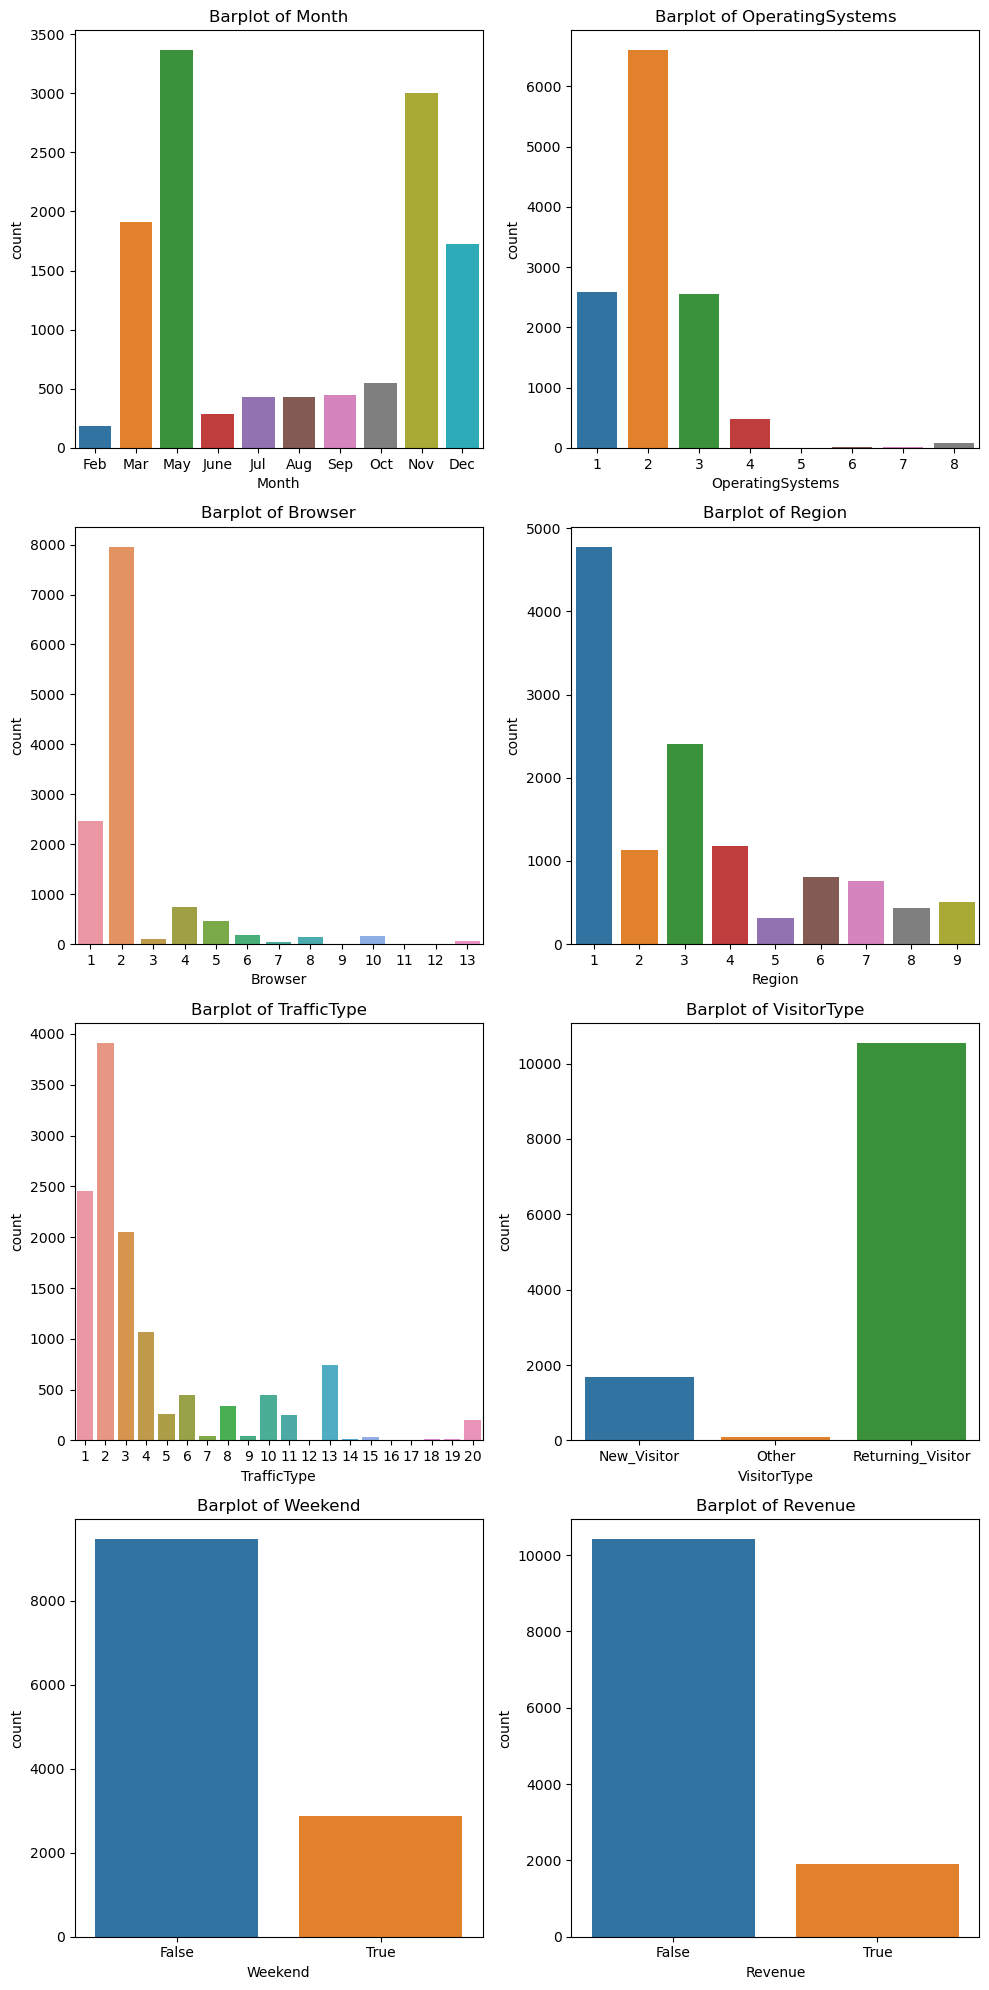

In [12]:
# Barolot for categorical variables (plot the frequencies)
# Histoplot for numerical continuous variables
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 20))
categoricals = ['Month','OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType','Weekend', 'Revenue']
for name in enumerate(categoricals):
    i, name = name
    sns.countplot(data=total_df, x=name, ax=axes[i // 2, i % 2])
    axes[i // 2, i % 2].set_title("Barplot of {}".format(name))

plt.tight_layout()
plt.show();


#### Histoplot the total of positive revenues for each categorical variables
For the continue variable on the X axis, plot the total number of the positive revenues on the Y axis.

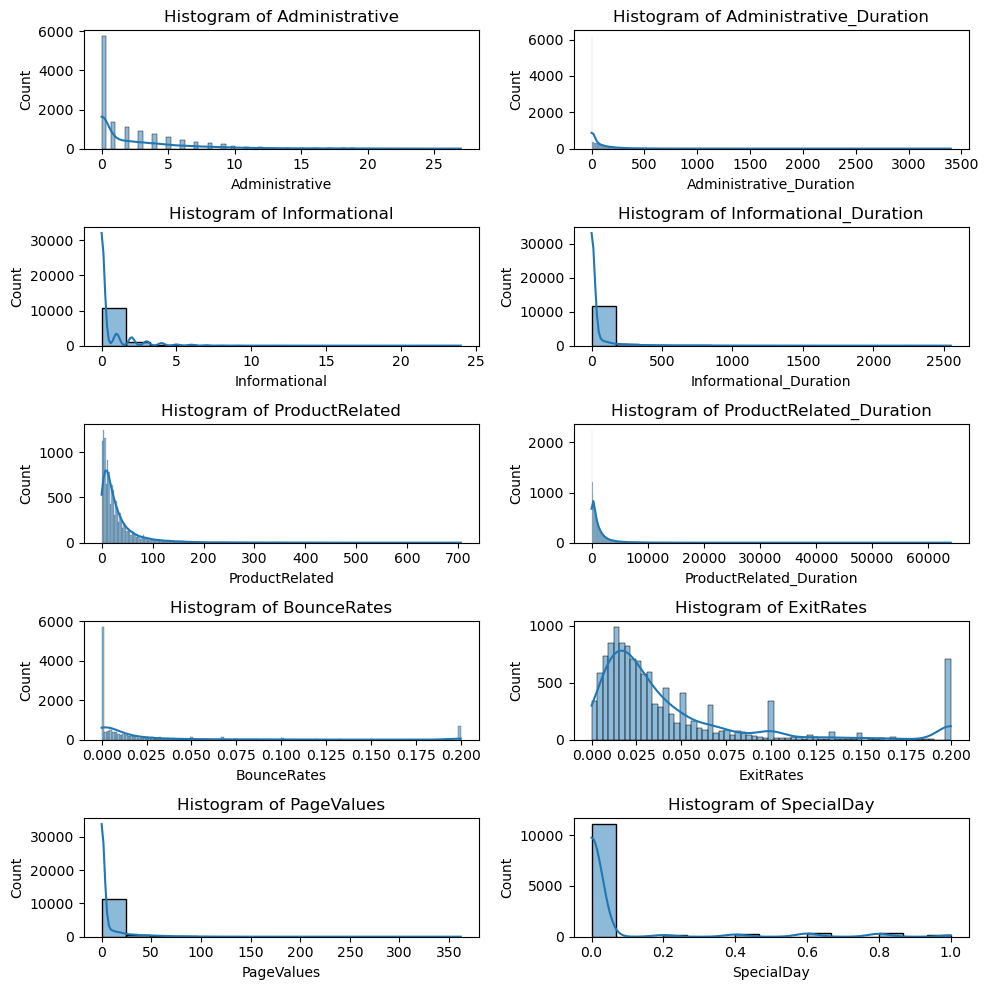

In [13]:
# Histoplot for numerical continuous variables
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10, 10))
continuos = ['Administrative', 'Administrative_Duration', 'Informational',
             'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
             'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
for name in enumerate(continuos):
    i, name = name
    sns.histplot(data=total_df, x=name, kde=True, ax=axes[i // 2, i % 2])
    axes[i // 2, i % 2].set_title("Histogram of {}".format(name))

plt.tight_layout()
plt.show();


#### Barplot the total number of positive and negative revenues for each values of the different categorical variables

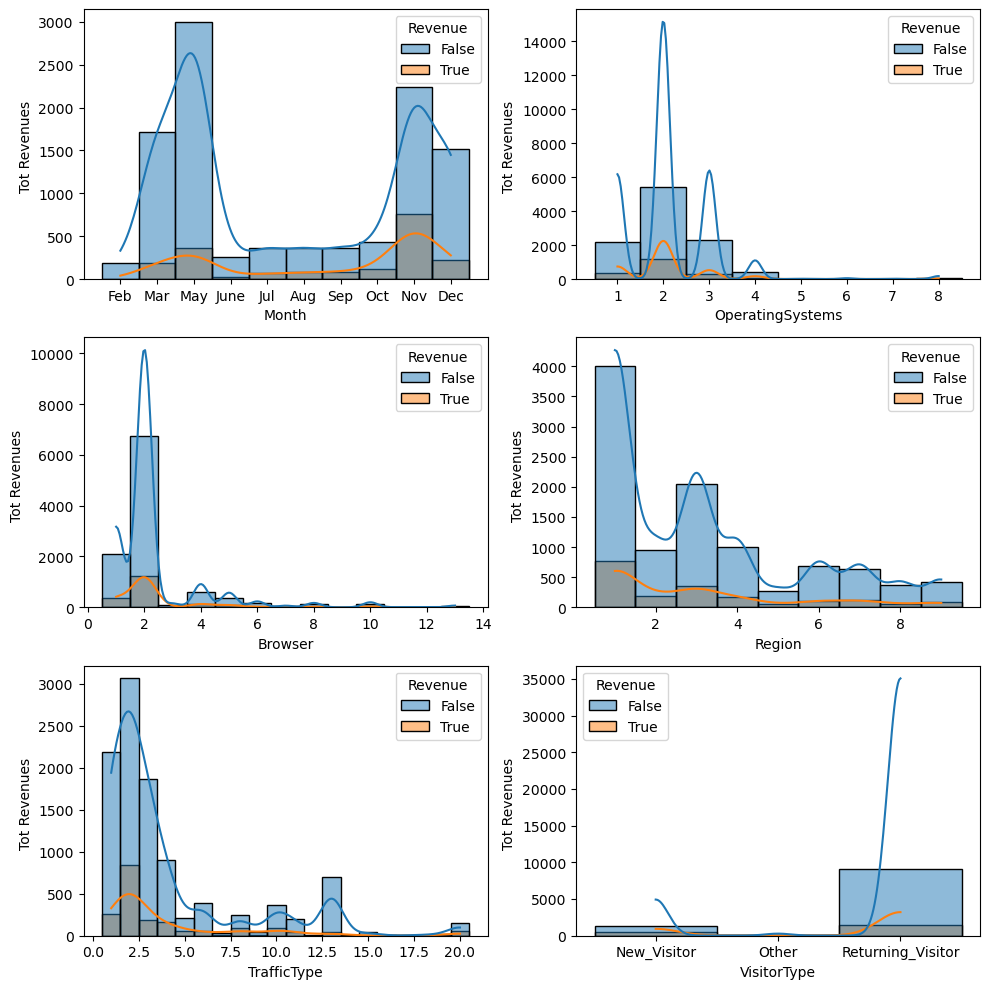

In [14]:
#some barplots for the total number of revenues (total number of true and false revenues) in the different categorical data: 
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10))
plt.subplots_adjust(hspace=0.4)

categoricals = ["Month", "OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType"]

for i, categorical in enumerate(categoricals):
    ax = axes[i // 2, i % 2]  # Assign the correct axes to 'ax'
    sns.histplot(data=total_df, x=categorical, hue="Revenue", kde=True, ax=ax)
    ax.set_xlabel(categorical)
    ax.set_ylabel("Tot Revenues ")

plt.tight_layout()
plt.show();

## Plots for the percent of positive revenues over the total of the revenues wrt the other variables
#### Barplot the percentage of the positive revenues for each values of the different categorical variables

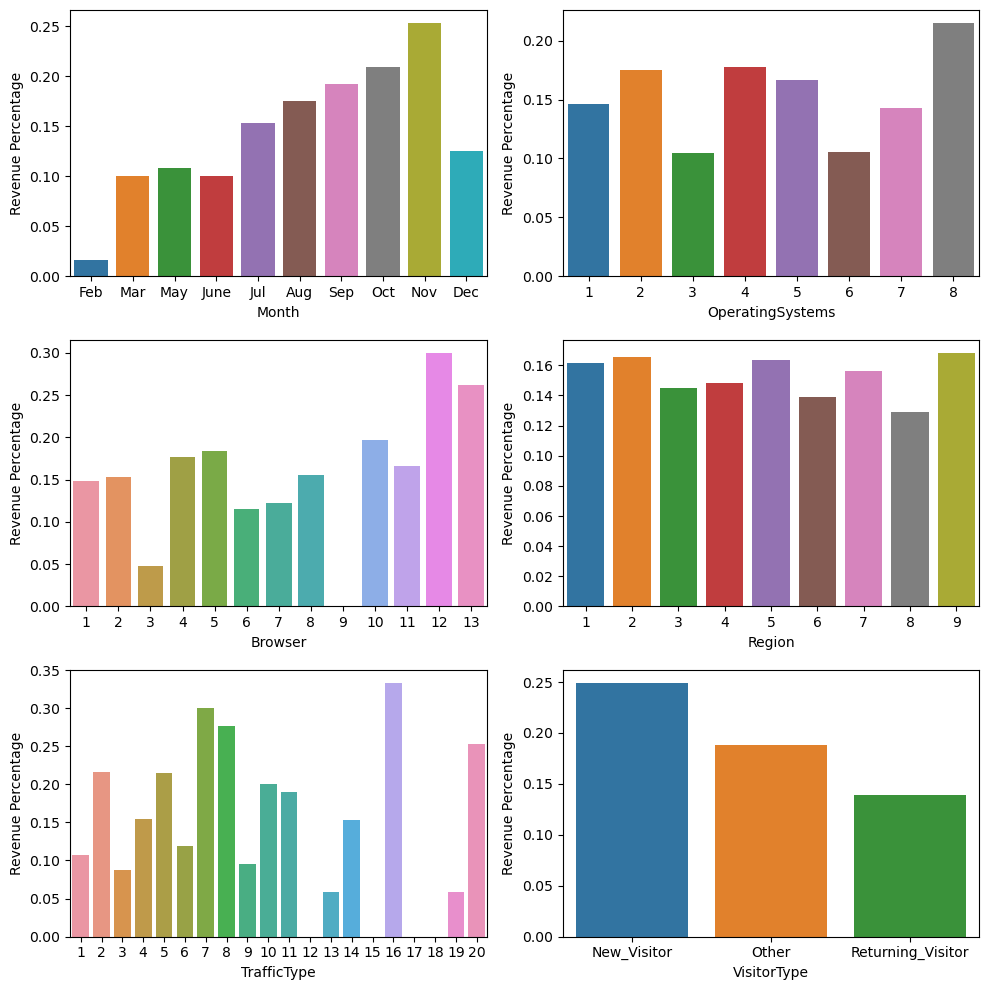

In [15]:
#a barplot for the percentages of revenues in the different categorical data: 
def revpercentage(rev):
    return np.sum(rev) / len(rev)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10))
plt.subplots_adjust(hspace=0.4)

categoricals = ["Month", "OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType"]

for i, categorical in enumerate(categoricals):
    rev_perc_bycat = total_df[[categorical, 'Revenue']].groupby(categorical).agg(revpercentage)
    rev_perc_bycat.reset_index(inplace=True)
    ax = axes[i // 2, i % 2]
    sns.barplot(data=rev_perc_bycat, x=categorical, y="Revenue", ax=ax)
    ax.set_xlabel(categorical)
    ax.set_ylabel("Revenue Percentage")

plt.tight_layout()
plt.show();

## Special day: an interesting variable
We consider 'special day' as a numerical variable as we assume that the "distance" between the values of special day is constant.
1. Seems to affect a lot the total number of positive revenues: <b>almost all the total positive revenues are concentrated on special days!<b>
1. the percentage of positive revenues over the total is anyway affected but not that much (on special days we have more or less the a double % of positive revenues)
    1. people tends to buy a lot more during special days considering the absolute total of the revenues 
    1. the "willingness" to buy is higher but not that much during special days: the percentage of positive revenues is more or less the double

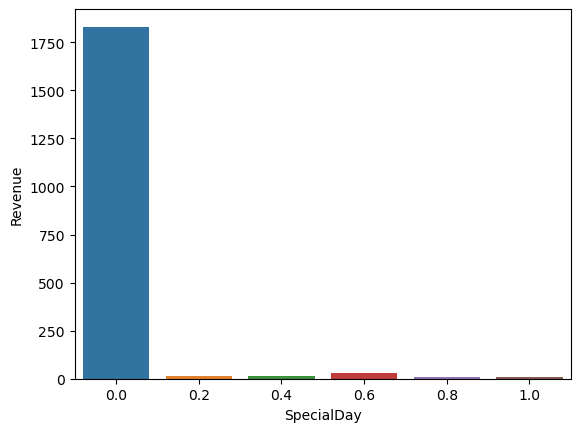

In [16]:
#we have the closeness of a special day (mother day, Valentine day). let's check it, the closer we are, 
#the more total revenues and the higher purchase percentage we have
#total revenues: 
revenues_byspecialday = total_df[['SpecialDay', 'Revenue']].groupby('SpecialDay').agg(np.sum)
revenues_byspecialday.reset_index(inplace=True)
sns.barplot(data = revenues_byspecialday, x= 'SpecialDay', y='Revenue');

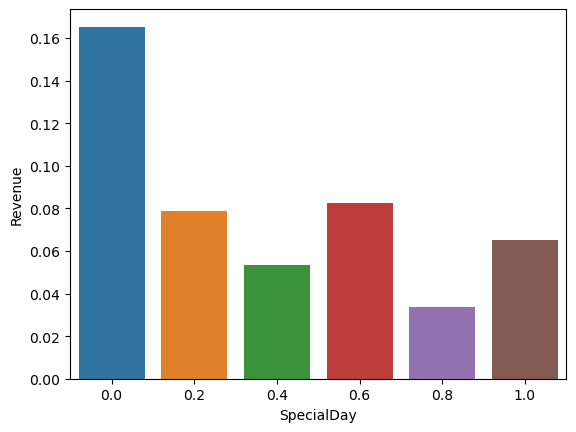

In [17]:
#the percentage of revenues by closeness to the special day it's not that different instead. On a special day, 
#we have two times the % of sessions that lead to a purchase
def revpercentage(rev):
    return np.sum(rev) / len(rev)
revenues_byspecialday_perc = total_df[['SpecialDay', 'Revenue']].groupby('SpecialDay').agg(revpercentage)
revenues_byspecialday_perc
revenues_byspecialday_perc.reset_index(inplace=True)
sns.barplot(data = revenues_byspecialday_perc, x= 'SpecialDay', y='Revenue');

## check the correlations between n. of pages and type. 
For each type of pages (product related, administrative, informational), check if there is a correlation between the number of visited pages by type and the time spent on those by type. Each dot represent a session and the color is given w.r.t. if the session was "positive", green (purchase) or "negative", red. We expect to see quite good correlations (the more pages you visited, the more time you spent). 
For each type of pages, check if there is a correlation between the time spent on a page and the rest of the pages. colors are given as above. We may expect to see a correlation ("indecisive costumers"). 
For each type of pages, check if there is a correlation between the number of pages of a type consulted and number of pages of other types. 

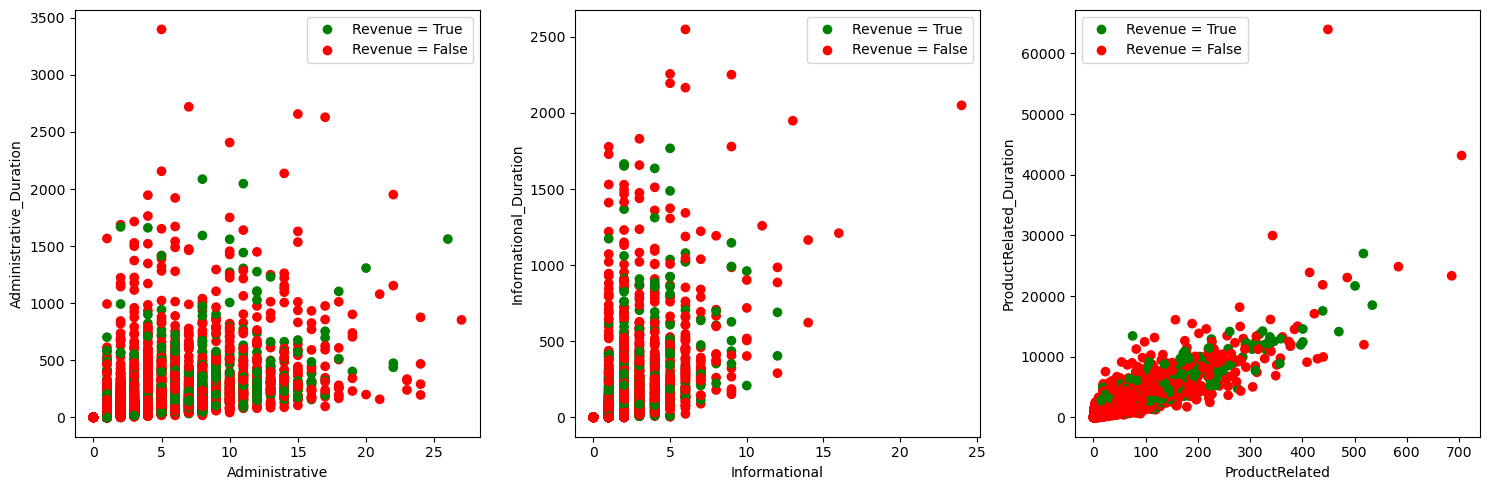

In [18]:
#we have three different types of pages (administrative, informational, product), the number of pages that where visited (by type) the time that each costumer spent on them
#scatterplor the type of the page vs the time and distinguish whenever the purchase was made or not. 
#maybe we will discover something useful
pages_and_time = [('Administrative', 'Administrative_Duration'), ('Informational', 'Informational_Duration'), ('ProductRelated', 'ProductRelated_Duration')]
colors = ['red' if revenue == False else 'green' for revenue in total_df['Revenue']]
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
for i, tup in enumerate(pages_and_time):
    X, Y = tup
    ax = axes[i]  # Assign the correct subplot to 'ax'
    ax.scatter(data=total_df, x=X, y=Y, c=colors)

    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Revenue = True'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Revenue = False')
    ]

    ax.legend(handles=legend_elements)
    ax.set_xlabel(X)
    ax.set_ylabel(Y)

plt.tight_layout()
plt.show();


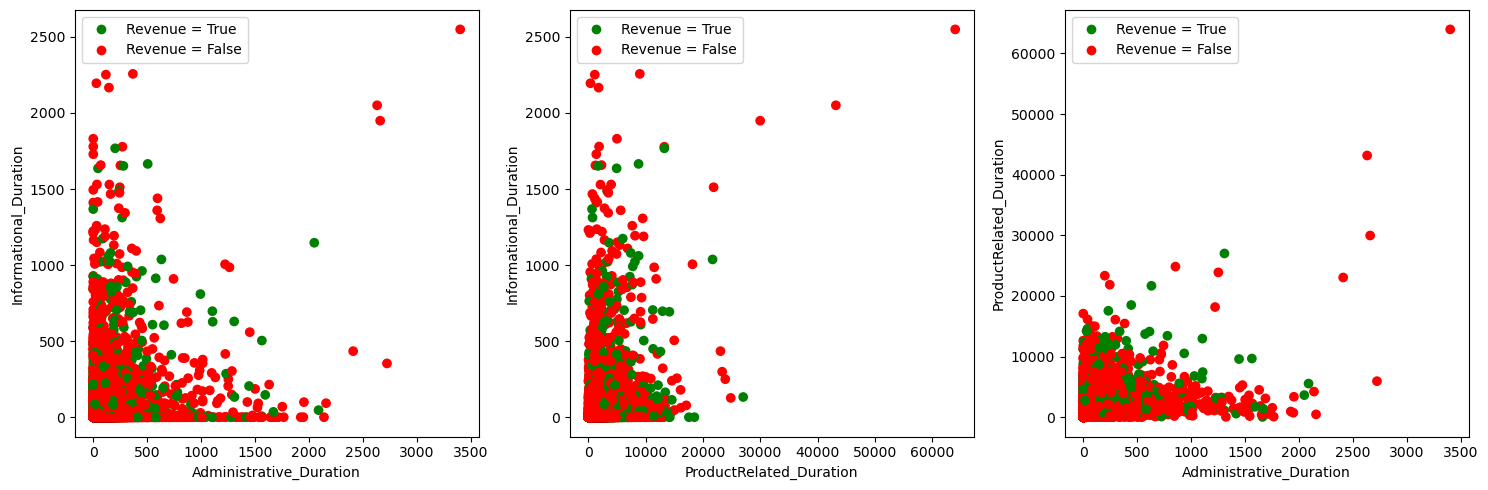

In [19]:
times_times = [('Administrative_Duration', 'Informational_Duration'), ('ProductRelated_Duration', 'Informational_Duration'), ('Administrative_Duration', 'ProductRelated_Duration')]
colors = ['red' if revenue == False else 'green' for revenue in total_df['Revenue']]
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
for i, tup in enumerate(times_times):
    X, Y = tup
    ax = axes[i]  # Assign the correct subplot to 'ax'
    ax.scatter(data=total_df, x=X, y=Y, c=colors)

    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Revenue = True'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Revenue = False')
    ]

    ax.legend(handles=legend_elements)
    ax.set_xlabel(X)
    ax.set_ylabel(Y)

plt.tight_layout()
plt.show();

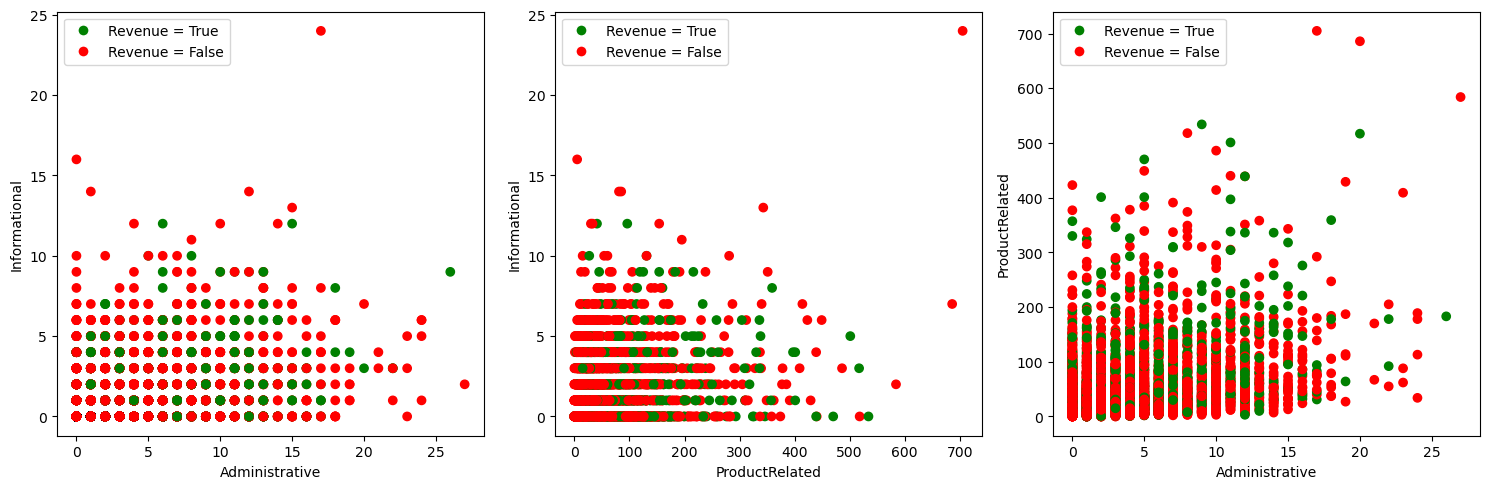

In [20]:
pages_and_pages = [('Administrative', 'Informational'), ('ProductRelated', 'Informational'), ('Administrative', 'ProductRelated')]
colors = ['red' if revenue == False else 'green' for revenue in total_df['Revenue']]
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
for i, tup in enumerate(pages_and_pages):
    X, Y = tup
    ax = axes[i]  # Assign the correct subplot to 'ax'
    ax.scatter(data=total_df, x=X, y=Y, c=colors)

    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Revenue = True'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Revenue = False')
    ]

    ax.legend(handles=legend_elements)
    ax.set_xlabel(X)
    ax.set_ylabel(Y)

plt.tight_layout()
plt.show();

## Check if there is a correlation between the bounce rate and the exit rate
We may expect a correlation, the more costumers leave the website in general, the more costumers leave the page from that specific page. Colors are given depensing on the Revenue of that session. 

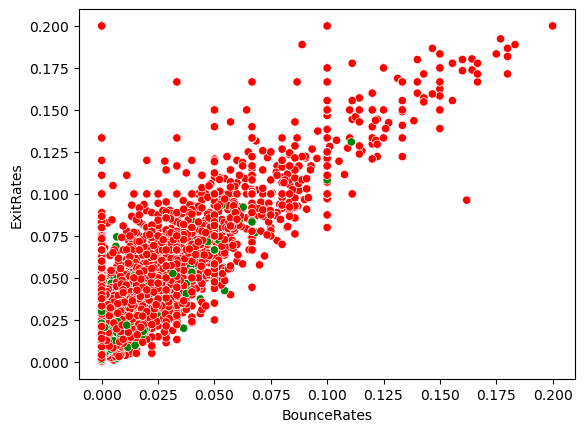

In [21]:
#check the scatterplot between bounce rate exit rate: 
colors = ['red' if revenue == False else 'green' for revenue in total_df['Revenue']]
sns.scatterplot(data = total_df, x = "BounceRates", y = "ExitRates", c = colors); 

## Continuos variables and boxplots
For each continuos variable, make a boxplot divided in positive positive and negative revenues. 

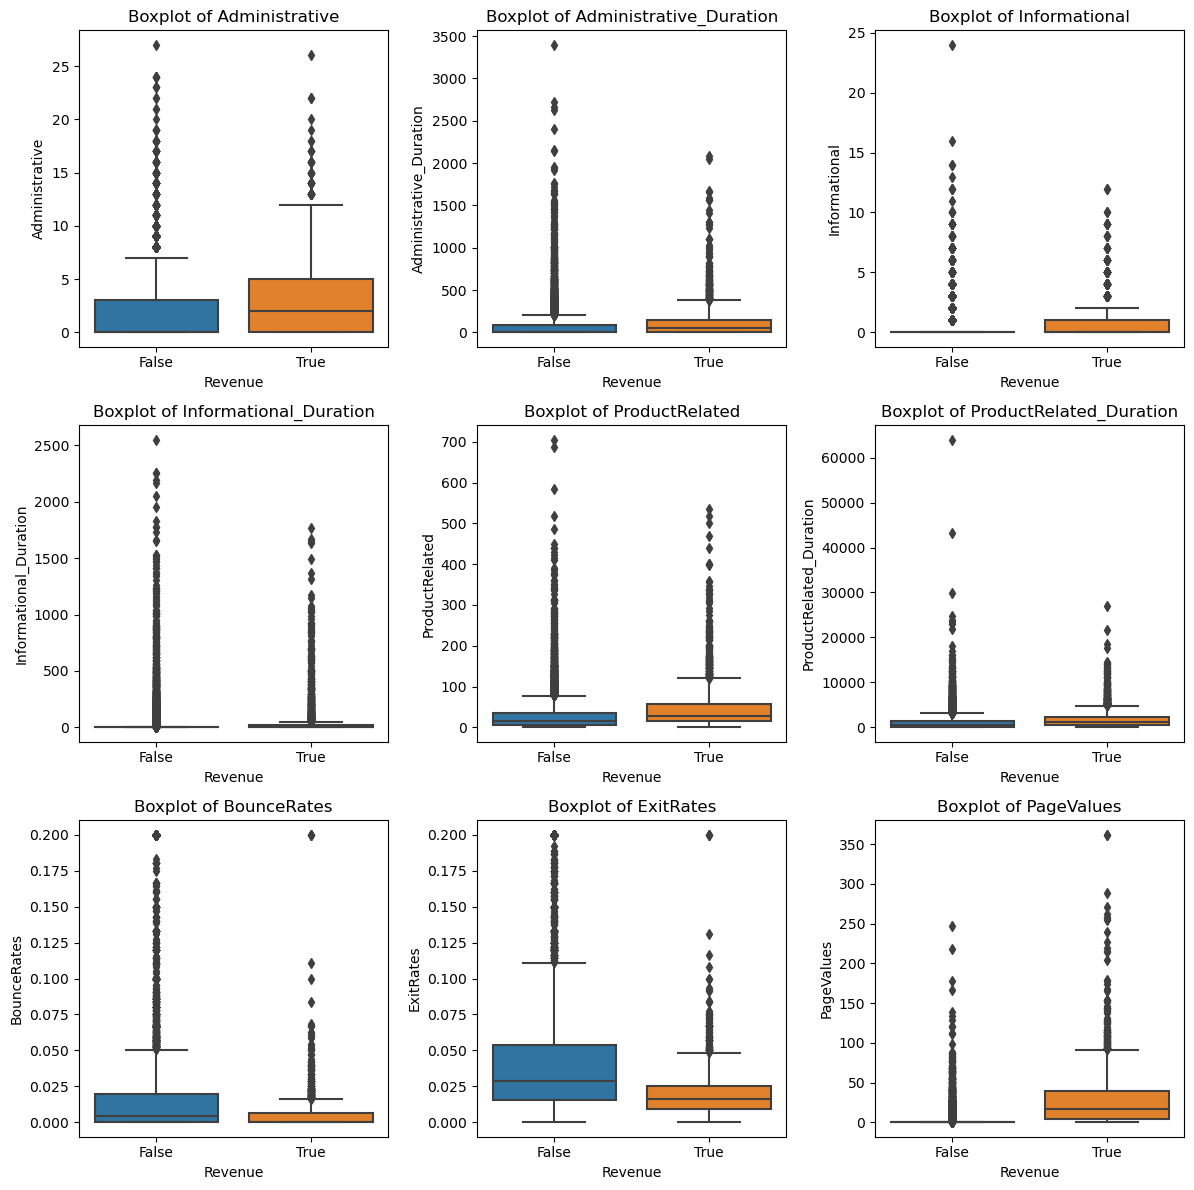

In [22]:
#boxplot a continuos variable and consider if it has outliers and everything: 
continuos = ['Administrative', 'Administrative_Duration', 'Informational',
             'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
             'BounceRates', 'ExitRates', 'PageValues']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 12))
plt.subplots_adjust(hspace=0.4)

for i, name in enumerate(continuos):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    sns.boxplot(data=total_df, x="Revenue", y=name, ax=ax)
    ax.set_title("Boxplot of {}".format(name))

plt.tight_layout()
plt.show();
    

## Correlation inspection 
### Spearman correlation between numerical variables
#### check if there is a correlation between the numerical variables. 
To avoid to assume\to check the normality, use the Spearman correlation. For each pair numerical variable, compute the Spearman correlation coefficient.
Check the pairs of variable who have a significantly different from zero correlation coefficient (evidence for the correlation to be present).
Sort the RHOs from the smaller (more negative correlation) to the higher (more positive correlation). Plot them: 
Purple: significan negative correlation 
Gray: correlation coefficient is significant but very close to zero
Red: significant positive correlation

#### Heat mapping

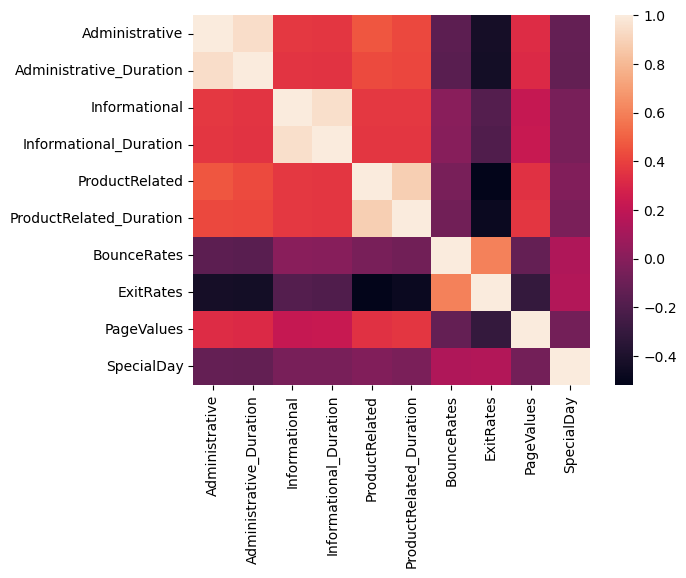

In [23]:
#correlation matrix between the differen numeric columns 
mydf_numeric = total_df.select_dtypes(include=np.number)
corrmatrix = mydf_numeric.corr(method = "spearman")
sns.heatmap(data=corrmatrix);

#### Analysis of the Rho Correlation coeffients

In [24]:
results = []
for name in continuos: 
    for name2 in continuos: 
        if name == name2: 
            pass
        else: 
            coef, pvalue = stats.spearmanr(total_df[name], total_df[name2])
            results.append(pd.Series([name, name2, coef, pvalue], index = ["first_numeric", "second_numeric", "coef", "pvalue"]))
corr_results = pd.DataFrame(results)

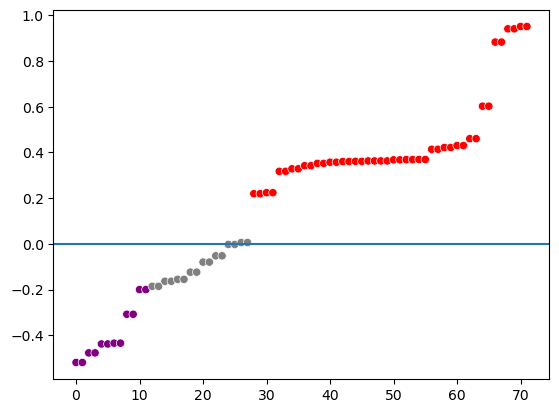

In [25]:
coefs = sorted(corr_results["coef"])
col = []
for coef in coefs: 
    if coef < -0.2: 
        col.append("purple")
    elif coef > 0.2: 
        col.append("red")
    else: 
        col.append("grey")
sns.scatterplot(x = range(72), y = coefs, c = col)
plt.axhline(y=0);

#### explore the correlations more deeply
which correlations are significant? 
1. correlations that are significantly different from zero (pvalue of the test < 0.05)
1. correlations that are significantly positive or negative (absolute value of the RHO > 0.5)

In [26]:
mask = (corr_results["pvalue"] < 0.05) & (abs(corr_results["coef"]) > 0.5)
corr_results[mask]

,first_numeric,second_numeric,coef,pvalue
0,Administrative,Administrative_Duration,0.940725,0.0
8,Administrative_Duration,Administrative,0.940725,0.0
18,Informational,Informational_Duration,0.950958,0.0
26,Informational_Duration,Informational,0.950958,0.0
36,ProductRelated,ProductRelated_Duration,0.882672,0.0
38,ProductRelated,ExitRates,-0.518920,0.0
44,ProductRelated_Duration,ProductRelated,0.882672,0.0
54,BounceRates,ExitRates,0.602276,0.0
60,ExitRates,ProductRelated,-0.518920,0.0
62,ExitRates,BounceRates,0.602276,0.0


### Cramer correlation between categorical variables
Reload the dataset to perfomr some independent modifications
Cramer correlation is useful for the correlation between categorical variables

In [27]:
new_categorical_columns=['Weekend', 'Revenue']

for name in new_categorical_columns: 
    total_df[name] = pd.Categorical(total_df[name])

In [28]:
total_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Administrative           12330 non-null  int64   
 1   Administrative_Duration  12330 non-null  float64 
 2   Informational            12330 non-null  int64   
 3   Informational_Duration   12330 non-null  float64 
 4   ProductRelated           12330 non-null  int64   
 5   ProductRelated_Duration  12330 non-null  float64 
 6   BounceRates              12330 non-null  float64 
 7   ExitRates                12330 non-null  float64 
 8   PageValues               12330 non-null  float64 
 9   SpecialDay               12330 non-null  float64 
 10  Month                    12330 non-null  category
 11  OperatingSystems         12330 non-null  category
 12  Browser                  12330 non-null  category
 13  Region                   12330 non-null  category
 14  Traffi

#### explore the correlations more deeply
which correlations are significant? 
1. correlations that are significantly different from zero (pvalue of the test < 0.05)
1. correlations that are significantly positive or negative (absolute value of the Cramer > 0.5)

In [29]:
from scipy.stats import chi2_contingency
# Function to compute Cramér's V statistic
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

# Iterate over pairs of categorical 
results=[]
for i in range(len(categorical_columns)):
    for j in range(i+1, len(categorical_columns)):
        col1 = categorical_columns[i]
        col2 = categorical_columns[j]
        
        # Create a cross-tabulation between the two variables
        cross_tab = pd.crosstab(total_df[col1], total_df[col2])
        
        # Compute Cramér's V statistic
        v = cramers_v(cross_tab.values)
        
        # Perform the chi-square test
        chi2, p, _, _ = chi2_contingency(cross_tab.values)
        results.append((col1,col2,v,p))

results = pd.DataFrame(results, columns=['variable1',"variable2","CramerV","p-value"])
mask = (results["p-value"]<0.05) & (results["CramerV"]>0.1)
sign_results = results[mask]
print("The significant correlations between categorical variables are:")
sign_results

The significant correlations between categorical variables are:


,variable1,variable2,CramerV,p-value
0,OperatingSystems,Browser,0.595518,0.000000e+00
1,OperatingSystems,Region,0.115537,7.299372e-216
2,OperatingSystems,TrafficType,0.192663,0.000000e+00
3,OperatingSystems,VisitorType,0.465368,0.000000e+00
4,Browser,Region,0.126050,7.698462e-284
5,Browser,TrafficType,0.189210,0.000000e+00
6,Browser,VisitorType,0.509930,0.000000e+00
8,Region,VisitorType,0.180382,8.066997e-164
9,TrafficType,VisitorType,0.383107,0.000000e+00


## Correlation of the numerical variables ExitRates
Is there a correlation between the numerical variables and <b> the target of the Regression: ExitRates? <b>


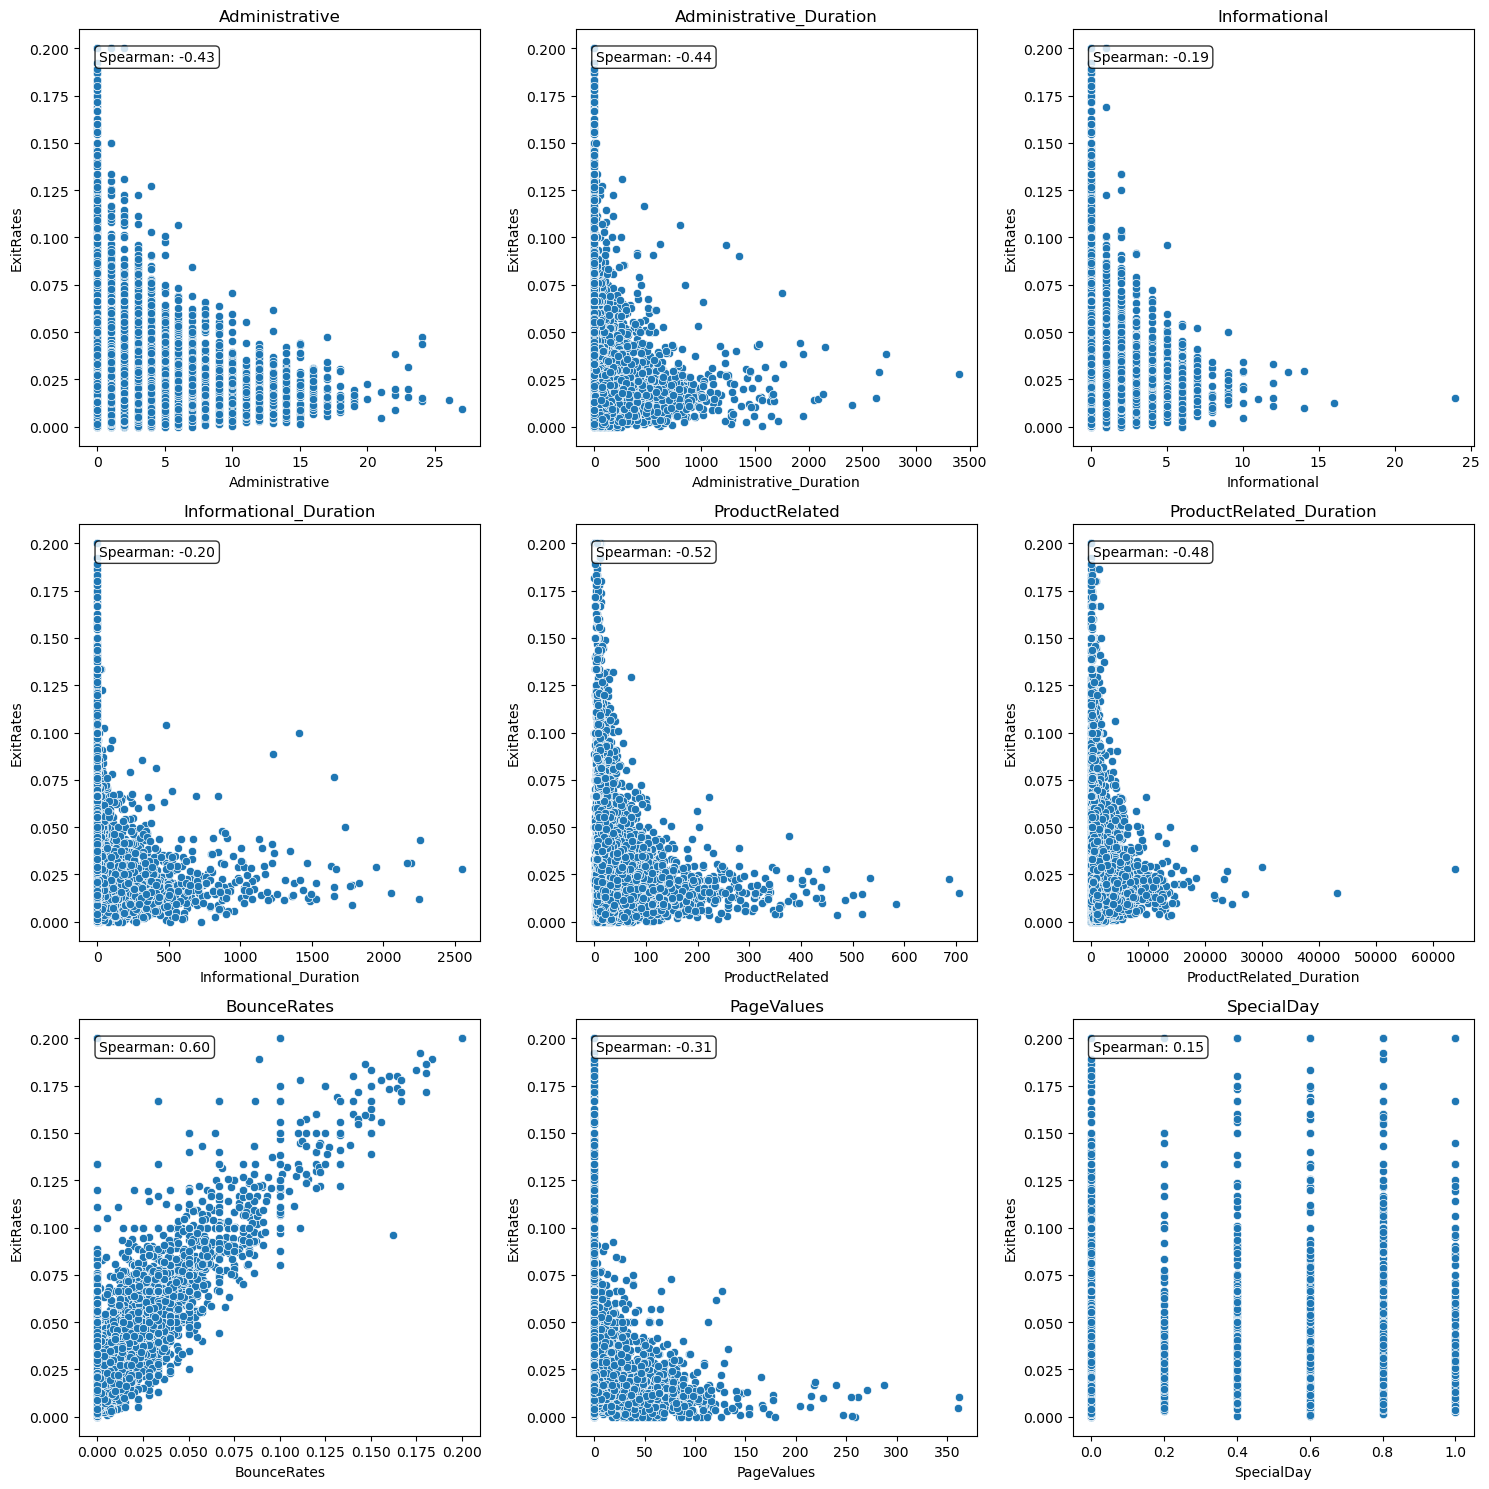

In [30]:
from scipy.stats import spearmanr
continous = ["Administrative","Administrative_Duration",'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates','PageValues',"SpecialDay"]

num_plots = len(continous)
num_cols = 3
num_rows = (num_plots - 1) // num_cols + 1

fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 15))

for i, var in enumerate(continous):
    row = i // num_cols
    col = i % num_cols
    ax = axs[row, col]
    sns.scatterplot(data=total_df, x=var, y="ExitRates", ax=ax)
    ax.set_title(var)
    correlation, _ = spearmanr(total_df[var], total_df["ExitRates"])
    correlation_text = f"Spearman: {correlation:.2f}"
    ax.text(0.05, 0.95, correlation_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show();

<div align="center">

# Politecnico of Milan  
## MSc. in Bioinformatics and Computational Genomics  
### Machine Learning  
#### A.Y. 2022-23  

### Regression for the Variable Exit Rates 

**Students:** Francesco Pelizzari, Simone Corbetta  
**ID:** 10942582, 10951358  
**Emails:** francesco.pelizzari1@studenti.unimi.it simone.corbetta1@studenti.unimi.it  

</div>

## REGRESSION: index
1. Loading the data and preprocessing
    1. load the training data and get the rows without a value for exit rates
    1. load the testing data and get the rows without a value for exit rates
    1. get the NA dataframe: the dataframe where we don't have a value for the exit rates
1. One hot encoding 
    1. One hot encoding check: what levels of the categorical variables are extremely rare?
    1. Variance selection of the features
1. Linear model and feature selection 
    1. Fitting a complete Linear model using SKlearn
    1. Fitting a complete Linear model using Stats Model 
    1. Lasso Shrinkage method for the feature selection
    1. Step Forward feature selection
    1. performance of the model in CV
    1. Diagnostic plots: residuals, QQplot, Std Residuals and outliers
1. KNN for regression with numerical variables only
    1. Diagnostic plots: residuals, QQplot, Std Residuals and outliers
1. Predicion using the LASSO model 
1. Inference of the LASSO model

In [31]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


%matplotlib inline
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from numpy import mean
from numpy import absolute
from numpy import sqrt
np.random.seed(0)

## Load the train dataset
Use some general descriptive fucntions. Perform some preprocessing (ex. set categorical variables to categorical). 
Check the part of the dataset that has NA as ExitRates and save them (they will be used for the validation).
Remove that rows from the dataset that we will use for the modelling. 

In [32]:
# Read the data and creates a pandas DataFrame
# drop the un-named column
data = train_df.copy()
data.drop(["Unnamed: 0"], inplace = True, axis = 1)

In [33]:
#explore the NA present in the dataset. 
#how many NAs are present in the exit rate column? are there any other NAs in the other columns?
for col in data.columns:
    if  data[col].isna().sum() > 0:
        print(col,data[col].isna().sum())
#build a train_df_target for which we dont have nas in the target variable
target= "ExitRates"
mask = ~data[target].isna()
data_target = data[mask].reset_index(drop=True)
mask = data[target].isna()
na_rows_train = data[mask].reset_index(drop=True)

ExitRates 2782


## Load the test dataset
Drop the 'unnamed' column. 
Check the part of the dataset that has NA as ExitRates and save them (they will be used for the validation).

In [34]:
data_test = test_df.copy()
data_test.drop(["Unnamed: 0"], inplace = True, axis = 1)
na_rows_test = data_test[pd.isna(data_test['ExitRates'])]

## The NA_df
The concatenation of the NAs ExitRates rows in the two dataframes. Will we use our model for the prediction of those variables

In [35]:
na_df = pd.concat([na_rows_train, na_rows_test], ignore_index=True)
na_df.shape
print("the total number of NA that we will try to predict is {}".format(na_df.shape[0]))

(3699, 18)

the total number of NA that we will try to predict is 3699


#### Perform one-hot encoding for the categorical variables. 
For both the model that we will use ofr the training and the NA_fa that we will use for the prediction.
Encode the boolean variables as numeric. 
Perform variance selection on the columns: remove the variables (especially the one-hot encoded) that has a very low variance. 
Ex. if only a few costumers has a certain Operating System (less than 1%), remove that column. Produce a new dataframe (var selected) in which we have remove columns with a very low variance. 

In [36]:
columns_to_convert = ["Month","Browser","Region","TrafficType","VisitorType","OperatingSystems"]
data_target = pd.get_dummies(data_target, columns=columns_to_convert)
na_df = pd.get_dummies(na_df, columns=columns_to_convert)
data_target["Revenue"] = data_target["Revenue"].astype(int)
data_target["Weekend"] = data_target["Weekend"].astype(int)
na_df["Revenue"] = na_df["Revenue"].astype(int)
na_df["Weekend"] = na_df["Weekend"].astype(int)

In [37]:
#divide the df in X (predictors) and Y (target): 
target = "ExitRates"
y = data_target[[target]]
X = data_target.drop(target, axis = 1)
na_df = na_df.drop(target,axis=1)

### OneHot encoding check:
Which one-hot encoded variables has a very small variance?
Check the frequencies of the different categories for each of the categorical data. Some levels for the categorical variables are extremely rare but yet they add a complete\full column. 
Do we really want to keep them? 

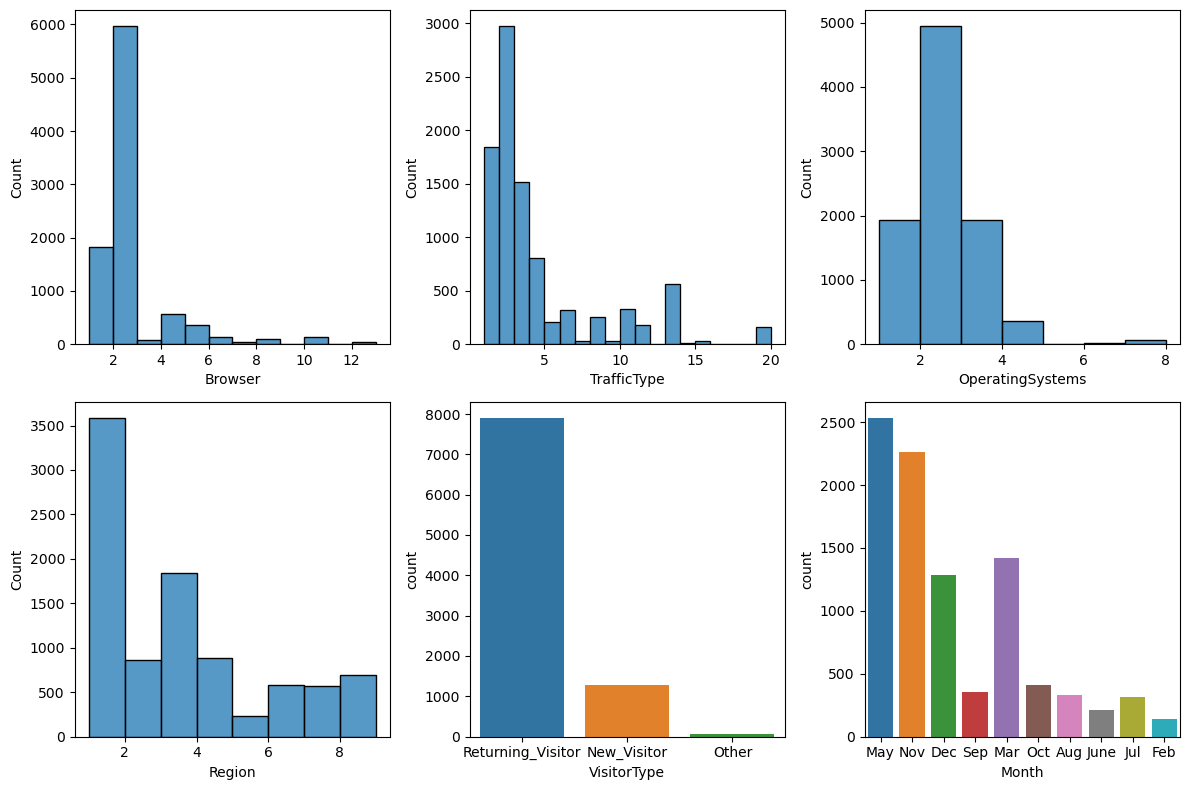

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Plot the histograms and the counter plots
sns.histplot(data=data, x="Browser", binwidth=1, ax=axes[0, 0])
sns.histplot(data=data, x="TrafficType", binwidth=1, ax=axes[0, 1])
sns.histplot(data=data, x="OperatingSystems", binwidth=1, ax=axes[0, 2])
sns.histplot(data=data, x="Region", binwidth=1, ax=axes[1, 0])

sns.countplot(data=data, x="VisitorType", ax=axes[1, 1])
sns.countplot(data=data, x="Month", ax=axes[1, 2])

plt.tight_layout()

plt.show();

In [39]:
# for each categorical data, get the values of the frequencies 
pd.Categorical(data.Browser).describe().sort_values("freqs",ascending=False)
pd.Categorical(data.TrafficType).describe().sort_values("freqs",ascending=False)
pd.Categorical(data.OperatingSystems).describe().sort_values("freqs",ascending=False)
pd.Categorical(data.VisitorType).describe().sort_values("freqs",ascending=False);

##### Many one-hot encoded variable has a vey limited frequency\variance
it's worth selecting them! 
<b> The first feature selection that we perform is eliminating low variance features! <b>
    
Remove those features that, along the columns, have the same value along the 99.9% of the column. 
Basically, <b> remove those one-hot encoded features that have zeros along all the column <b> 
This should improve the model!

In [40]:
from sklearn.feature_selection import VarianceThreshold
sel = VarianceThreshold(threshold=(.999 * (1 - .999)))
X_sel = sel.fit_transform(X)
mask = list(sel.get_support())
X_varselected = X[X.columns[mask]]
to_select = X_varselected.columns
na_df = na_df[to_select]

#### Fit a model using Scikit Learn. 
Use the Dataframe with the variables selected based on their variance.
Get the coefficients for this complete model. Evalute the R2 and the MSE.

In [41]:
model = LinearRegression(fit_intercept=True)       
model.fit(X_varselected, y)                              
y_predict_complete = model.predict(X_varselected)                       

LinearRegression()

In [42]:
X_features = X_varselected.columns
print("The coefficients for the complete model")
print("The intercept is {:0.3f}".format(float(model.intercept_)))
for idx, col_name in enumerate(X_features):
    print("The coefficient for {} is {:0.5f}".format(col_name, float(model.coef_.T[idx])))

The coefficients for the complete model
The intercept is 0.025
The coefficient for Administrative is -0.00090
The coefficient for Administrative_Duration is -0.00000
The coefficient for Informational is 0.00004
The coefficient for Informational_Duration is 0.00000
The coefficient for ProductRelated is -0.00012
The coefficient for ProductRelated_Duration is 0.00000
The coefficient for BounceRates is 0.85636
The coefficient for PageValues is -0.00010
The coefficient for SpecialDay is 0.00638
The coefficient for Weekend is -0.00068
The coefficient for Revenue is -0.00371
The coefficient for Month_Aug is -0.00068
The coefficient for Month_Dec is 0.00053
The coefficient for Month_Feb is -0.00034
The coefficient for Month_Jul is 0.00090
The coefficient for Month_June is 0.00524
The coefficient for Month_Mar is -0.00103
The coefficient for Month_May is -0.00102
The coefficient for Month_Nov is 0.00002
The coefficient for Month_Oct is -0.00170
The coefficient for Month_Sep is -0.00193
The coef

In [43]:
from sklearn.metrics import r2_score, mean_squared_error
print("training R2 score ", r2_score(y, y_predict_complete))
print("training MSE score ", mean_squared_error(y, y_predict_complete))

training R2 score  0.863925456259636
training MSE score  0.00031560992380163914


#### use the library stats model to produce a model and exploit the statsmodel function that are more inference-friendly
perform a t-test and some other descrptive tests on the complete model (built with stats models).
print the results for the complete model.

In [44]:
y = y.to_numpy().reshape(y.shape[0])
#transform x var selected in a numpy array
Xsm_varselected = X_varselected.to_numpy()
#add a 1 at the beginning as an intercept
Xsm_varselected = sm.add_constant(Xsm_varselected)
Xsm_varselected = Xsm_varselected.astype(int)
#fit the sm complete model
sm_model = sm.OLS(y, Xsm_varselected).fit()
summary = sm_model.summary()
summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.246
Method:                 Least Squares   F-statistic:                     36.12
Date:                Fri, 21 Jul 2023   Prob (F-statistic):               0.00
Time:                        16:14:38   Log-Likelihood:                 11380.
No. Observations:                6466   AIC:                        -2.264e+04
Df Residuals:                    6405   BIC:                        -2.223e+04
Df Model:                          60                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0398      0.015      2.622      0.009       0.010       0.070
x1            -0.0024      0.000    -10.573      0.000      -0.003      -0.002
x2         -4.991e-06      4e-06     -1.247      0.212   -1.28e-05    2.85e-06
x3            -0.0002      0.001     -0.384      0.701      -0.001       0.001
x4          6.469e-06   4.91e-06      1.318      0.188   -3.16e-06    1.61e-05
x5            -0.0002   2.54e-05     -7.731      0.000      -0.000      -0.000
x6         -9.087e-07   6.23e-07     -1.458      0.145   -2.13e-06    3.13e-07
x7          5.076e-17   9.39e-17      0.540      0.589   -1.33e-16    2.35e-16
x8            -0.0002   3.24e-05     -5.316      0.000      -0.000      -0.000
x9             0.0041      0.005      0.816      0.415      -0.006       0.014
x10           -0.0047      0.001     -3.587      0.000      -0.007      -0.002
x11           -0.0101      0.002     -6.022      0.000      -0.013      -0.007
x12            0.0011      0.003      0.356      0.722      -0.005       0.007
x13            0.0002      0.002      0.108      0.914      -0.004       0.004
x14            0.0266      0.004      6.126      0.000       0.018       0.035
x15            0.0034      0.003      1.138      0.255      -0.002       0.009
x16            0.0162      0.004      4.581      0.000       0.009       0.023
x17           -0.0039      0.002     -1.830      0.067      -0.008       0.000
x18            0.0034      0.002      1.732      0.083      -0.000       0.007
x19            0.0031      0.002      1.535      0.125      -0.001       0.007
x20           -0.0046      0.003     -1.606      0.108      -0.010       0.001
x21           -0.0057      0.003     -1.909      0.056      -0.011       0.000
x22            0.0287      0.019      1.476      0.140      -0.009       0.067
x23            0.0285      0.019      1.480      0.139      -0.009       0.066
x24            0.0336      0.020      1.664      0.096      -0.006       0.073
x25            0.0284      0.019      1.466      0.143      -0.010       0.066
x26            0.0304      0.019      1.564      0.118      -0.008       0.069
x27            0.0210      0.020      1.066      0.286      -0.018       0.060
x28            0.0326      0.021      1.534      0.125      -0.009       0.074
x29            0.0283      0.020      1.408      0.159      -0.011       0.068
x30            0.0223      0.020      1.127      0.260      -0.016       0.061
x31            0.0103      0.024      0.431      0.666      -0.037       0.057
x32            0.0050      0.002      2.532      0.011       0.001       0.009
x33            0.0060      0.002      2.541      0.011       0.001       0.011
x34            0.0051      0.002      2.425      0.015       0.001       0.009
x35            0.0054      0.002      2.278      0.023       0.001       0.010
x3

### Feature selection: LASSO
Use the lasso feature selection (on X_varselected: remove those features with a small variance: all zeros columns). 
Perform 5-fold CV to determine the best alpha to use. 
Once you have done it, run the Lasso. 
Check the features that are kept.
Predict the values through the LASSO to then compute the residuals.

In [45]:
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
# Scale the features
scaler = StandardScaler()
X_Lassovarselected = scaler.fit_transform(X_varselected)
# Create a Lasso model
lasso = LassoCV(cv=5, random_state=0, fit_intercept = True)
lasso = lasso.fit(X_Lassovarselected, y)
# Fit the Lasso model
lasso.fit(X_Lassovarselected, y)
#what is the score of the model with the lasso?
score = lasso.score(X_Lassovarselected, y)
lasso_predicted = lasso.predict(X_Lassovarselected)

LassoCV(cv=5, random_state=0)

In [46]:
feature_coef_list = list(zip(X_varselected.columns, lasso.coef_))
featLasso_series = pd.Series(dict(feature_coef_list))
featLasso_series = featLasso_series[featLasso_series != 0]
featLasso_list = list(featLasso_series.index)
print("the features selected by the forward feature selection are {}".format(featLasso_list))

the features selected by the forward feature selection are ['Administrative', 'Administrative_Duration', 'ProductRelated', 'BounceRates', 'PageValues', 'SpecialDay', 'Weekend', 'Revenue', 'Month_Dec', 'Month_June', 'Month_Oct', 'Month_Sep', 'Region_3', 'Region_7', 'TrafficType_1', 'TrafficType_2', 'TrafficType_3', 'TrafficType_4', 'TrafficType_13', 'TrafficType_19', 'VisitorType_New_Visitor', 'VisitorType_Other', 'OperatingSystems_2', 'OperatingSystems_3', 'OperatingSystems_6']


##### Forward Feature Selection 
Based on 5-fold CV. Use the module *ML extend* to perform the SFS. 

In [47]:
from mlxtend.feature_selection import SequentialFeatureSelector as sfs

In [48]:
lreg = LinearRegression()

def r2_scoring(estimator, X, y):
    y_pred = estimator.predict(X)
    score = r2_score(y, y_pred)
    return score

sfs2 = sfs(lreg,k_features=50,forward=True, verbose=0, scoring=r2_scoring,cv=5)
sfs2 = sfs2.fit(X_varselected, y)

In [49]:
subsets = np.array([dic['avg_score'] for dic in sfs2.subsets_.values()])
np.argmax(subsets)
index = np.argmax(subsets) 
best_selection=sfs2.subsets_[index+1]

22

### What is the best model after Forward Feature Selection?
Plot the different R^2. 
Find the number of variables that maximizes the CV R^2. 
Fit the model with the selected variables.
Print the input variables that were selected by the SFS.

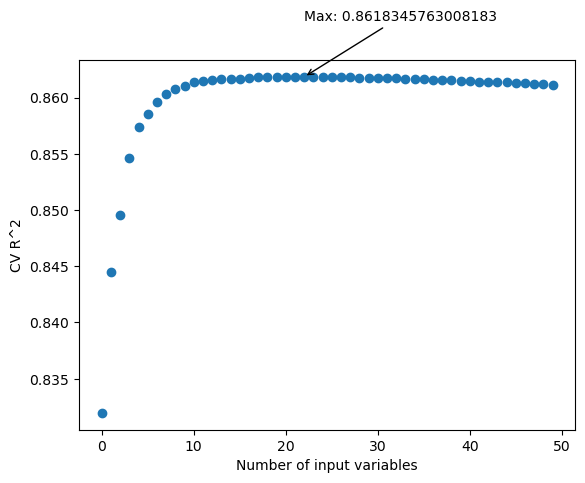

the features selected by the forward feature selection are ('Administrative', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'PageValues', 'SpecialDay', 'Revenue', 'Month_Dec', 'Month_June', 'Month_May', 'Browser_1', 'Browser_5', 'Region_7', 'TrafficType_1', 'TrafficType_2', 'TrafficType_3', 'TrafficType_4', 'TrafficType_7', 'TrafficType_13', 'TrafficType_19', 'VisitorType_New_Visitor', 'OperatingSystems_2', 'OperatingSystems_6')


In [50]:
max_value = np.max(subsets)
max_index = np.argmax(subsets)

# Scatter plot and find the maximum R^2 in CV
plt.scatter(range(len(subsets)), subsets)
plt.annotate(f"Max: {max_value}", xy=(max_index, max_value), xytext=(max_index, max_value + 0.005),
             arrowprops=dict(facecolor='black', arrowstyle='->'))
plt.xlabel("Number of input variables")
plt.ylabel("CV R^2")

plt.show()

print("the features selected by the forward feature selection are {}".format(best_selection['feature_names']));

In [51]:
lreg.fit(X_varselected[list(best_selection["feature_names"])], y)

LinearRegression()

In [52]:
SFS_selected = X_varselected[list(best_selection["feature_names"])]
SFS_predict = lreg.predict(SFS_selected)

## Performing cross validation with the complete (variance reduced), the Lasso and the SFS
<b> What is the model that performs the best? <b>

(meaning: what is the model with the highest R^2 score in CV?)

In [53]:
results=[]

for i in range(5):
    
    cv = KFold(n_splits=5, random_state=i, shuffle=True)


    #use k-fold CV to evaluate model
    scores = cross_val_score(model,X_varselected, y, scoring='r2',
                             cv=cv, n_jobs=-1)
    media = mean(absolute(scores))
    results.append(media)
   
to_print = sum(results)/len(results)
print('Complete linear model (variance selected)\nScore : {} '.format(to_print))
results = np.array(results)
media_complete = np.mean(results)
sd = np.std(results)
U_complete = media_complete + 1.96*sd
L_complete = media_complete - 1.96*sd
print(f'media = {media},U_bound = {U_complete},L_bound = {L_complete}')

Complete linear model (variance selected)
Score : 0.8608685823525855 
media = 0.8609482907768934,U_bound = 0.8614078001242723,L_bound = 0.8603293645808986


In [54]:
results=[]

for i in range(5):
    
    cv = KFold(n_splits=5, random_state=i, shuffle=True)


    #use k-fold CV to evaluate model
    scores = cross_val_score(lreg, X_varselected[list(best_selection["feature_names"])], y, scoring='r2',
                             cv=cv, n_jobs=-1)
    media = mean(absolute(scores))
    results.append(media)
   
to_print = sum(results)/len(results)
print('Step-Forward feature selection\nScore : {} '.format(to_print))
results = np.array(results)
media_SFS = np.mean(results)
sd = np.std(results)
U_SFS = media_SFS + 1.96*sd
L_SFS = media_SFS - 1.96*sd
print(f'media = {media},U_bound = {U_SFS},L_bound = {L_SFS}')

Step-Forward feature selection
Score : 0.8619122802623493 
media = 0.8616627058839385,U_bound = 0.8623560727621206,L_bound = 0.8614684877625781


In [55]:
results=[]

for i in range(5):
    
    cv = KFold(n_splits=5, random_state=i, shuffle=True)


    #use k-fold CV to evaluate model
    scores = cross_val_score(lasso, X_Lassovarselected, y, scoring='r2',
                             cv=cv, n_jobs=-1)
    media = mean(absolute(scores))
    results.append(media)
   
to_print = sum(results)/len(results)
print('LASSO model\nscore : {} '.format(to_print))
results = np.array(results)
media_LASSO = np.mean(results)
sd = np.std(results)
U_LASSO = media_LASSO + 1.96*sd
L_LASSO = media_LASSO - 1.96*sd
print(f'media = {media}, U_bound = {U_LASSO}, L_bound = {L_LASSO}')

LASSO model
score : 0.8614274320770031 
media = 0.8611960439905149, U_bound = 0.8618060893243021, L_bound = 0.8610487748297041


### What model is the best in CV? 


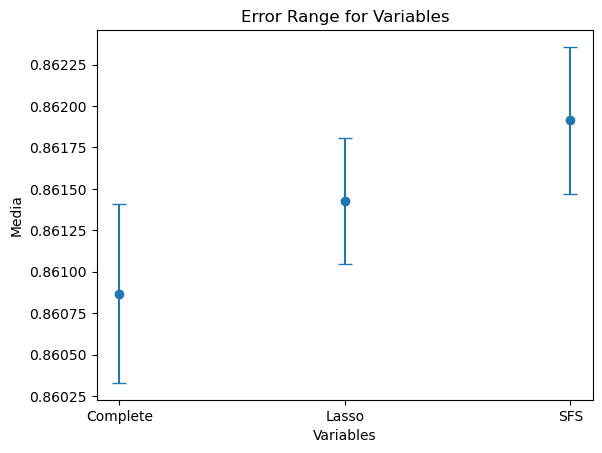

In [56]:
# Plot the points and error bars
x = np.array([1, 2, 3])
y_results  = np.array([media_complete, media_LASSO, media_SFS])

lower_bounds = np.array([L_complete, L_LASSO, L_SFS])
upper_bounds = np.array([U_complete,U_LASSO,U_SFS])

plt.errorbar(x, y_results, yerr=[y_results - lower_bounds, upper_bounds - y_results], fmt='o', capsize=5)

plt.xlabel("Variables")
plt.ylabel("Media")
plt.title("Error Range for Variables")

plt.xticks(x, ['Complete', 'Lasso', 'SFS'])

plt.show();

## Diagnonic plots for the models: 
1. plot of the residuals for the three models 
1. QQplot of the residuals: are they normal?
1. plot of the standardized residuals and the outliers

##### Residuals plots: 
For each model, plot the residuals against the fitted values

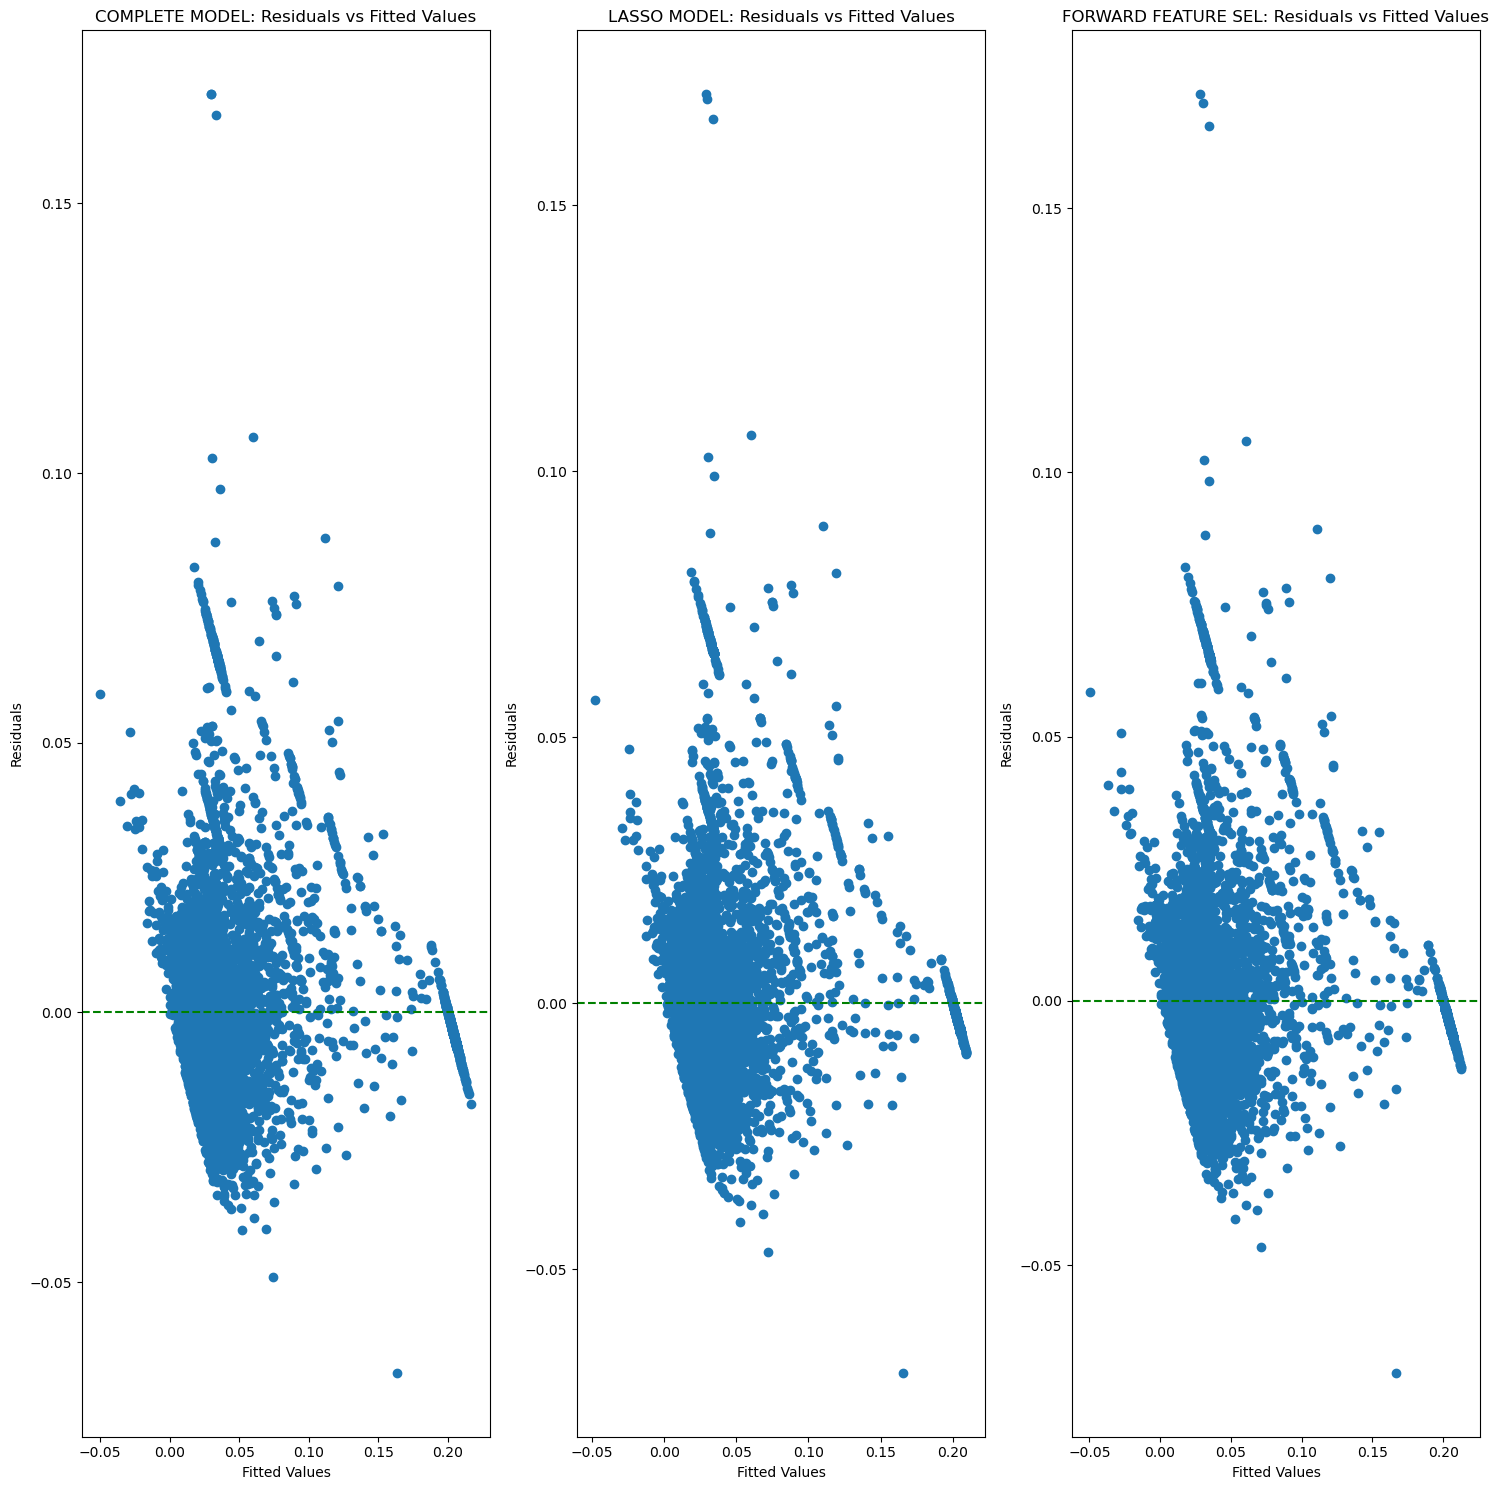

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(15,15))
#y = y.reshape(y.shape[0], 1)
# COMPLETE MODEL
residuals_complete = y.flatten() - y_predict_complete.flatten()
axes[0].scatter(y_predict_complete, residuals_complete)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('COMPLETE MODEL: Residuals vs Fitted Values')
axes[0].axhline(y=0, color="green", linestyle="--")

# LASSO MODEL
residuals_lasso = y.flatten() - lasso_predicted
axes[1].scatter(lasso_predicted, residuals_lasso)
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('LASSO MODEL: Residuals vs Fitted Values')
axes[1].axhline(y=0, color="green", linestyle="--")

# FORWARD FEATURE SEL
residuals_SFS = y.flatten() - SFS_predict
axes[2].scatter(SFS_predict, residuals_SFS)
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('Residuals')
axes[2].set_title('FORWARD FEATURE SEL: Residuals vs Fitted Values')
axes[2].axhline(y=0, color="green", linestyle="--")

plt.tight_layout()
plt.show();

###### standardization of the residulas

In [58]:
std_residuals_complete = (residuals_complete - np.mean(residuals_complete))/np.std(residuals_complete)
std_residuals_lasso = (residuals_lasso - np.mean(residuals_lasso))/np.std(residuals_lasso)
std_residuals_SFS = (residuals_SFS - np.mean(residuals_SFS))/np.std(residuals_SFS)

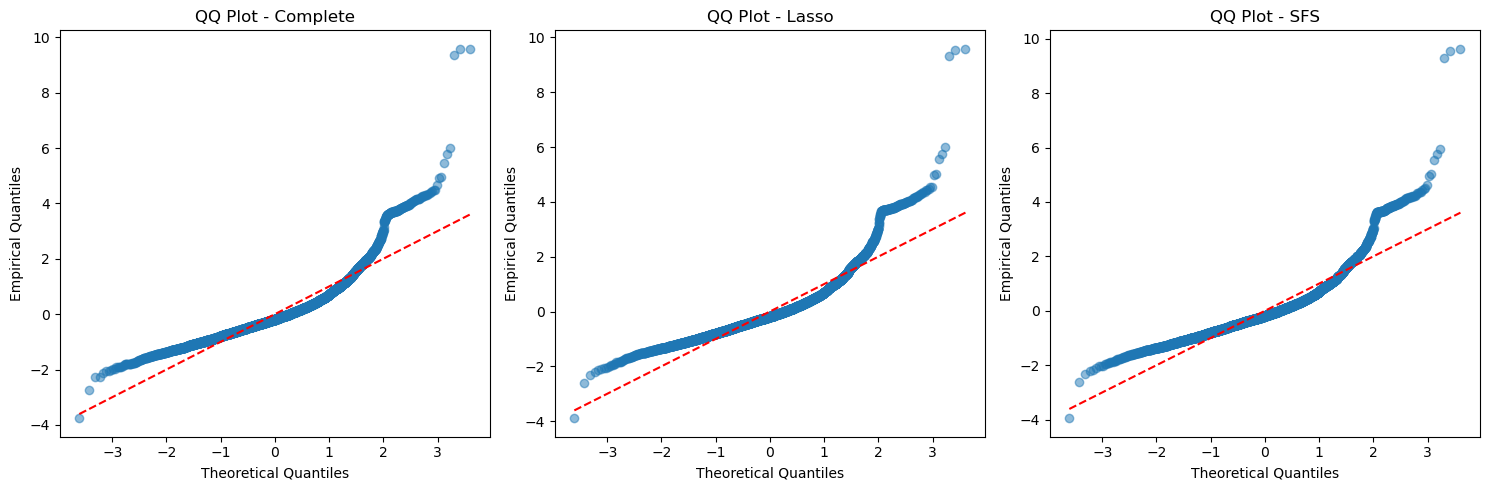

In [59]:
# Generate the theoretical quantiles for each set of residuals
theoretical_quantiles_complete = sm.ProbPlot(std_residuals_complete).theoretical_quantiles
theoretical_quantiles_lasso = sm.ProbPlot(std_residuals_lasso).theoretical_quantiles
theoretical_quantiles_SFS = sm.ProbPlot(std_residuals_SFS).theoretical_quantiles

# Generate the empirical quantiles for each set of residuals
empirical_quantiles_complete = sm.ProbPlot(std_residuals_complete).sample_quantiles
empirical_quantiles_lasso = sm.ProbPlot(std_residuals_lasso).sample_quantiles
empirical_quantiles_SFS = sm.ProbPlot(std_residuals_SFS).sample_quantiles

# Create the figure and subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot the QQ plot for std_residuals_complete
axes[0].scatter(theoretical_quantiles_complete, empirical_quantiles_complete, alpha=0.5)
axes[0].plot(theoretical_quantiles_complete, theoretical_quantiles_complete, color='r', linestyle='--')
axes[0].set_xlabel("Theoretical Quantiles")
axes[0].set_ylabel("Empirical Quantiles")
axes[0].set_title("QQ Plot - Complete")

# Plot the QQ plot for std_residuals_lasso
axes[1].scatter(theoretical_quantiles_lasso, empirical_quantiles_lasso, alpha=0.5)
axes[1].plot(theoretical_quantiles_lasso, theoretical_quantiles_lasso, color='r', linestyle='--')
axes[1].set_xlabel("Theoretical Quantiles")
axes[1].set_ylabel("Empirical Quantiles")
axes[1].set_title("QQ Plot - Lasso")

# Plot the QQ plot for std_residuals_SFS
axes[2].scatter(theoretical_quantiles_SFS, empirical_quantiles_SFS, alpha=0.5)
axes[2].plot(theoretical_quantiles_SFS, theoretical_quantiles_SFS, color='r', linestyle='--')
axes[2].set_xlabel("Theoretical Quantiles")
axes[2].set_ylabel("Empirical Quantiles")
axes[2].set_title("QQ Plot - SFS")

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plots
plt.show();

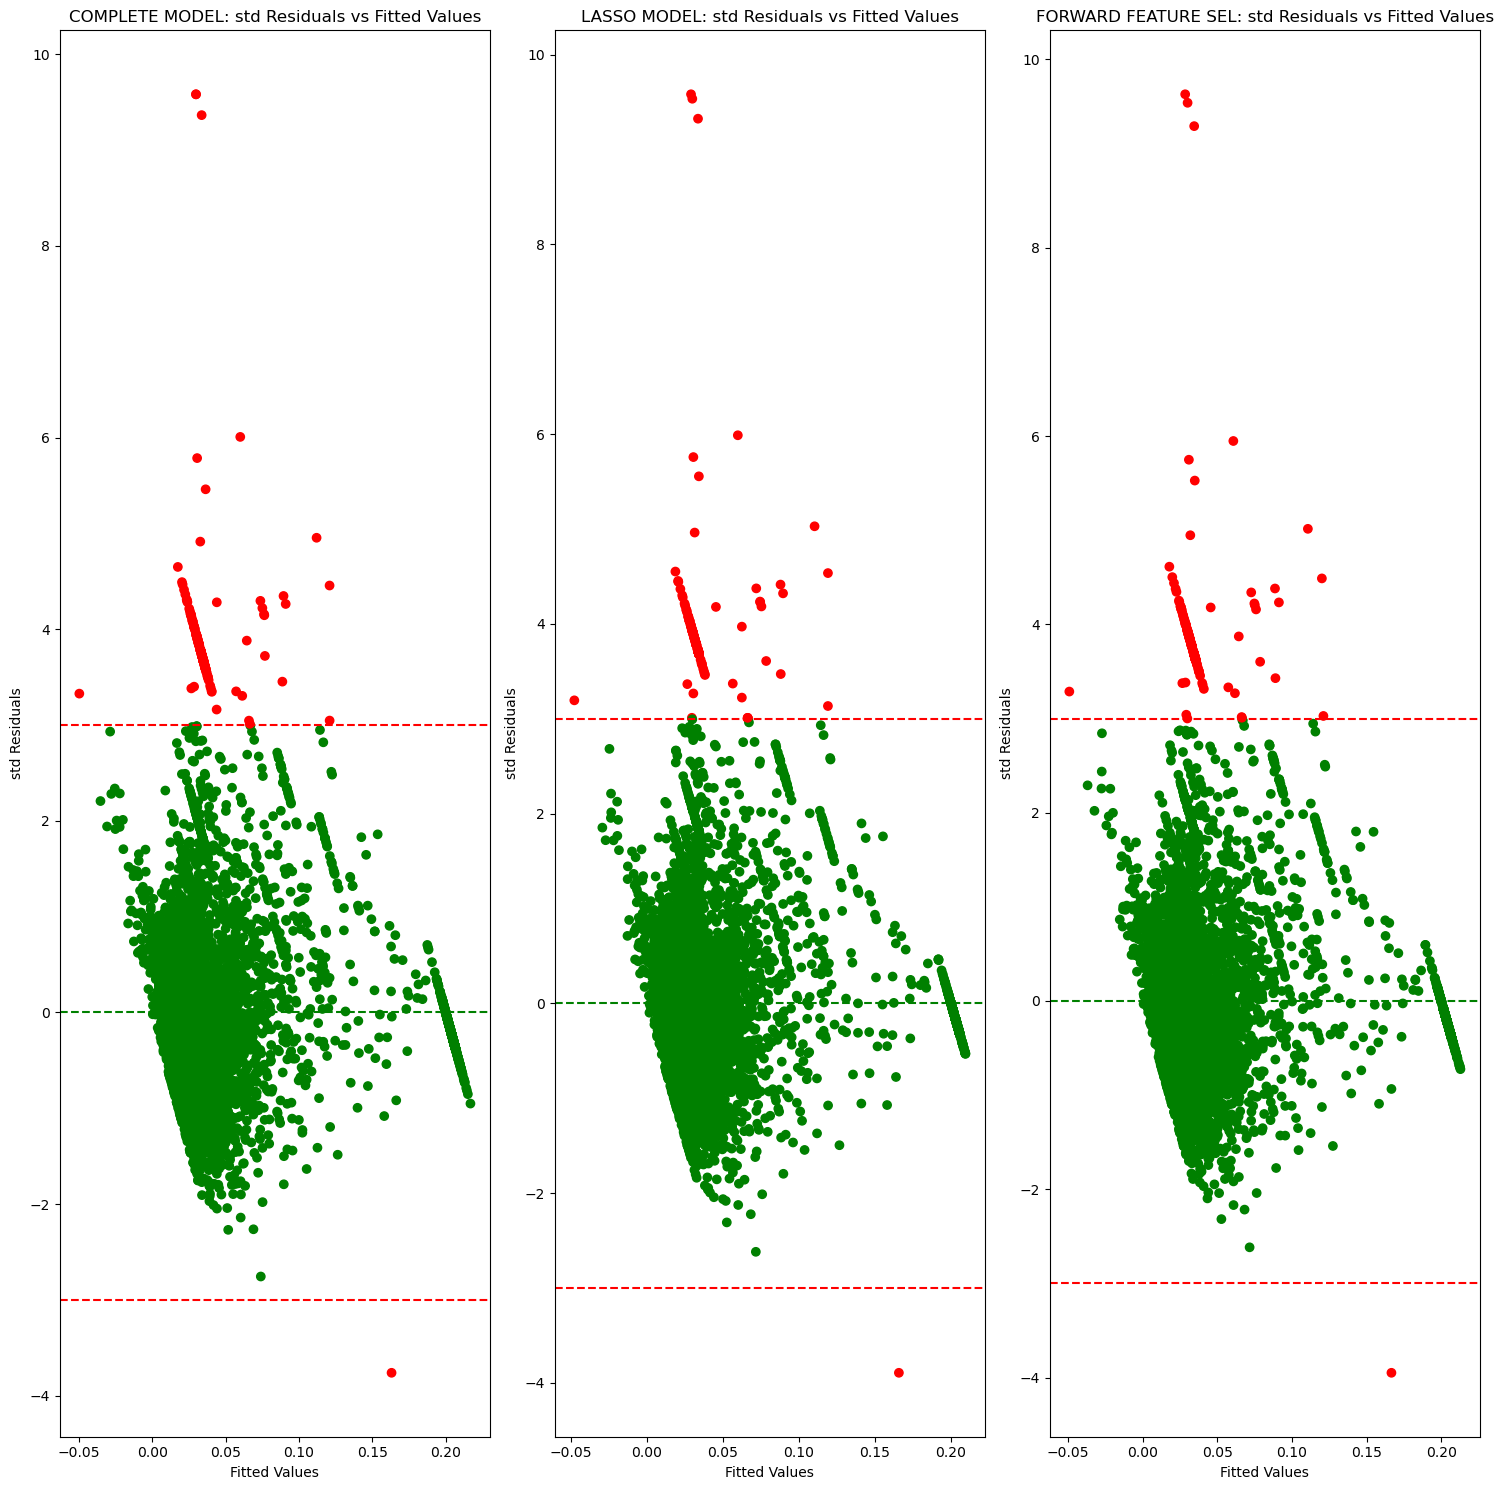

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15,15))

# COMPLETE MODEL
color_list = ["red" if value > 3 or value < -3 else "green" for value in std_residuals_complete]
axes[0].scatter(y_predict_complete, std_residuals_complete, color = color_list)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('std Residuals')
axes[0].set_title('COMPLETE MODEL: std Residuals vs Fitted Values')
axes[0].axhline(y=0, color="green", linestyle="--")
axes[0].axhline(y=3, color="red", linestyle="--")
axes[0].axhline(y=-3, color="red", linestyle="--")

# LASSO MODEL
color_list = ["red" if value > 3 or value < -3 else "green" for value in std_residuals_lasso]
axes[1].scatter(lasso_predicted, std_residuals_lasso, color = color_list)
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('std Residuals')
axes[1].set_title('LASSO MODEL: std Residuals vs Fitted Values')
axes[1].axhline(y=0, color="green", linestyle="--")
axes[1].axhline(y=3, color="red", linestyle="--")
axes[1].axhline(y=-3, color="red", linestyle="--")

# SFS MODEL 
color_list = ["red" if value > 3 or value < -3 else "green" for value in std_residuals_SFS]
axes[2].scatter(SFS_predict, std_residuals_SFS, color = color_list)
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('std Residuals')
axes[2].set_title('FORWARD FEATURE SEL: std Residuals vs Fitted Values')
axes[2].axhline(y=0, color="green", linestyle="--")
axes[2].axhline(y=3, color="red", linestyle="--")
axes[2].axhline(y=-3, color="red", linestyle="--")

plt.tight_layout()
plt.show();

<b> The diagnostic plots are acceptable! <b>
    
1.   The residuals are distributed as a random cloud (even thought the variance tends to be smaller with higher values of fitted Y, but we also have less points)
    In correspondence of negative fitted values of Y, the residuals are positive, since the value of the exit rates represent a percentage and are always greater or equal that zero.
1. The residuls are normal (QQplot is fine)
1. We don't have too many outliers   

### KNN linear predictor: 
Try to use the KNN linear predictor (another algorithm). 
Use a copy of the training data frame as we want to standardize it.
Use only the numerical variables. 
Standardize them by computing the Z score for each value of the dataframe.

In [61]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

In [62]:
#divide the df in X (predictors) and Y (target): 
target = "ExitRates"
yKNN = data_target[[target]]
XKNN = data_target.drop(target, axis = 1)

In [63]:
XKNN_num = XKNN[XKNN.columns[0:9]]

In [64]:
for name in XKNN_num.columns:
    XKNN_num[name] = (XKNN_num[name] - np.mean(XKNN_num[name].values))/np.std(XKNN_num[name].values)

C:\Users\Simone\AppData\Local\Temp\ipykernel_27084\174573507.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  XKNN_num[name] = (XKNN_num[name] - np.mean(XKNN_num[name].values))/np.std(XKNN_num[name].values)


In [65]:
KNNregr = KNeighborsRegressor(n_neighbors=2)
y_np = yKNN.to_numpy()
X_np = XKNN_num.to_numpy()

In [66]:
param_grid = {"n_neighbors": np.arange(1, 25)}
knn_gscv = GridSearchCV(KNNregr, param_grid, cv=5)
knn_gscv.fit(X_np, y_np)
best_k = knn_gscv.best_params_
print("the best number of K neighbours is {}".format(best_k['n_neighbors']));

the best number of K neighbours is 9


##### CV for the model evaluation
perform 20 times the CV to have a CI for the R^2 of the KNN model to evaluate its behavihour on the training set. 
It's very slow so we have run it one time and then we will report the results.

In [67]:
#### SUUUUUPER slow. Do you really want to run it?
# Run it one time and provide directly the results.
#results = []
#for i in range(20):
    
    #cv = KFold(n_splits=5, random_state=i, shuffle=True)

    #use k-fold CV to evaluate model
    #scores = cross_val_score(knn_gscv, X_np, y_np, cv=5, scoring = 'r2')
    #media = np.mean(abs(scores))
    #results.append(media)
results = [0.8984039676914831, 0.8979912045977754, 0.8998317008071884, 0.8998460342983353, 
           0.8989144631204654, 0.8998269676775299, 0.8995093349323271, 0.9000741368570419, 
           0.89946556381077, 0.9001049896891156, 0.8992664541147128, 0.8988886113068693, 
           0.8981514043169874, 0.8989938357633551, 0.8986042992911599, 0.8993349322320242, 
           0.8995335835560614, 0.8978916034430728, 0.8986528601190187, 0.8986420937215753]

results = np.array(results)
media = np.mean(results)
sd = np.std(results)
U = media + 1.96*sd
L = media - 1.96*sd
print(f'media = {media}, U_bound = {U}, L_bound = {L}')

media = 0.8990964020673436, U_bound = 0.9004090801986765, L_bound = 0.8977837239360108


#### Visual inspection of the results of the KNN 
Check the residuals: check the residuals against the fitted values to check if there is some specific trend 
check the QQ plot to verify that they are normal
plot the STD residuals, in 'red' outliers (STD residulas with abs value higher than 3)

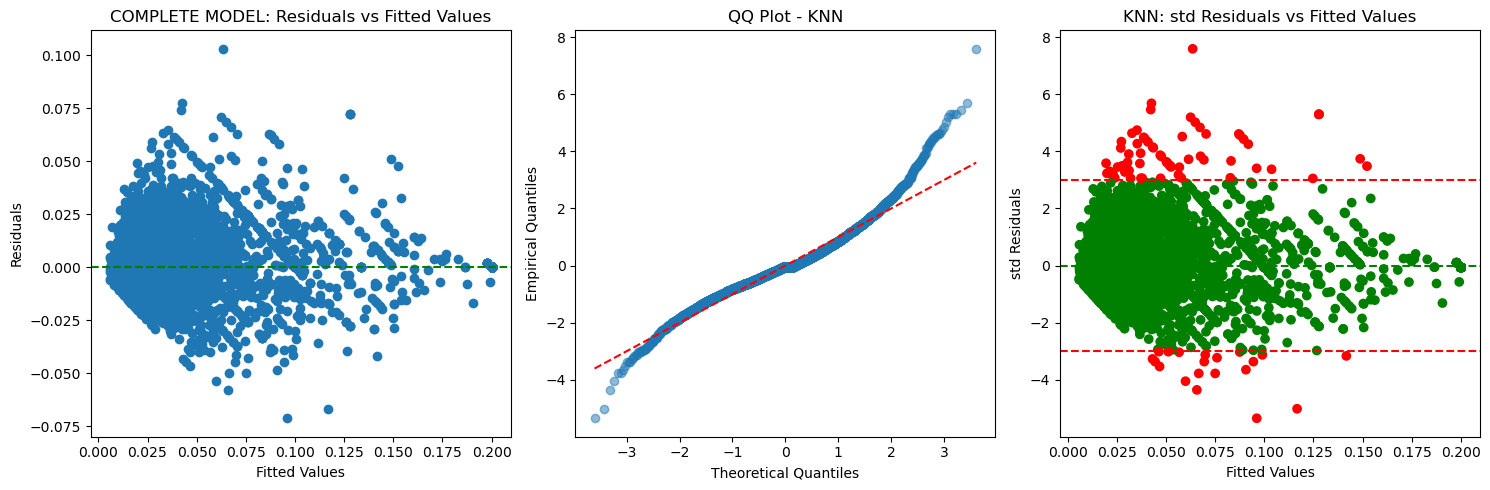

In [68]:
#KNN MODEL
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
yKNN_predicted = knn_gscv.predict(X_np)
residualsKNN = y.flatten() - yKNN_predicted.flatten()
axes[0].scatter(yKNN_predicted, residualsKNN)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('COMPLETE MODEL: Residuals vs Fitted Values')
axes[0].axhline(y=0, color="green", linestyle="--")

std_residualsKNN = (residualsKNN - np.mean(residualsKNN))/np.std(residualsKNN)
std_residualsKNN = std_residualsKNN

# Generate the theoretical quantiles for each set of residuals
theoretical_quantilesKNN = sorted(sm.ProbPlot(std_residualsKNN).theoretical_quantiles)
# Generate the empirical quantiles for each set of residuals
empirical_quantilesKNN = sorted(sm.ProbPlot(std_residualsKNN).sample_quantiles)

# Plot the QQ plot for std_residuals_lasso
axes[1].scatter(theoretical_quantilesKNN, empirical_quantilesKNN, alpha=0.5)
axes[1].plot(theoretical_quantilesKNN, theoretical_quantilesKNN, color='r', linestyle='--')
axes[1].set_xlabel("Theoretical Quantiles")
axes[1].set_ylabel("Empirical Quantiles")
axes[1].set_title("QQ Plot - KNN")

# STD residulas for the KNN MODEL 
color_list = ["red" if value > 3 or value < -3 else "green" for value in std_residualsKNN]
axes[2].scatter(yKNN_predicted, std_residualsKNN, color = color_list)
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('std Residuals')
axes[2].set_title('KNN: std Residuals vs Fitted Values')
axes[2].axhline(y=0, color="green", linestyle="--")
axes[2].axhline(y=3, color="red", linestyle="--")
axes[2].axhline(y=-3, color="red", linestyle="--")

plt.tight_layout()
plt.show();

<b> The diagnostic plots are acceptable! <b>
    
1.   The residuals are distributed as a random cloud (even thought the variance tends to be smaller with higher values of fitted Y, but we also have less points)
1. The residuls are normal (QQplot is fine)
1. We don't have too many outliers    

## Prediction of ExitRates variable
We decide to use the features selected by LASSO because it was among the models who performed better in CV and also include categorical variables. Our KNN also performs very well but we only did for continous variables.

<b> A problem: <b>
 
We are predicting 'ExitRates', a percentage that has to be between 0 and 1.
1. if the predicted value is negative, we will predict zero
1. if the predicted value is higher than one, we will predict one.

In [69]:
np_na_df = na_df.to_numpy()
lasso_prediction = lasso.predict(np_na_df)

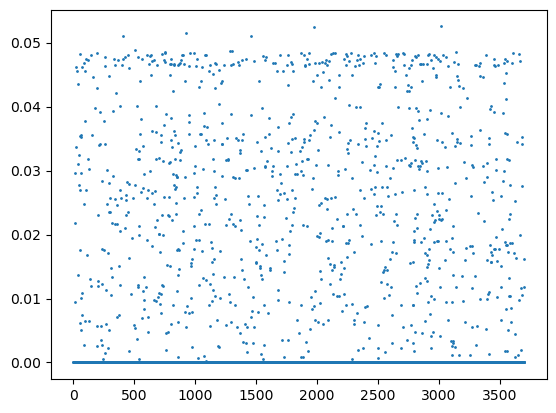

In [70]:
lasso_prediction_corrected = np.clip(lasso_prediction, 0, 1)
plt.scatter(range(len(lasso_prediction_corrected)), lasso_prediction_corrected, s = 1)

### Interpretation of the coefficients
Get the coeffients that are different from zero. Separate the positive coeffients from the negative ones. 
Print input features with a positive and negative effect.

In [71]:
pos_features = [tup[0] for tup in feature_coef_list if tup[1] > 0]
neg_features = [tup[0] for tup in feature_coef_list if tup[1] < 0]
null_features = [tup[0] for tup in feature_coef_list if tup[1] == 0]

print("Features with a positive effect in the lasso model are:\n {}\n\n".format(pos_features))
print("Features with a negative effect in the lasso model are:\n {}\n\n".format(neg_features))
print("Features with no effect in the lasso model are:\n {}".format(null_features))

Features with a positive effect in the lasso model are:
 ['BounceRates', 'SpecialDay', 'Month_Dec', 'Month_June', 'Region_3', 'TrafficType_1', 'TrafficType_3', 'TrafficType_13', 'VisitorType_Other', 'OperatingSystems_2']


Features with a negative effect in the lasso model are:
 ['Administrative', 'Administrative_Duration', 'ProductRelated', 'PageValues', 'Weekend', 'Revenue', 'Month_Oct', 'Month_Sep', 'Region_7', 'TrafficType_2', 'TrafficType_4', 'TrafficType_19', 'VisitorType_New_Visitor', 'OperatingSystems_3', 'OperatingSystems_6']


Features with no effect in the lasso model are:
 ['Informational', 'Informational_Duration', 'ProductRelated_Duration', 'Month_Aug', 'Month_Feb', 'Month_Jul', 'Month_Mar', 'Month_May', 'Month_Nov', 'Browser_1', 'Browser_2', 'Browser_3', 'Browser_4', 'Browser_5', 'Browser_6', 'Browser_7', 'Browser_8', 'Browser_10', 'Browser_13', 'Region_1', 'Region_2', 'Region_4', 'Region_5', 'Region_6', 'Region_8', 'Region_9', 'TrafficType_5', 'TrafficType_6', 'TrafficT

<div align="center">

# Politecnico of Milan  
## MSc. in Bioinformatics and Computational Genomics  
### Machine Learning  
#### A.Y. 2022-23  

### Classification of the target variable "Revenue"

**Students:** Francesco Pelizzari, Simone Corbetta  
**ID:** 10942582, 10951358  
**Emails:** francesco.pelizzari1@studenti.unimi.it simone.corbetta1@studenti.unimi.it  

</div>

## Classification: Index 
1. Loading the complete dataset 
    1. Preprocessing the dataset 
    1. divide in into the predictors and the target 
    1. normalization 
1. Logistic Regression
    1. Feature selection
    1. Performance with threshold = 0.5
    1. Performance with empirical threshold
    1. Importance of the exit rates variable (random permutations)
1. LDA
    1. Feature selection
    1. Performance with threshold = 0.5
    1. Performance with empirical threshold
    1. Importance of the exit rates variable (random permutations)
1. QDA
    1. Feature selection
    1. Performance with threshold = 0.5
    1. Performance with empirical threshold
    1. Importance of the exit rates variable (random permutations)
1. Logistic Regression: Polynomial Features
    1. CV to find the best degree
    1. Performance with threshold = 0.5
    1. Performance with empirical threshold
    1. Importance of the exit rates variable (random permutations)
1. SVM 
    1. Finding the best kernel and the best C
    1. Perforance on the whole dataset
    1. Performance in CV with threshold = 0.5
    1. Performance in CV with empirical threshold
    1. SVM and feature selection 
        1. Evaluation of the SVM feature selected 
    1. SVM with numerical variables only
        1. Evaluation of the SVM  with numerical variables only
1. KNN 
    1. Finding the best K using CV 
    1. Performance on the whole dataset
    1. Perfomance in CV using threshold = 0.5
    1. Perfomance in CV using empirical threshold
    1. KNN with numerical variables only
        1. Evaluation of the SVM  with numerical variables only
1. Conclusions: What is the best model
    1. plotting the accuracy, sensitivity, precision with threshold = 0.5 
    1. plotting the accuracy, sensitivity, precision with empirical threshold 
    1. ROC curves and AUC for the different models
1. Inspecting the usefullness of the variable ExitRates 
    1. in Logistic Regression
        1. Comparison: Same performance, worse interpretability
    1. in LDA
        1. Comparison: Same performance, same interpretability
    1. in QDA
    1. in KNN (numerical only)
    1. in SVM
    1. in SVM (numerical only)
1. Conclusions about the usefullness of the Variable ExitRates

In [72]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
#silence warnings of category 'future warnings': present is already hard enough...

%matplotlib inline
import statsmodels.api as sm
import statsmodels.formula.api as smf
np.random.seed(0)

## Load the complete dataset * 
\* we will cross-validate it.
##### preprocessing
Set the categorical variables using one hot encoding. 
Set the revenue variable and weekend variable as integer from boolean.
##### divide the dataset into X (predictors) and y (target: revenue)
Now X contains the data and y contains the target (revenue).
Get general information on the data in input using the function describe. 

In [73]:
data = complete_df.copy()
columns_to_convert = ["Month","Browser","Region","TrafficType","VisitorType","OperatingSystems"]
data_target = pd.get_dummies(data, columns=columns_to_convert)
data_target["Revenue"] = data_target["Revenue"].astype(int)
data_target["Weekend"] = data_target["Weekend"].astype(int)

In [74]:
X = data_target.drop(["Revenue"], axis = 1)
y = data_target["Revenue"]

In [75]:
X.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,VisitorType_Other,VisitorType_Returning_Visitor,OperatingSystems_1,OperatingSystems_2,OperatingSystems_3,OperatingSystems_4,OperatingSystems_5,OperatingSystems_6,OperatingSystems_7,OperatingSystems_8
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,...,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,...,0.006894,0.855718,0.209651,0.535361,0.207218,0.038767,0.000487,0.001541,0.000568,0.006407
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,...,0.082745,0.351390,0.407076,0.498768,0.405330,0.193048,0.022055,0.039226,0.023821,0.079791
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


##### normalization of the numeric columns
each value in the numeri column is min-max normalized. 
Use again the function describe to check the results of the normalization.

In [76]:
X_numeric_columns = list(X.columns[0:11])
for name in X_numeric_columns: 
    X[name] = (X[name].values - np.min(X[name].values))/(np.max(X[name].values) - np.min(X[name].values))
X.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,VisitorType_Other,VisitorType_Returning_Visitor,OperatingSystems_1,OperatingSystems_2,OperatingSystems_3,OperatingSystems_4,OperatingSystems_5,OperatingSystems_6,OperatingSystems_7,OperatingSystems_8
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,...,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,0.085747,0.023779,0.020982,0.013522,0.045009,0.018676,0.110957,0.215364,0.016279,0.061427,...,0.006894,0.855718,0.209651,0.535361,0.207218,0.038767,0.000487,0.001541,0.000568,0.006407
std,0.123029,0.052013,0.052923,0.055209,0.063086,0.029913,0.242442,0.242983,0.051328,0.198917,...,0.082745,0.351390,0.407076,0.498768,0.405330,0.193048,0.022055,0.039226,0.023821,0.079791
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.009929,0.002878,0.000000,0.071429,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.037037,0.002207,0.000000,0.000000,0.025532,0.009362,0.015562,0.125782,0.000000,0.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.148148,0.027438,0.000000,0.000000,0.053901,0.022887,0.084063,0.250000,0.000000,0.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


##### Info about the revenue variable
How many YES and NO revenues in the dataset? How about the percentage?

In [77]:
YES_revenues = np.sum(data_target["Revenue"] == True)
NO_revenues = np.sum(data_target["Revenue"] == False)
print("Total number of positive revenues: {}".format(YES_revenues))
print("Total number of negative revenues: {}".format(NO_revenues))
revenue_perc = YES_revenues/(YES_revenues + NO_revenues)
print("% of positive revenues: {}".format(revenue_perc))

Total number of positive revenues: 1908
Total number of negative revenues: 10422
% of positive revenues: 0.15474452554744525


## Logistic Regression. 
<b> Feature selection and CV of the model <b>
    
<b> Step forward feature selection <b>
    
Use RFE to select the top i features. 
As i ranges from 1 to 75, build 75 models each time adding the best feature. 
At the end, get the kept features for all the 75 models.

In [78]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
# Create a logistic regression model
model = LogisticRegression(solver = 'newton-cholesky', penalty = "l2")
kept = []
for i in range(1, len(X.columns) + 1):
    rfe = RFE(model, n_features_to_select=i, verbose = False)
    rfe.fit(X, y)
    # Get a list with the fea
    kept_feat = X.columns[rfe.support_]
    kept.append(kept_feat)

RFE(estimator=LogisticRegression(solver='newton-cholesky'),
    n_features_to_select=1, verbose=False)

RFE(estimator=LogisticRegression(solver='newton-cholesky'),
    n_features_to_select=2, verbose=False)

RFE(estimator=LogisticRegression(solver='newton-cholesky'),
    n_features_to_select=3, verbose=False)

RFE(estimator=LogisticRegression(solver='newton-cholesky'),
    n_features_to_select=4, verbose=False)

RFE(estimator=LogisticRegression(solver='newton-cholesky'),
    n_features_to_select=5, verbose=False)

...

RFE(estimator=LogisticRegression(solver='newton-cholesky'),
    n_features_to_select=70, verbose=False)

RFE(estimator=LogisticRegression(solver='newton-cholesky'),
    n_features_to_select=71, verbose=False)

RFE(estimator=LogisticRegression(solver='newton-cholesky'),
    n_features_to_select=72, verbose=False)

RFE(estimator=LogisticRegression(solver='newton-cholesky'),
    n_features_to_select=73, verbose=False)

RFE(estimator=LogisticRegression(solver='newton-cholesky'),
    n_features_to_select=74, verbose=False)

### Logistic Regression model feature selection: 
We have build all the 75 models with the different features, which is the best? 
Find the best model (and the best features) as the one with the highest accuracy in CV.

In [79]:
from sklearn.linear_model import LogisticRegressionCV
acc= []
for j in range(len(kept)):
    LR_cv_mod = LogisticRegressionCV(cv=5, random_state=0, solver = 'newton-cholesky', penalty = "l2").fit(X[kept[j]], y)
    cv = KFold(n_splits=5, random_state=0, shuffle=True)
    scores = cross_val_score(LR_cv_mod,X[kept[j]], y,
                                 cv=cv, n_jobs=-1)
   
    media = mean(absolute(scores))
    acc.append(media)

max_index = acc.index(max(acc))
best_features_LogReg = kept[max_index]

print("the best features for the Logistic Regression model are:\n {}\n".format(list(best_features_LogReg)))
print("the best model accuracy, corresponding to the highest accuracy that we found, is:\n{}".format(acc[max_index]))

the best features for the Logistic Regression model are:
 ['Informational', 'ProductRelated', 'ProductRelated_Duration', 'ExitRates', 'PageValues', 'Month_Feb', 'Month_Nov', 'Browser_12', 'TrafficType_15']

the best model accuracy, corresponding to the highest accuracy that we found, is:
0.8857258718572586


### Fit the logistic regression model with the selected features (from the forward feature selection). 
<b> BEGIN WIHT A THRESHOLD OF 50% <b>

Provide a few indices to evaluate the model. Plot the confusion matrix. Impose a P threshold = 50%. 
Eventually we will change it (we have a very good specificity but a bad sensitivity).

In [80]:
accuracy_list_logistic = []
sensitivity_list_logistic = []
precision_list_logistic = []
model_LogReg = LogisticRegression(solver = 'newton-cholesky', penalty = "l2")
for i in range(30):
    
    cv = KFold(n_splits=5, random_state=i, shuffle=True)
    
    accuracy = cross_val_score(model_LogReg,X[best_features_LogReg], y, scoring='accuracy',
                             cv=cv, n_jobs=-1)
    
    sensitivity = cross_val_score(model_LogReg, X[best_features_LogReg], y, cv=cv, scoring='recall', n_jobs=-1)
    precision = cross_val_score(model_LogReg, X[best_features_LogReg], y, cv=cv, scoring = "precision", n_jobs=-1)
    
    
    mean_sensitivity = mean(absolute(sensitivity))
    sensitivity_list_logistic.append(mean_sensitivity)
    mean_accuracy = mean(absolute(accuracy))
    accuracy_list_logistic.append(mean_accuracy)
    mean_precision = mean(absolute(precision))
    precision_list_logistic.append(mean_precision)
   
    
accuracy_logistic = sum(accuracy_list_logistic)/len(accuracy_list_logistic)
sensitivity_logistic = sum(sensitivity_list_logistic)/len(sensitivity_list_logistic)
precision_logistic = sum(precision_list_logistic)/len(precision_list_logistic)


print("Logistic Regression with threshold = 0.5%. Indeces: ")
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}".format(accuracy_logistic, sensitivity_logistic, precision_logistic))

Logistic Regression with threshold = 0.5%. Indeces: 
Accuracy: 0.8751851851851852
Sensitivity (recall): 0.27109780736421946
Precision: 0.7777689528105122


### Performance of the LogReg model using "empirical threshold".
As we have a very good specificity and a bad sensitivity, try to use an empirical threshold. 
Set the threshold equal to the percentage of the YES revenue (about 15%). 
CV the model to obtain the indeces of the performances to compare it with the other models.

In [81]:
from sklearn.metrics import accuracy_score, recall_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import precision_score
from sklearn.metrics import roc_auc_score
accuracy_list_logthresh = []
sensitivity_list_logthresh = []
precision_list_logthresh = []
matthews_list_logthresh = []


threshold = revenue_perc

for i in range(30):
    cv = KFold(n_splits=5, random_state=i, shuffle=True)

    y_pred_probs = cross_val_predict(model_LogReg, X[best_features_LogReg], y, cv=cv, method='predict_proba')

    y_pred = (y_pred_probs[:, 1] >= threshold).astype(int)

    accuracy = accuracy_score(y, y_pred)
    sensitivity = recall_score(y, y_pred)
    precision = precision_score(y, y_pred)
    matt = matthews_corrcoef(y, y_pred)
    

    accuracy_list_logthresh.append(accuracy)
    sensitivity_list_logthresh.append(sensitivity)
    matthews_list_logthresh.append(matt)
    precision_list_logthresh.append(precision)
    

    
accuracy_logistic_empthreshold = sum(accuracy_list_logthresh) / len(accuracy_list_logthresh)
variance_acc_logistic_empthreshold = np.std(np.array(accuracy_list_logthresh))
sensitivity_logistic_empthreshold = sum(sensitivity_list_logthresh) / len(sensitivity_list_logthresh)
variance_sens_logistic_empthreshold = np.std(np.array(sensitivity_list_logthresh))
matthews_logistic_empthreshold = sum(matthews_list_logthresh)/len(matthews_list_logthresh)
variance_matthewslogistic_emptthreshold = np.std(np.array(matthews_list_logthresh))                                           
precision_logistic_empthreshold = sum(precision_list_logthresh)/len(precision_list_logthresh)
variance_precision_emptthreshold = np.std(np.array(precision_list_logthresh))

print("Logistic Regression with threshold = {}. Indeces: ".format(revenue_perc))
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}\nMatthews index: {}".format(accuracy_logistic_empthreshold, sensitivity_logistic_empthreshold, precision_logistic_empthreshold, matthews_logistic_empthreshold))

Logistic Regression with threshold = 0.15474452554744525. Indeces: 
Accuracy: 0.7991943768586103
Sensitivity (recall): 0.8079489867225718
Precision: 0.4222242720529004
Matthews index: 0.47969513047051465


### What is the importance of ExitRate in the logistic model?
In order to understan the importance of each feature in our model, we used permutation_importance. 
We will get the features in order of importance.


In [82]:
from sklearn.inspection import permutation_importance

model_LogReg.fit(X[best_features_LogReg], y)
results = permutation_importance(model_LogReg,X[best_features_LogReg], y, scoring='accuracy', n_repeats=10, random_state=42)

# Get feature importances and their indices
importances = results.importances_mean
indices = np.argsort(importances)
results_mean = results.importances_mean

feature_rankings = []
for idx in indices:
    feature_rankings.append(X.columns[idx])

print("the feature in order of importance are:\n{}".format(feature_rankings))

LogisticRegression(solver='newton-cholesky')

the feature in order of importance are:
['Administrative', 'PageValues', 'ExitRates', 'BounceRates', 'Informational', 'ProductRelated_Duration', 'Administrative_Duration', 'Informational_Duration', 'ProductRelated']


<b> Importance ExitRates in the Logistic regression model <b> 
    
For logistic Regression, ExitRates is the 3rd most useful variable in the model. 
Anyway it may be useful to check what is the rank of the matrix of the features. (How many features are correlated among the ones that we have selected?)

In [83]:
from numpy.linalg import matrix_rank
rank=matrix_rank(X[best_features_LogReg], tol=None, hermitian=False)
print(f'rank of matrix is {rank},while there are {len(feature_rankings)} features in the model')

rank of matrix is 9,while there are 9 features in the model


## LDA
Try now to use a LDA model. 
Perform feature selection as in the Logistic Regression (loop over the variables, each time add the best one, building 75 models). 
Once we have the 75 models, find the one that performs better in CV (highest accuracy). 
*Keep the moedls with the selected features that perform better.*

As first step, build the 75 models:

In [84]:
#Build the 75 models
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
model_LDA = LDA(solver = "lsqr", shrinkage = "auto")
kept_LDA = []
for i in range(1, len(X.columns) + 1):
    # Use RFE to select the top 10 features
    rfe_lda = RFE(model_LDA, n_features_to_select=i)
    rfe_lda.fit(X, y)
    kept_feat = X.columns[rfe_lda.support_]
    kept_LDA.append(kept_feat)

RFE(estimator=LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
    n_features_to_select=1)

RFE(estimator=LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
    n_features_to_select=2)

RFE(estimator=LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
    n_features_to_select=3)

RFE(estimator=LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
    n_features_to_select=4)

RFE(estimator=LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
    n_features_to_select=5)

...

RFE(estimator=LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
    n_features_to_select=70)

RFE(estimator=LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
    n_features_to_select=71)

RFE(estimator=LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
    n_features_to_select=72)

RFE(estimator=LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
    n_features_to_select=73)

RFE(estimator=LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
    n_features_to_select=74)

### LDA Feature selection
We have build all the 75 models with the different features, which is the best? 
Find the best model (and the best features) as the one with the highest accuracy in CV.

In [85]:
#find the best model (the one with the highest accuracy) and the features that the model will keep.
acc_lda= []
for j in range(len(kept_LDA)):
    lda = LDA(solver = "lsqr", shrinkage = "auto")
    cv = KFold(n_splits=5, random_state=0, shuffle=True)
    scores = cross_val_score(lda, X[kept_LDA[j]], y, cv=cv)
    media = np.mean(scores)
    acc_lda.append(media)
    
max_index = acc_lda.index(max(acc_lda))
best_features_lda = kept_LDA[max_index]
print("the best features for the LDA are:\n {}\n".format(list(best_features_lda)))
print("the accuracy of the best LDA model is {}".format(max(acc_lda)))

the best features for the LDA are:
 ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Weekend', 'Month_Aug', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'Browser_2', 'Browser_3', 'Browser_4', 'Browser_5', 'Browser_6', 'Browser_7', 'Browser_8', 'Browser_10', 'Browser_11', 'Browser_12', 'Browser_13', 'Region_1', 'Region_2', 'Region_5', 'Region_6', 'Region_8', 'Region_9', 'TrafficType_1', 'TrafficType_2', 'TrafficType_3', 'TrafficType_5', 'TrafficType_6', 'TrafficType_7', 'TrafficType_8', 'TrafficType_10', 'TrafficType_11', 'TrafficType_13', 'TrafficType_14', 'TrafficType_15', 'TrafficType_16', 'TrafficType_19', 'TrafficType_20', 'VisitorType_New_Visitor', 'VisitorType_Other', 'VisitorType_Returning_Visitor', 'OperatingSystems_1', 'OperatingSystems_2', 'OperatingSystems_3', 'Op

### Fit the LDA model with the selected features (from the forward feature selection). 
<b> BEGIN WIHT A THRESHOLD OF 50% <b>

Provide a few indices to evaluate the model. Plot the confusion matrix. Impose a P threshold = 50%. 
Eventually we will change it (we have a very good specificity but a bad sensitivity).

In [86]:
accuracy_list_LDA = []
sensitivity_list_LDA = []
precision_list_LDA = []

for i in range(30):
    cv = KFold(n_splits=5, random_state=i, shuffle=True)
    #use k-fold CV to evaluate model
    accuracy = cross_val_score(model_LDA, X[best_features_lda], y, scoring='accuracy',
                             cv=cv, n_jobs=-1)
    
    sensitivity = cross_val_score(model_LDA,  X[best_features_lda], y, cv=cv, scoring='recall', n_jobs=-1)
    precision = cross_val_score(model_LDA,  X[best_features_lda], y, cv=cv, scoring = "precision", n_jobs=-1)
    
    mean_sensitivity = mean(absolute(sensitivity))
    sensitivity_list_LDA.append(mean_sensitivity)
    mean_accuracy = mean(absolute(accuracy))
    accuracy_list_LDA.append(mean_accuracy)
    mean_precision = mean(absolute(precision))
    precision_list_LDA.append(mean_precision)
    
accuracy_LDA = sum(accuracy_list_LDA)/len(accuracy_list_LDA)
sensitivity_LDA = sum(sensitivity_list_LDA)/len(sensitivity_list_LDA)
precision_LDA = sum(precision_list_LDA)/len(precision_list_LDA)

print("LDA model with threshold = 0.5%. Indeces: ")
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}".format(accuracy_LDA, sensitivity_LDA, precision_LDA))



LDA model with threshold = 0.5%. Indeces: 
Accuracy: 0.8803919978372534
Sensitivity (recall): 0.344989314100218
Precision: 0.7453496924365423


### Performance of the LDA model using "empirical threshold".
As we have a very good specificity and a bad sensitivity, try to use an empirical threshold. 
Set the threshold equal to the percentage of the YES revenue (about 15%). 
CV the model to obtain the indeces of the performances to compare it with the other models.

In [87]:
accuracy_list_LDA_empthr = []
sensitivity_list_LDA_empthr = []
precision_list_LDA_empthr = []
matthews_list_LDA_empthr = []

threshold = revenue_perc 

for i in range(30):
    cv = KFold(n_splits=5, random_state=i, shuffle=True)

    y_pred_probs = cross_val_predict(model_LDA, X[best_features_lda], y, cv=cv, method='predict_proba')

    y_pred = (y_pred_probs[:, 1] >= threshold).astype(int)

    accuracy = accuracy_score(y, y_pred)
    sensitivity = recall_score(y, y_pred)
    precision = precision_score(y, y_pred)
    matt = matthews_corrcoef(y, y_pred)

    accuracy_list_LDA_empthr.append(accuracy)
    sensitivity_list_LDA_empthr.append(sensitivity)
    matthews_list_LDA_empthr.append(matt)
    precision_list_LDA_empthr.append(precision)

    
accuracy_LDA_empthreshold = sum(accuracy_list_LDA_empthr) / len(accuracy_list_LDA_empthr)
sensitivity_LDA_empthreshold = sum(sensitivity_list_LDA_empthr) / len(sensitivity_list_LDA_empthr)
matthews_LDA_empthreshold = sum(matthews_list_LDA_empthr)/len(matthews_list_LDA_empthr)
precision_LDA_empthreshold = sum(precision_list_LDA_empthr)/len(precision_list_LDA_empthr)
variance_acc_LDA_empthreshold = np.std(np.array(accuracy_list_LDA_empthr))
variance_sens_LDA_empthreshold = np.std(np.array(sensitivity_list_LDA_empthr))
variance_matthewsLDA_emptthreshold = np.std(np.array(matthews_list_LDA_empthr))
variance_precisionLDA_emptthreshold = np.std(np.array(precision_list_LDA_empthr))

print("LDA with threshold = {}. Indeces: ".format(revenue_perc))
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}\nMatthews index: {}".format(accuracy_LDA_empthreshold, sensitivity_LDA_empthreshold, precision_LDA_empthreshold, matthews_LDA_empthreshold))

LDA with threshold = 0.15474452554744525. Indeces: 
Accuracy: 0.8809948634766155
Sensitivity (recall): 0.6329315164220827
Precision: 0.6115891884415263
Matthews index: 0.551594054573349


### What is the importance of ExitRate in the logistic model?
In order to understan the importance of each feature in our model, we used permutation_importance. 
We will get the features in order of importance.

In [88]:
from sklearn.inspection import permutation_importance

# Fit your model (e.g., RandomForestClassifier) on the training data

model_LDA.fit(X[best_features_lda], y)
# Calculate permutation importance
results = permutation_importance(model_LDA,X[best_features_lda], y, scoring='accuracy', n_repeats=10, random_state=42)

# Get feature importances and their indices
importances = results.importances_mean
indices = np.argsort(importances)

# Print feature importance rankings
feature_rankings = []
for idx in indices:
    feature_rankings.append(X.columns[idx])

# Return the list of features in order of importance
print(feature_rankings)

LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')

['BounceRates', 'Browser_5', 'TrafficType_10', 'TrafficType_2', 'Browser_2', 'Region_2', 'TrafficType_1', 'Month_June', 'Browser_6', 'Browser_7', 'TrafficType_12', 'Browser_11', 'Region_4', 'TrafficType_7', 'TrafficType_17', 'TrafficType_19', 'Browser_9', 'Region_1', 'TrafficType_9', 'Month_Aug', 'Region_8', 'Region_9', 'TrafficType_8', 'Browser_8', 'TrafficType_18', 'TrafficType_6', 'Informational', 'Month_May', 'TrafficType_20', 'Month_Jul', 'Month_Oct', 'Informational_Duration', 'Browser_10', 'Month_Sep', 'Month_Feb', 'Administrative', 'SpecialDay', 'TrafficType_4', 'Month_Mar', 'Region_3', 'Administrative_Duration', 'Browser_3', 'Browser_4', 'Weekend', 'Browser_12', 'TrafficType_3', 'Browser_13', 'ProductRelated_Duration', 'TrafficType_14', 'TrafficType_5', 'Browser_1', 'ProductRelated', 'Region_7', 'Region_5', 'TrafficType_16', 'TrafficType_15', 'Month_Dec', 'Region_6', 'TrafficType_13', 'Month_Nov', 'TrafficType_11', 'ExitRates', 'PageValues']


<b> Importance ExitRates in the LDA model <b> 
    
For LDA, ExitRates is the <b> 2nd least <b> useful variable in the model. 
Anyway it may be useful to check what is the rank of the matrix of the features. (How many features are correlated among the ones that we have selected?)

In [89]:
rank=matrix_rank(X[best_features_lda], tol=None, hermitian=False)
print(f'rank of matrix is {rank},while there are {len(feature_rankings)} features in the model')

rank of matrix is 61,while there are 63 features in the model


## QDA
Try now to use a QDA model. 
Perform feature selection as in the Logistic Regression (loop over the variables, each time add the best one, building 75 models). 
Once we have the 75 models, find the one that performs better in CV (highest accuracy). 
*Keep the moedls with the selected features that perform better.*

As first step, build the 75 models:

In [90]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

# Select the top k features
kept_qda = []
for k in range(1,len(X.columns) + 1):
    selector = SelectKBest(chi2, k = k)
    X_selected = selector.fit_transform(X, y)
    # Get the indices of the selected features
    selected_indices = selector.get_support(indices=True)
    # Get the names of the selected features
    selected_features = X.columns[selected_indices]
    kept_qda.append(selected_features)

### QDA CV
We have build all the 75 models with the different features, which is the best? 
Find the best model (and the best features) as the one with the highest accuracy in CV.

In [91]:
warnings.simplefilter(action='ignore', category=UserWarning)
# Variables are collinear. Ok, but still worth to try to train a QDA. 
#Ok, they should not be correlated when using QDA, but we are doing this for classification purposes...
#Try to evaluate the model. If it is anyway good, we will keep it anyway.

acc_qda= []
for j in range(len(kept_qda)):
    qda = QDA()
    scores = cross_val_score(qda, X[kept_qda[j]], y, cv=5)
    media = np.mean(scores)
    acc_qda.append(media)
    
max_index = acc_qda.index(max(acc_qda))
best_features_qda = kept_qda[max_index]

In [92]:
print("the best features for the QDA are {}".format(list(best_features_qda)))
print("the accuracy of the best QDA model is {}".format(max(acc_qda)))

the best features for the QDA are ['PageValues', 'Month_Nov']
the accuracy of the best QDA model is 0.8850770478507706


### Fit the QDA model with the selected features (from the forward feature selection). 
<b> BEGIN WIHT A THRESHOLD OF 50% <b>

Provide a few indices to evaluate the model. Impose a P threshold = 50%. 
Eventually we will change it (we have a very good specificity but a bad sensitivity).

In [93]:
accuracy_list_QDA = []
sensitivity_list_QDA = []
precision_list_QDA = []
matthews_list_QDA = []

model_QDA = QDA()
for i in range(30):
    cv = KFold(n_splits=5, random_state=i, shuffle=True)
    
    sensitivity = cross_val_score(model_QDA,  X[best_features_qda], y, cv=cv, scoring='recall', n_jobs=-1)
    sensitivity = cross_val_score(model_QDA,  X[best_features_qda], y, cv=cv, scoring='recall', n_jobs=-1)
    precision = cross_val_score(model_QDA,  X[best_features_qda], y, cv=cv, scoring = 'precision', n_jobs=-1)
    
    mean_accuracy = mean(absolute(accuracy))
    accuracy_list_QDA.append(mean_accuracy)
    mean_sensitivity = mean(absolute(sensitivity))
    sensitivity_list_QDA.append(mean_sensitivity)
    mean_precision = mean(absolute(precision))
    precision_list_QDA.append(mean_precision)
    
    accuracy_QDA = sum(accuracy_list_QDA)/len(accuracy_list_QDA)
    sensitivity_QDA = sum(sensitivity_list_QDA)/len(sensitivity_list_QDA)
    precision_QDA = sum(precision_list_QDA)/len(precision_list_QDA)

print("QDA model with threshold = 0.5%. Indeces: ")
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}".format(accuracy_QDA, sensitivity_QDA, precision_QDA))

QDA model with threshold = 0.5%. Indeces: 
Accuracy: 0.8814274128142745
Sensitivity (recall): 0.3884616762588386
Precision: 0.7479361533569285


### Performance of the QDA model using "empirical threshold".
As we have a very good specificity and a bad sensitivity, try to use an empirical threshold. 
Set the threshold equal to the percentage of the YES revenue (about 15%). 
CV the model to obtain the indeces of the performances to compare it with the other models.

In [94]:
accuracy_list_QDA_empthr = []
sensitivity_list_QDA_empthr = []
precision_list_QDA_empthr = []
matthews_list_QDA_empthr = []

threshold = revenue_perc 


for i in range(30):
    cv = KFold(n_splits=5, random_state=i, shuffle=True)

    y_pred_probs = cross_val_predict(model_QDA, X[best_features_qda], y, cv=cv, method='predict_proba')

    y_pred = (y_pred_probs[:, 1] >= threshold).astype(int)

    accuracy = accuracy_score(y, y_pred)
    sensitivity = recall_score(y, y_pred)
    precision = precision_score(y, y_pred)
    matt = matthews_corrcoef(y, y_pred)

    accuracy_list_QDA_empthr.append(accuracy)
    sensitivity_list_QDA_empthr.append(sensitivity)
    matthews_list_QDA_empthr.append(matt)
    precision_list_QDA_empthr.append(precision)

    
accuracy_QDA_empthreshold = sum(accuracy_list_QDA_empthr) / len(accuracy_list_QDA_empthr)
sensitivity_QDA_empthreshold = sum(sensitivity_list_QDA_empthr) / len(sensitivity_list_QDA_empthr)
matthews_QDA_empthreshold = sum(matthews_list_QDA_empthr)/len(matthews_list_QDA_empthr)
precision_QDA_empthreshold = sum(precision_list_QDA_empthr)/len(precision_list_QDA_empthr)
variance_acc_QDA_empthreshold = np.std(np.array(accuracy_list_QDA_empthr))
variance_sens_QDA_empthreshold = np.std(np.array(sensitivity_list_QDA_empthr))
variance_matthewsQDA_emptthreshold = np.std(np.array(matthews_list_QDA_empthr))
variance_precisionQDA_emptthreshold = np.std(np.array(precision_list_QDA_empthr))


print("QDA with threshold = {}. Indeces: ".format(revenue_perc))
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}\nMatthews index: {}".format(accuracy_QDA_empthreshold, sensitivity_QDA_empthreshold, precision_QDA_empthreshold, matthews_QDA_empthreshold))


QDA with threshold = 0.15474452554744525. Indeces: 
Accuracy: 0.8916896458502299
Sensitivity (recall): 0.5071104122990914
Precision: 0.7100898188810468
Matthews index: 0.5412437766240947


### What is the importance of ExitRate in the QDA?
Differently from the first two models, <b> in the QDA ExitRates is not even selected by the Feature Selection <b>. 

## Logistic Regression: Try to add polynomial features 
Try different degrees (for 1 to 6) bor the polynomial features of the logistic regression and seach for the best one in CV.
Fit the polynomial model on the same features that we found for the basic logistic.

In [95]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

degrees = range(1, 6)
cv_scores = []

for degree in degrees:
    model_LogRegpoly = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('LogReg', LogisticRegression(solver='liblinear', penalty='l2'))])

    scores = cross_val_score(model_LogRegpoly, X[best_features_LogReg], y, cv=StratifiedKFold(5), scoring='accuracy',error_score="raise")
    cv_scores.append(scores.mean())

best_degree = degrees[cv_scores.index(max(cv_scores))]
print("Best degree:", best_degree)

Best degree: 2


<b> The best degree is *2* <b>

### Perfomance of the polynomial logistic regression model with the selected features (from the forward feature selection). 
<b> BEGIN WIHT A THRESHOLD OF 50% <b>

Provide a few indices to evaluate the model. Impose a P threshold = 50%. 
Eventually we will change it (we have a very good specificity but a bad sensitivity).

In [96]:
accuracy_list_logreg_poly = []
sensitivity_list_logreg_poly = []
precision_list_logreg_poly = []
poly = PolynomialFeatures(degree=best_degree)
X_poly = poly.fit_transform(X[best_features_LogReg])
model_LogRegpoly = LogisticRegression(solver='liblinear', penalty='l2')
for i in range(30):
    cv = KFold(n_splits=5, random_state=i, shuffle=True)
    
    accuracy = cross_val_score(model_LogRegpoly,X[best_features_LogReg], y, scoring='accuracy',
                             cv=cv, n_jobs=-1)
    
    sensitivity = cross_val_score(model_LogRegpoly, X[best_features_LogReg], y, cv=cv, scoring='recall', n_jobs=-1)
    precision = cross_val_score(model_LogRegpoly, X[best_features_LogReg], y, cv=cv, scoring = "precision", n_jobs=-1)
    
    mean_sensitivity = mean(absolute(sensitivity))
    sensitivity_list_logreg_poly.append(mean_sensitivity)
    mean_accuracy = mean(absolute(accuracy))
    accuracy_list_logreg_poly.append(mean_accuracy)
    mean_precision = mean(absolute(precision))
    precision_list_logreg_poly.append(mean_precision)
    
accuracy_logistic_poly = sum(accuracy_list_logreg_poly)/len(accuracy_list_logreg_poly)
sensitivity_logistic_poly = sum(sensitivity_list_logreg_poly)/len(sensitivity_list_logreg_poly)
precision_logistic_poly = sum(precision_list_logreg_poly)/len(precision_list_logreg_poly)

print("Logistic Regression with polinomial degree = 2, with threshold = 0.5%. Indeces: ")
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}".format(accuracy_logistic_poly, sensitivity_logistic_poly, precision_logistic_poly))

Logistic Regression with polinomial degree = 2, with threshold = 0.5%. Indeces: 
Accuracy: 0.8752149229521493
Sensitivity (recall): 0.27130454663915243
Precision: 0.7778511804124885


### Performance of the polynomial LogReg model using "empirical threshold".
As we have a very good specificity and a bad sensitivity, try to use an empirical threshold. 
Set the threshold equal to the percentage of the YES revenue (about 15%). 
CV the model to obtain the indeces of the performances to compare it with the other models.

In [97]:
accuracy_list_polyreg = []
sensitivity_list_polyreg = []
precision_list_polyreg = []
matthews_list_polyreg = []

threshold = 0.25 

for i in range(30):
    cv = KFold(n_splits=5, random_state=i, shuffle=True)

    y_pred_probs = cross_val_predict(model_LogRegpoly, X[best_features_LogReg], y, cv=cv, method='predict_proba')

    y_pred = (y_pred_probs[:, 1] >= threshold).astype(int)

    accuracy = accuracy_score(y, y_pred)
    sensitivity = recall_score(y, y_pred)
    precision = precision_score(y, y_pred)
    matt = matthews_corrcoef(y, y_pred)

    accuracy_list_polyreg.append(accuracy)
    sensitivity_list_polyreg.append(sensitivity)
    matthews_list_polyreg.append(matt)
    precision_list_polyreg.append(precision)

    
accuracy_logistic_poly_empthreshold = sum(accuracy_list_polyreg) / len(accuracy_list_polyreg)
sensitivity_logistic_poly_empthreshold = sum(sensitivity_list_polyreg) / len(sensitivity_list_polyreg)
matthews_logistic_poly_empthreshold = sum(matthews_list_polyreg)/len(matthews_list_polyreg)
precision_logistic_poly_empthreshold = sum(precision_list_polyreg)/len(precision_list_polyreg)
variance_logistic_poly_empthreshold = np.std(np.array(accuracy_list_polyreg))
variance_sens_logistic_poly_empthreshold = np.std(np.array(sensitivity_list_polyreg))
variance_matthews_logistic_poly_emptthreshold = np.std(np.array(matthews_list_polyreg))
variance_precision_logistic_poly_emptthreshold = np.std(np.array(precision_list_polyreg))

print("Logistic Regression with poly degree = 2 and with threshold = {}. Indeces: ".format(revenue_perc))
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}\nMatthews index: {}".format(accuracy_logistic_poly_empthreshold, sensitivity_logistic_poly_empthreshold, precision_logistic_poly_empthreshold, matthews_logistic_poly_empthreshold))

Logistic Regression with poly degree = 2 and with threshold = 0.15474452554744525. Indeces: 
Accuracy: 0.8775155447418223
Sensitivity (recall): 0.5908630328441651
Precision: 0.6071055145059064
Matthews index: 0.5266796869689448


## Support vector machines
try different kernels. Find the best one through cross validation. 
Check the accuracy and other similar indeces for the performance. Check the best kernel and its accuracy score. 

In [98]:
from sklearn import svm
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
score = []
for kern in kernels:
    cv = KFold(n_splits=5, random_state=1, shuffle=True)
    model_SVM = svm.SVC(kernel=kern)
    scores = cross_val_score(model_SVM, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
    score.append(np.mean(scores))
max_index = score.index(max(score))
best_kernel = kernels[max_index]
acc_best_model = max(score)

In [99]:
print("the best kernel is " + best_kernel + " and its accuracy is {}".format(acc_best_model))

the best kernel is linear and its accuracy is 0.8829683698296836


### CV for the best C parameter
Try a few possible different Cs. Get the one that maximize the accuracy

In [100]:
C_s= [0.1,1,10,100]

score_c = []
   
for c in C_s:
    model_SVM = svm.SVC(kernel="linear",C=c)
    cv = KFold(n_splits=5, random_state=1, shuffle=True)
    scores_score = cross_val_score(model_SVM, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
    score_c.append(np.mean(scores_score))
best_score_c = score_c.index(max(score_c))
   

best_c = C_s[best_score_c]

In [101]:
from sklearn.metrics import accuracy_score, recall_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import precision_score

###  Accuracy of the SVM model 
With respect to the whole training set.

SVC(C=10, kernel='linear')

SVM with kernel: linear and with C: 10
accuracy: 0.8856447688564477
miscassification rate: 0.11435523114355228
sensitivity: 0.39360587002096437
specificity: 0.74800796812749


<AxesSubplot:>

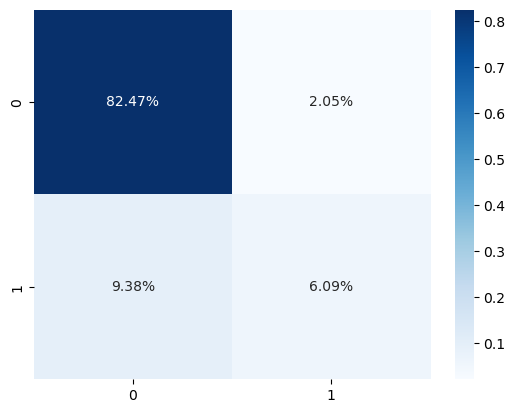

In [102]:
from sklearn.metrics import confusion_matrix
model_SVM = svm.SVC(kernel="linear",C=10)
model_SVM.fit(X, y)
predicted_SVM = model_SVM.predict(X)

accuracy_SVM = accuracy_score(y, predicted_SVM)
misclass_SVM = 1-accuracy_SVM
sensitivity_SVM = recall_score(y, predicted_SVM)
specificity_SVM  = precision_score(y, predicted_SVM)
print("SVM with kernel: {} and with C: {}".format(best_kernel, best_c))
print("accuracy: {}\nmiscassification rate: {}\nsensitivity: {}\nspecificity: {}".format(accuracy_SVM, misclass_SVM, sensitivity_SVM, specificity_SVM))

cf_matrix = confusion_matrix(y, predicted_SVM)
sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True, 
            fmt='.2%', cmap='Blues')

### CV the SVM model. 
<b> BEGIN WIHT A THRESHOLD OF 50% <b>

Provide a few indices to evaluate the model. Impose a P threshold = 50%. 
Eventually we will change it (we have a very good specificity but a bad sensitivity).

In [103]:
accuracy_list_SVM = []
sensitivity_list_SVM = []
precision_list_SVM = []
model_SVM = svm.SVC(kernel="linear",C=10,probability=True)
for i in range(1):
    
    cv = KFold(n_splits=5, random_state=i, shuffle=True)
    
    accuracy = cross_val_score(model_SVM,X, y, scoring='accuracy',
                             cv=cv, n_jobs=-1)
    
    sensitivity = cross_val_score(model_SVM, X, y, cv=cv, scoring='recall', n_jobs=-1)
    precision = cross_val_score(model_SVM, X, y, cv=cv, scoring = "precision", n_jobs=-1)
    
    mean_sensitivity = mean(absolute(sensitivity))
    sensitivity_list_SVM.append(mean_sensitivity)
    mean_accuracy = mean(absolute(accuracy))
    accuracy_list_SVM.append(mean_accuracy)
    mean_precision = mean(absolute(precision))
    precision_list_SVM.append(mean_precision)
    
accuracy_SVM = sum(accuracy_list_SVM)/len(accuracy_list_SVM)
sensitivity_SVM = sum(sensitivity_list_SVM)/len(sensitivity_list_SVM)
precision_SVM = sum(precision_list_SVM)/len(precision_list_SVM)

print("SVM model. Linear Kernel. All the features. Indeces: ")
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}".format(accuracy_SVM, sensitivity_SVM, precision_SVM))

SVM model. Linear Kernel. All the features. Indeces: 
Accuracy: 0.8847526358475264
Sensitivity (recall): 0.3874281199618454
Precision: 0.7460742921138961


### Performance of the SVM model using "empirical threshold".
As we have a very good specificity and a bad sensitivity, try to use an empirical threshold. 
Set the threshold equal to the percentage of the YES revenue (about 15%). 
CV the model to obtain the indeces of the performances to compare it with the other models.

In [104]:
accuracy_list_SVM_empthr = []
sensitivity_list_SVM_empthr = []
precision_list_SVM_empthr = []
matthews_list_SVM_empthr = []

threshold = revenue_perc 

for i in range(1):
    cv = KFold(n_splits=5, random_state=i, shuffle=True)

    y_pred_probs = cross_val_predict(model_SVM, X, y, cv=cv, method='predict_proba')

    y_pred = (y_pred_probs[:, 1] >= threshold).astype(int)

    accuracy = accuracy_score(y, y_pred)
    sensitivity = recall_score(y, y_pred)
    precision = precision_score(y, y_pred)
    matt = matthews_corrcoef(y, y_pred)

    accuracy_list_SVM_empthr.append(accuracy)
    sensitivity_list_SVM_empthr.append(sensitivity)
    matthews_list_SVM_empthr.append(matt)
    precision_list_SVM_empthr.append(precision)

    
accuracy_SVM_empthreshold = sum(accuracy_list_SVM_empthr) / len(accuracy_list_SVM_empthr)
sensitivity_SVM_empthreshold = sum(sensitivity_list_SVM_empthr) / len(sensitivity_list_SVM_empthr)
matthews_SVM_empthreshold = sum(matthews_list_SVM_empthr)/ len(matthews_list_SVM_empthr)
precision_SVM_empthreshold = sum(precision_list_SVM_empthr)/ len(precision_list_SVM_empthr)

print("SVM with threshold = {}. Indeces: ".format(revenue_perc))
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}\nMatthews index: {}".format(accuracy_SVM_empthreshold, sensitivity_SVM_empthreshold, precision_SVM_empthreshold, matthews_SVM_empthreshold))

SVM with threshold = 0.15474452554744525. Indeces: 
Accuracy: 0.8927007299270073
Sensitivity (recall): 0.6640461215932913
Precision: 0.6500769625448948
Matthews index: 0.5934463319688663


### feature selection for SVM
What are the most significant features that we can include in the SVM model?

In [105]:
from sklearn.feature_selection import RFE
from sklearn.svm import SVC
svc_lin=SVC(kernel='linear',C=10)
svm_rfe_model=RFE(estimator=svc_lin)
svm_rfe_model_fit=svm_rfe_model.fit(X,y)
feat_index = pd.Series(data = svm_rfe_model_fit.ranking_, index = X.columns)
signi_feat_rfe = feat_index[feat_index==1].index
print('Significant features from RFE for the SVM model:\n {}'.format(signi_feat_rfe))


Significant features from RFE for the SVM model:
 Index(['Administrative', 'Administrative_Duration', 'Informational',
       'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues',
       'SpecialDay', 'Month_Aug', 'Month_Dec', 'Month_Feb', 'Month_Jul',
       'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct',
       'Month_Sep', 'Browser_3', 'Browser_6', 'Browser_10', 'Browser_11',
       'Browser_12', 'Browser_13', 'TrafficType_5', 'TrafficType_6',
       'TrafficType_13', 'TrafficType_16', 'VisitorType_New_Visitor',
       'OperatingSystems_1', 'OperatingSystems_2', 'OperatingSystems_3',
       'OperatingSystems_4', 'OperatingSystems_5', 'OperatingSystems_6',
       'OperatingSystems_7', 'OperatingSystems_8'],
      dtype='object')


### CV the SVM model (feature selected). 
<b> BEGIN WIHT A THRESHOLD OF 50% <b>

Provide a few indices to evaluate the model. Impose a P threshold = 50%. 
Eventually we will change it (we have a very good specificity but a bad sensitivity).

In [106]:
accuracy_listrfe_SVM = []
sensitivity_listrfe_SVM = []
precision_listrfe_SVM = []
#model_SVM = svm.SVC(kernel="linear")
model_SVM_RFE_sel = svm.SVC(kernel="linear",probability=True)
for i in range(1):
    
    cv = KFold(n_splits=5, random_state=i, shuffle=True)
    
    accuracy = cross_val_score(model_SVM_RFE_sel,X[signi_feat_rfe], y, scoring='accuracy',
                             cv=cv, n_jobs=-1)
    
    sensitivity = cross_val_score(model_SVM_RFE_sel, X[signi_feat_rfe], y, cv=cv, scoring='recall', n_jobs=-1)
    precision = cross_val_score(model_SVM_RFE_sel, X[signi_feat_rfe], y, cv=cv, scoring = "precision", n_jobs=-1)
    
    mean_sensitivity = mean(absolute(sensitivity))
    sensitivity_listrfe_SVM.append(mean_sensitivity)
    mean_accuracy = mean(absolute(accuracy))
    accuracy_listrfe_SVM.append(mean_accuracy)
    mean_precision = mean(absolute(precision))
    precision_listrfe_SVM.append(mean_precision)
    
accuracy_SVMrfe = sum(accuracy_listrfe_SVM)/len(accuracy_listrfe_SVM)
sensitivity_SVMrfe = sum(sensitivity_listrfe_SVM)/len(sensitivity_listrfe_SVM)
precision_SVMrfe = sum(precision_listrfe_SVM)/len(precision_listrfe_SVM)

print("SVM model. Linear Kernel. Only selected features by RFE algorithm. Indeces: ")
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}".format(accuracy_SVMrfe, sensitivity_SVMrfe, precision_SVMrfe))

SVM model. Linear Kernel. Only selected features by RFE algorithm. Indeces: 
Accuracy: 0.8829683698296836
Sensitivity (recall): 0.34973989617669726
Precision: 0.767732174814119


### Performance of the SVM (feature selected) model using "empirical threshold".
As we have a very good specificity and a bad sensitivity, try to use an empirical threshold. 
Set the threshold equal to the percentage of the YES revenue (about 15%). 
CV the model to obtain the indeces of the performances to compare it with the other models.

In [107]:
accuracy_list_SVMred_empthr = []
sensitivity_list_SVMred_empthr = []
precision_list_SVMred_empthr = []
matthews_list_SVMred_empthr = []

threshold = revenue_perc

for i in range(1):
    cv = KFold(n_splits=5, random_state=i, shuffle=True)

    y_pred_probs = cross_val_predict(model_SVM_RFE_sel, X[signi_feat_rfe], y, cv=cv, method='predict_proba')

    y_pred = (y_pred_probs[:, 1] >= threshold).astype(int)

    accuracy = accuracy_score(y, y_pred)
    sensitivity = recall_score(y, y_pred)
    precision = precision_score(y, y_pred)
    matt = matthews_corrcoef(y, y_pred)

    accuracy_list_SVMred_empthr.append(accuracy)
    sensitivity_list_SVMred_empthr.append(sensitivity)
    matthews_list_SVMred_empthr.append(matt)
    precision_list_SVMred_empthr.append(precision)

    
accuracy_SVMred_empthreshold = sum(accuracy_list_SVMred_empthr) / len(accuracy_list_SVMred_empthr)
sensitivity_SVMred_empthreshold = sum(sensitivity_list_SVMred_empthr) / len(sensitivity_list_SVMred_empthr)
matthews_SVMred_empthreshold = sum(matthews_list_SVMred_empthr)/len(matthews_list_SVMred_empthr)
precision_SVMred_empthreshold = sum(precision_list_SVMred_empthr)/len(precision_list_SVMred_empthr)


print("Reduced SVM with threshold = {}. Indeces: ".format(revenue_perc))
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}\nMatthews index: {}".format(accuracy_SVMred_empthreshold, sensitivity_SVMred_empthreshold, precision_SVMred_empthreshold, matthews_SVMred_empthreshold))

Reduced SVM with threshold = 0.15474452554744525. Indeces: 
Accuracy: 0.8914841849148418
Sensitivity (recall): 0.6619496855345912
Precision: 0.6457055214723927
Matthews index: 0.5894631378832749


## SVM using numerical variables only 
Re-fit the SVM model only with numerical variables

### CV the SVM model (numerical variables only). 
<b> BEGIN WIHT A THRESHOLD OF 50% <b>

Provide a few indices to evaluate the model. Impose a P threshold = 50%. 
Eventually we will change it (we have a very good specificity but a bad sensitivity).

In [108]:
accuracy_list_numonly_SVM = []
sensitivity_list_numonly_SVM = []
precision_list_numonly_SVM = []
#model_SVM = svm.SVC(kernel="linear")
model_SVM_numonly = svm.SVC(kernel=best_kernel, probability=True, C=best_c)
for i in range(1):
    
    cv = KFold(n_splits=5, random_state=i, shuffle=True)
    
    accuracy = cross_val_score(model_SVM_numonly,X[X_numeric_columns], y, scoring='accuracy',
                             cv=cv, n_jobs=-1)
    
    sensitivity = cross_val_score(model_SVM_numonly, X[X_numeric_columns], y, cv=cv, scoring='recall', n_jobs=-1)
    precision = cross_val_score(model_SVM_numonly, X[X_numeric_columns], y, cv=cv, scoring = "precision", n_jobs=-1)
    
    mean_sensitivity = mean(absolute(sensitivity))
    sensitivity_list_numonly_SVM.append(mean_sensitivity)
    mean_accuracy = mean(absolute(accuracy))
    accuracy_list_numonly_SVM.append(mean_accuracy)
    mean_precision = mean(absolute(precision))
    precision_list_numonly_SVM.append(mean_precision)
    
accuracy_SVM_numonly = sum(accuracy_list_numonly_SVM)/len(accuracy_list_numonly_SVM)
sensitivity_SVM_numonly = sum(sensitivity_list_numonly_SVM)/len(sensitivity_list_numonly_SVM)
precision_SVM_numonly = sum(precision_list_numonly_SVM)/len(precision_list_numonly_SVM)

print("SVM model. Linear Kernel. Only selected features bu RFE algorithm. Indeces: ")
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}".format(accuracy_SVM_numonly, sensitivity_SVM_numonly, precision_SVM_numonly))

SVM model. Linear Kernel. Only selected features bu RFE algorithm. Indeces: 
Accuracy: 0.8860502838605028
Sensitivity (recall): 0.4004259709670427
Precision: 0.7457474079119105


### Performance of the SVM (numerical only) model using "empirical threshold".
As we have a very good specificity and a bad sensitivity, try to use an empirical threshold. 
Set the threshold equal to the percentage of the YES revenue (about 15%). 
CV the model to obtain the indeces of the performances to compare it with the other models.

In [109]:
accuracy_list_SVM_numonly_empthr = []
sensitivity_list_SVM_numonly_empthr = []
precision_list_SVM_numonly_empthr = []
matthews_list_SVM_numonly_empthr = []

threshold = revenue_perc 

for i in range(1):
    cv = KFold(n_splits=5, random_state=i, shuffle=True)

    y_pred_probs = cross_val_predict(model_SVM_numonly, X[X_numeric_columns], y, cv=cv, method='predict_proba')

    y_pred = (y_pred_probs[:, 1] >= threshold).astype(int)

    accuracy = accuracy_score(y, y_pred)
    sensitivity = recall_score(y, y_pred)
    precision = precision_score(y, y_pred)
    matt = matthews_corrcoef(y, y_pred)

    accuracy_list_SVM_numonly_empthr.append(accuracy)
    sensitivity_list_SVM_numonly_empthr.append(sensitivity)
    matthews_list_SVM_numonly_empthr.append(matt)
    precision_list_SVM_numonly_empthr.append(precision)

    
accuracy_SVM_numonly_empthreshold = sum(accuracy_list_SVM_numonly_empthr) / len(accuracy_list_SVM_numonly_empthr)
sensitivity_SVM_numonly_empthreshold = sum(sensitivity_list_SVM_numonly_empthr) / len(sensitivity_list_SVM_numonly_empthr)
matthews_SVM_numonly_empthreshold = sum(matthews_list_SVM_numonly_empthr)/len(matthews_list_SVM_numonly_empthr)
precision_SVM_numonly_empthreshold = sum(precision_list_SVM_numonly_empthr)/len(precision_list_SVM_numonly_empthr)



print("Reduced SVM with threshold = {}. Indeces: ".format(revenue_perc))
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}\nMatthews index: {}".format(accuracy_SVM_numonly_empthreshold, sensitivity_SVM_numonly_empthreshold, precision_SVM_numonly_empthreshold, matthews_SVM_numonly_empthreshold))

Reduced SVM with threshold = 0.15474452554744525. Indeces: 
Accuracy: 0.8915652879156529
Sensitivity (recall): 0.6546121593291404
Precision: 0.6481577581733264
Matthews index: 0.5871792603406133


## Non parametric models: KNN
Get the number of neighobours through CV. 
Get some indeces about the performance. 

In [110]:
from sklearn.neighbors import KNeighborsClassifier
#create new a knn model
knn2 = KNeighborsClassifier()
#get the best number of neighbours with CV. set a max of 50, 
#if the best number of NN is = 50 we will eventually use an higher max
param_grid = {'n_neighbors': np.arange(1, 50)}
knn_bestK = GridSearchCV(knn2, param_grid, cv=5)
#fit model to data
knn_bestK.fit(X, y)
NN = knn_bestK.best_estimator_.n_neighbors
print("the best number of neighbours is {}".format(NN))

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])})

the best number of neighbours is 35


KNN polynomial model with 35 neighbours
accuracy: 0.8518248175182481
miscassification rate: 0.10843471208434707
sensitivity: 0.05188679245283019
specificity: 0.8461538461538461


<AxesSubplot:>

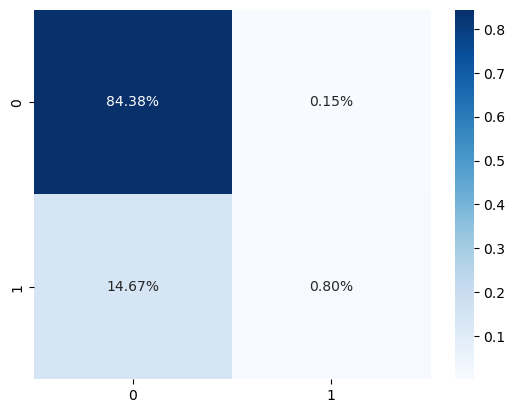

In [111]:
knn_pred = knn_bestK.predict(X)
accuracy_knn = accuracy_score(y, knn_pred)
misclass_knn = 1 - accuracy
sensitivity_knn = recall_score(y, knn_pred)
specificity_knn = precision_score(y, knn_pred)
print("KNN polynomial model with {} neighbours".format(NN))
print("accuracy: {}\nmiscassification rate: {}\nsensitivity: {}\nspecificity: {}".format(accuracy_knn, misclass_knn, sensitivity_knn, specificity_knn))

cf_matrix = confusion_matrix(y, knn_pred)
sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True, 
            fmt='.2%', cmap='Blues')

### CV the KNN model. 
<b> BEGIN WIHT A THRESHOLD OF 50% <b>

Provide a few indices to evaluate the model. Impose a P threshold = 50%. 
Eventually we will change it (we have a very good specificity but a bad sensitivity).

In [112]:
accuracy_list_KNN = []
sensitivity_list_KNN = []
precision_list_KNN = []

for i in range(1):
    
    cv = KFold(n_splits=5, random_state=i, shuffle=True)
    
    accuracy = cross_val_score(knn_bestK,X, y, scoring='accuracy',
                             cv=cv, n_jobs=-1)
    
    sensitivity = cross_val_score(knn_bestK, X, y, cv=cv, scoring='recall', n_jobs=-1)
    precision = cross_val_score(knn_bestK, X, y, cv=cv, scoring = "precision", n_jobs=-1)
    
    mean_sensitivity = mean(absolute(sensitivity))
    sensitivity_list_KNN.append(mean_sensitivity)
    mean_accuracy = mean(absolute(accuracy))
    accuracy_list_KNN.append(mean_accuracy)
    mean_precision = mean(absolute(precision))
    precision_list_KNN.append(mean_precision)
    
accuracy_KNN = sum(accuracy_list_KNN)/len(accuracy_list_KNN)
sensitivity_KNN = sum(sensitivity_list_KNN)/len(sensitivity_list_KNN)
precision_KNN = sum(precision_list_KNN)/len(precision_list_KNN)

print("KNN model. Indeces: ")
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}".format(accuracy_KNN, sensitivity_KNN, precision_KNN))

KNN model. Indeces: 
Accuracy: 0.8473641524736415
Sensitivity (recall): 0.03192706390467417
Precision: 0.6508179539758487


### Performance of the KNN model using "empirical threshold".
As we have a very good specificity and a bad sensitivity, try to use an empirical threshold. 
Set the threshold equal to the percentage of the YES revenue (about 15%). 
CV the model to obtain the indeces of the performances to compare it with the other models.

In [113]:
accuracy_list_knn_empthr = []
sensitivity_list_knn_empthr = []
precision_list_knn_empthr = []
matthews_list_knn_empthr = []

threshold = revenue_perc 

for i in range(1):
    cv = KFold(n_splits=5, random_state=i, shuffle=True)

    y_pred_probs = cross_val_predict(knn_bestK, X, y, cv=cv, method='predict_proba')

    y_pred = (y_pred_probs[:, 1] >= threshold).astype(int)

    accuracy = accuracy_score(y, y_pred)
    sensitivity = recall_score(y, y_pred)
    precision = precision_score(y, y_pred)
    matt = matthews_corrcoef(y, y_pred)

    accuracy_list_knn_empthr.append(accuracy)
    sensitivity_list_knn_empthr.append(sensitivity)
    matthews_list_knn_empthr.append(matt)
    precision_list_knn_empthr.append(precision)

    
accuracy_knn_empthreshold = sum(accuracy_list_knn_empthr) / len(accuracy_list_knn_empthr)
sensitivity_knn_empthreshold = sum(sensitivity_list_knn_empthr) / len(sensitivity_list_knn_empthr)
matthews_knn_empthreshold = sum(matthews_list_knn_empthr)/len(matthews_list_knn_empthr)
precision_knn_empthreshold = sum(precision_list_knn_empthr)/len(precision_list_knn_empthr)

print("KNN model with threshold = {}. Indeces: ".format(revenue_perc))
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}\nMatthews index: {}".format(accuracy_knn_empthreshold, sensitivity_knn_empthreshold, precision_knn_empthreshold, matthews_knn_empthreshold))

KNN model with threshold = 0.15474452554744525. Indeces: 
Accuracy: 0.6667477696674777
Sensitivity (recall): 0.690251572327044
Precision: 0.27238883143743536
Matthews index: 0.26126527392952803


### KNN with numerical variables only

<b> BEGIN WIHT A THRESHOLD OF 50% <b>

Provide a few indices to evaluate the model. Impose a P threshold = 50%. 
Eventually we will change it (we have a very good specificity but a bad sensitivity).

In [114]:
accuracy_list_KNN_numonly = []
sensitivity_list_KNN_numonly = []
precision_list_KNN_numonly = []
knn_numonly = KNeighborsClassifier(n_neighbors=35)
for i in range(1):
    
    cv = KFold(n_splits=5, random_state=i, shuffle=True)
    
    accuracy = cross_val_score(knn_numonly,X[X_numeric_columns], y, scoring='accuracy',
                             cv=cv, n_jobs=-1)
    
    sensitivity = cross_val_score(knn_bestK, X[X_numeric_columns], y, cv=cv, scoring='recall', n_jobs=-1)
    precision = cross_val_score(knn_bestK, X[X_numeric_columns], y, cv=cv, scoring = "precision", n_jobs=-1)
    
    mean_sensitivity = mean(absolute(sensitivity))
    sensitivity_list_KNN_numonly.append(mean_sensitivity)
    mean_accuracy = mean(absolute(accuracy))
    accuracy_list_KNN_numonly.append(mean_accuracy)
    mean_precision = mean(absolute(precision))
    precision_list_KNN_numonly.append(mean_precision)
    
accuracy_KNN_numonly = sum(accuracy_list_KNN_numonly)/len(accuracy_list_KNN_numonly)
sensitivity_KNN_numonly = sum(sensitivity_list_KNN_numonly)/len(sensitivity_list_KNN_numonly)
precision_KNN_numonly = sum(precision_list_KNN_numonly)/len(precision_list_KNN_numonly)

print("KNN with only numeric features Indeces: ")
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}".format(accuracy_KNN_numonly, sensitivity_KNN_numonly, precision_KNN_numonly))

KNN with only numeric features Indeces: 
Accuracy: 0.8832116788321167
Sensitivity (recall): 0.37131774812959395
Precision: 0.7461156559730362


### Performance of the KNN numerical only model using "empirical threshold".
As we have a very good specificity and a bad sensitivity, try to use an empirical threshold. 
Set the threshold equal to the percentage of the YES revenue (about 15%). 
CV the model to obtain the indeces of the performances to compare it with the other models.

In [115]:
accuracy_list_knn_numonly_empthr = []
sensitivity_list_knn_numonly_empthr = []
precision_list_knn_numonly_empthr = []
matthews_list_knn_numonly_empthr = []

threshold = revenue_perc 

for i in range(1):
    cv = KFold(n_splits=5, random_state=i, shuffle=True)

    y_pred_probs = cross_val_predict(knn_numonly, X[X_numeric_columns], y, cv=cv, method='predict_proba')

    y_pred = (y_pred_probs[:, 1] >= threshold).astype(int)

    accuracy = accuracy_score(y, y_pred)
    sensitivity = recall_score(y, y_pred)
    precision = precision_score(y, y_pred)
    matt = matthews_corrcoef(y, y_pred)

    accuracy_list_knn_numonly_empthr.append(accuracy)
    sensitivity_list_knn_numonly_empthr.append(sensitivity)
    matthews_list_knn_numonly_empthr.append(matt)
    precision_list_knn_numonly_empthr.append(precision)

    
accuracy_knn_numonly_empthreshold = sum(accuracy_list_knn_numonly_empthr) / len(accuracy_list_knn_numonly_empthr)
sensitivity_knn_numonly_empthreshold = sum(sensitivity_list_knn_numonly_empthr) / len(sensitivity_list_knn_numonly_empthr)
matthews_knn_numonly_empthreshold = sum(matthews_list_knn_numonly_empthr)/len(matthews_list_knn_numonly_empthr)
precision_knn_numonly_empthreshold = sum(precision_list_knn_numonly_empthr)/len(precision_list_knn_numonly_empthr)

print("KNN only with numerical features with threshold = {}. Indeces: ".format(revenue_perc))
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}\nMatthews index: {}".format(accuracy_knn_numonly_empthreshold, sensitivity_knn_numonly_empthreshold, precision_knn_numonly_empthreshold, matthews_knn_numonly_empthreshold))

KNN only with numerical features with threshold = 0.15474452554744525. Indeces: 
Accuracy: 0.8070559610705597
Sensitivity (recall): 0.7510482180293501
Precision: 0.4294276296074318
Matthews index: 0.46265377499530896


# Conclusion
<b> What is the best model? <b> 

## Plot the indeces for the different models

In [116]:
model = pd.Series(["model_LogReg","model_LDA", "model_QDA", "model_LogRegpoly", "model_SVM", "model_SVM_RFE_sel", "model_SVM_numonly", "knn_bestK", "knn_numonly"], name = "model")
accuracy = pd.Series([accuracy_logistic, accuracy_LDA, accuracy_QDA, accuracy_logistic_poly, accuracy_SVM, accuracy_SVMrfe, accuracy_SVM_numonly, accuracy_KNN, accuracy_KNN_numonly], name = "accuracy")
sensitivity = pd.Series([sensitivity_logistic,sensitivity_LDA, sensitivity_QDA, sensitivity_logistic_poly, sensitivity_SVM, sensitivity_SVMrfe, sensitivity_SVM_numonly, sensitivity_KNN, sensitivity_KNN_numonly], name = "sensitivity")
precision = pd.Series([precision_logistic, precision_LDA, precision_QDA, precision_logistic_poly, precision_SVM, precision_SVMrfe, precision_SVM_numonly, precision_KNN, precision_KNN_numonly], name = "precision")
accuracy_empirical_thr = pd.Series([accuracy_logistic_empthreshold, accuracy_LDA_empthreshold, accuracy_QDA_empthreshold, accuracy_logistic_poly_empthreshold, accuracy_SVM_empthreshold, accuracy_SVMred_empthreshold, accuracy_SVM_numonly_empthreshold, accuracy_knn_empthreshold, accuracy_knn_numonly_empthreshold], name = "accuracy_empiricalthr")
sensitivity_empirical_thr = pd.Series([sensitivity_logistic_empthreshold, sensitivity_LDA_empthreshold, sensitivity_QDA_empthreshold, sensitivity_logistic_poly_empthreshold, sensitivity_SVM_empthreshold, sensitivity_SVMred_empthreshold, sensitivity_SVM_numonly_empthreshold, sensitivity_knn_empthreshold, sensitivity_knn_numonly_empthreshold], name = "sensitivity_empthr")
precision_empirical_thr = pd.Series([precision_logistic_empthreshold, precision_LDA_empthreshold, precision_QDA_empthreshold, precision_logistic_poly_empthreshold, precision_SVM_empthreshold, precision_SVMred_empthreshold, precision_SVM_numonly_empthreshold, precision_knn_empthreshold, precision_knn_numonly_empthreshold], name = "precision_empthr")

summary_df = pd.concat([model, accuracy, sensitivity, precision, accuracy_empirical_thr, sensitivity_empirical_thr, precision_empirical_thr], axis=1)

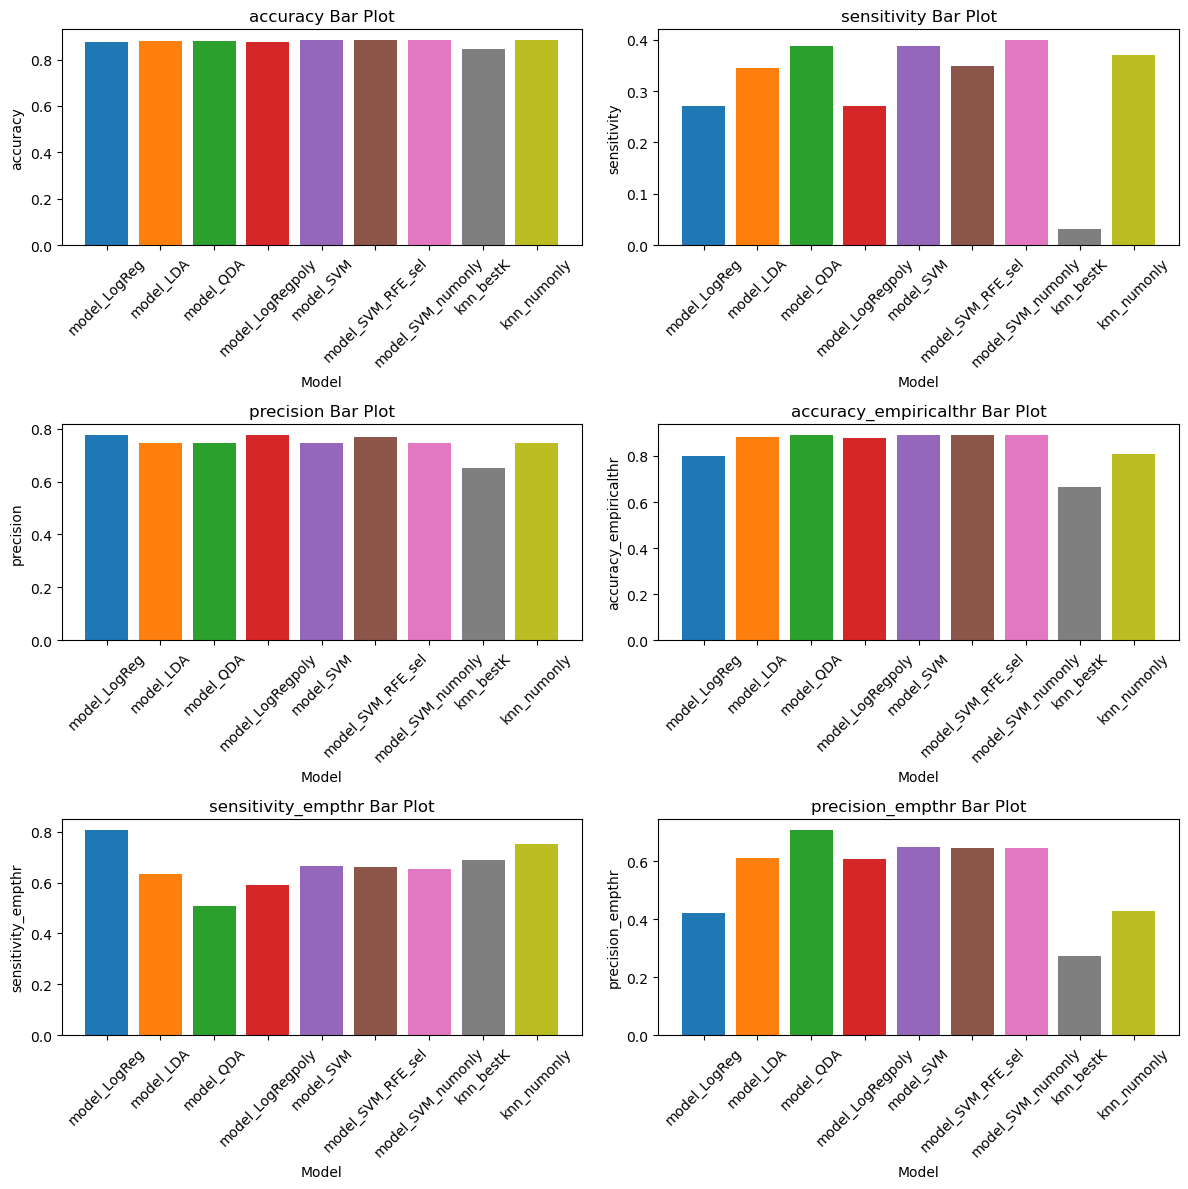

In [117]:
models = summary_df['model'].unique()
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for i, column in enumerate(summary_df.columns[1:]):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    colors = plt.cm.tab10(range(len(models)))
    for j, model in enumerate(models):
        model_data = summary_df[summary_df['model'] == model]
        ax.bar(model_data['model'], model_data[column], color=colors[j])

    ax.set_xlabel('Model')
    ax.set_ylabel(column)
    ax.set_title(column + ' Bar Plot')
    ax.set_xticklabels(summary_df['model'], rotation=45)

plt.tight_layout()
plt.show();

## ROC curves and AUC for the models

### ROC for Logistic Regression

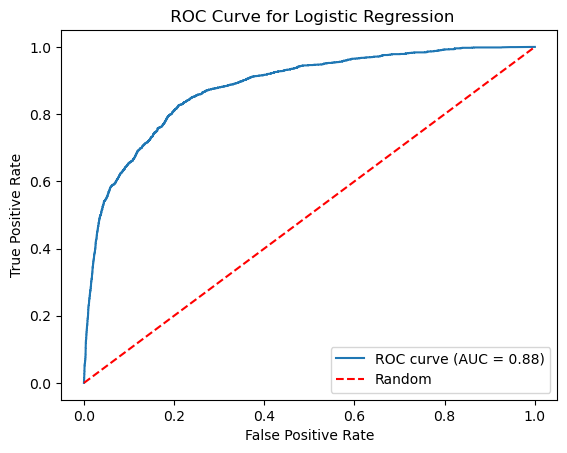

In [118]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
#model_LogReg.fit(X[best_features_LogReg], y)

y_prob = model_LogReg.predict_proba(X[best_features_LogReg])[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, y_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.plot(fpr, tpr, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(' ROC Curve for Logistic Regression')
plt.legend(loc='lower right')
plt.show();

### ROC for LDA

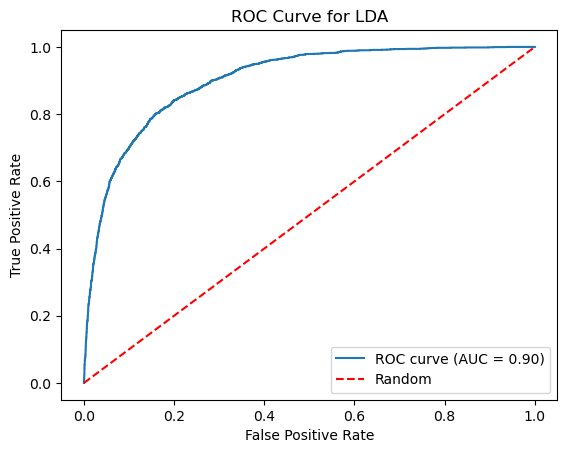

In [119]:
#model_LDA.fit(X[best_features_lda], y)
y_prob = model_LDA.predict_proba(X[best_features_lda])[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, y_prob)

# Compute AUC
roc_auc_score = auc(fpr, tpr)

# Plot ROC curve
plt.plot(fpr, tpr, label='ROC curve (AUC = {:.2f})'.format(roc_auc_score))
plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for LDA')
plt.legend(loc='lower right')
plt.show();

### ROC for QDA

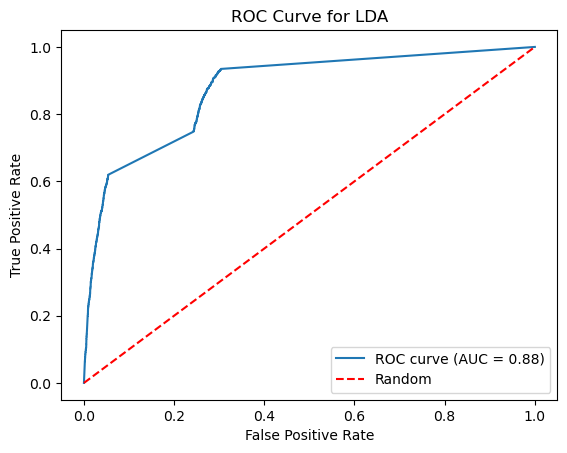

In [120]:
model_QDA.fit(X[best_features_qda], y)
y_prob = model_QDA.predict_proba(X[best_features_qda])[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, y_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.plot(fpr, tpr, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for LDA')
plt.legend(loc='lower right')
plt.show();

### ROC for quadratic logistic Regression

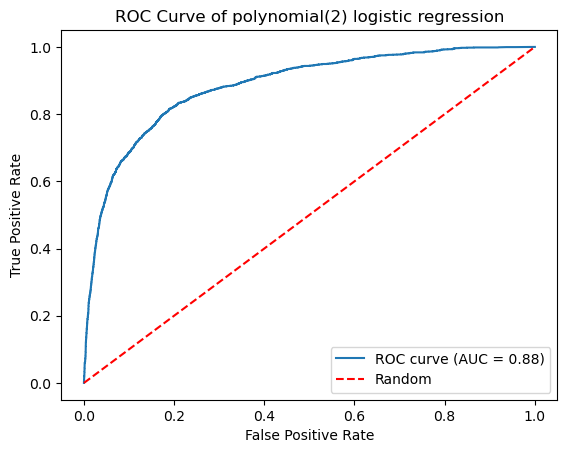

In [121]:
model_LogRegpoly.fit(X_poly, y)
y_prob = model_LogRegpoly.predict_proba(X_poly)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, y_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.plot(fpr, tpr, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve of polynomial(2) logistic regression')
plt.legend(loc='lower right')
plt.show();

### ROC for complete SVM 

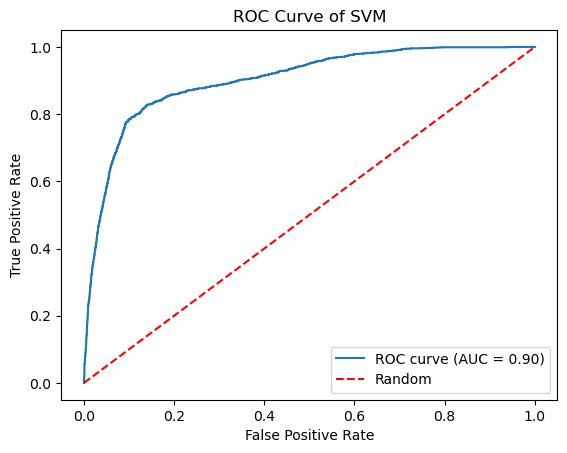

In [122]:
model_SVM.fit(X, y)
y_prob = model_SVM.predict_proba(X)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, y_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.plot(fpr, tpr, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve of SVM')
plt.legend(loc='lower right')
plt.show();

### ROC for reduced SVM

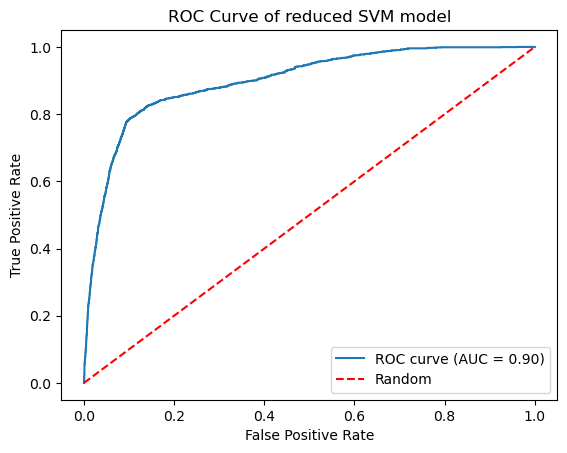

In [123]:
model_SVM.fit(X[signi_feat_rfe], y)
y_prob = model_SVM.predict_proba(X[signi_feat_rfe])[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, y_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.plot(fpr, tpr, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve of reduced SVM model')
plt.legend(loc='lower right')
plt.show();

### ROC for SVM only on numerical variables

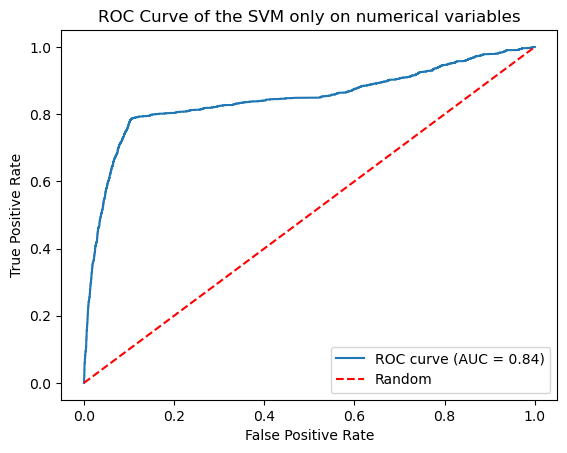

In [124]:
model_SVM.fit(X[X_numeric_columns], y)
y_prob = model_SVM.predict_proba(X[X_numeric_columns])[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, y_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.plot(fpr, tpr, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve of the SVM only on numerical variables')
plt.legend(loc='lower right')
plt.show();

### ROC for KNN

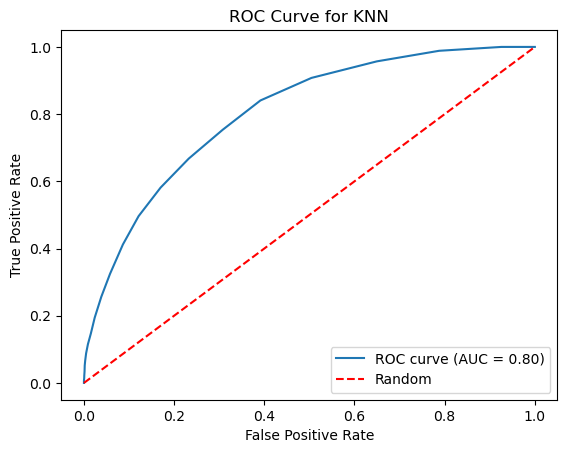

In [125]:
#knn_bestK.fit(X, y)
y_prob = knn_bestK.predict_proba(X)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, y_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.plot(fpr, tpr, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for KNN')
plt.legend(loc='lower right')
plt.show();

### ROC for KNN on numerical variables only

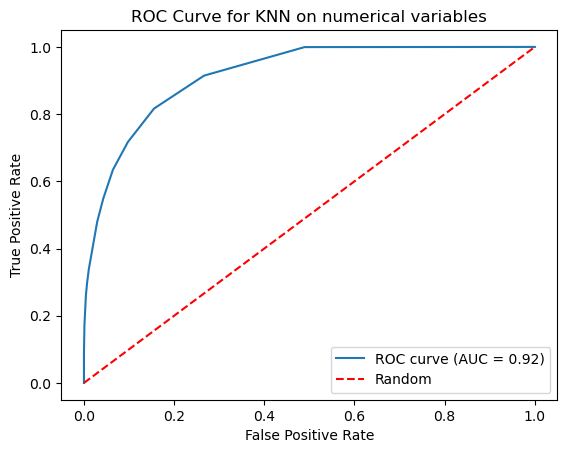

In [126]:
knn_bestK.fit(X[X_numeric_columns], y)
y_prob = knn_bestK.predict_proba(X[X_numeric_columns])[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, y_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.plot(fpr, tpr, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for KNN on numerical variables')
plt.legend(loc='lower right')
plt.show();

## Our conclusion
### the best model is: KNN with numerical variables only 
Is the one that maximizes the AUC 

<b> AUC for KNN numerical variables only = 0.92 <b> 

# Inspecting the usefulness of variable exitRates in the different models
Rebuild the models providing a train set without the variable exit rates and check the differences.

In [127]:
exit_drop = X.copy()
exit_drop = exit_drop.drop(["ExitRates"], axis = 1)

## Logistic Regression w\out ExitRates 
From the computation of the importance of the features based on the random permutations, we expect to see that removing ExitRates makes the model poorer
Still performing feature selection.

In [128]:
model_drop = LogisticRegression(solver = 'newton-cholesky', penalty = "l2")
kept = []
for i in range(1, len(X.columns) + 1):
    rfe = RFE(model_drop, n_features_to_select=i, verbose = False)
    rfe.fit(exit_drop, y)
    # Get a list with the fea
    kept_feat = exit_drop.columns[rfe.support_]
    kept.append(kept_feat)

RFE(estimator=LogisticRegression(solver='newton-cholesky'),
    n_features_to_select=1, verbose=False)

RFE(estimator=LogisticRegression(solver='newton-cholesky'),
    n_features_to_select=2, verbose=False)

RFE(estimator=LogisticRegression(solver='newton-cholesky'),
    n_features_to_select=3, verbose=False)

RFE(estimator=LogisticRegression(solver='newton-cholesky'),
    n_features_to_select=4, verbose=False)

RFE(estimator=LogisticRegression(solver='newton-cholesky'),
    n_features_to_select=5, verbose=False)

...

RFE(estimator=LogisticRegression(solver='newton-cholesky'),
    n_features_to_select=70, verbose=False)

RFE(estimator=LogisticRegression(solver='newton-cholesky'),
    n_features_to_select=71, verbose=False)

RFE(estimator=LogisticRegression(solver='newton-cholesky'),
    n_features_to_select=72, verbose=False)

RFE(estimator=LogisticRegression(solver='newton-cholesky'),
    n_features_to_select=73, verbose=False)

RFE(estimator=LogisticRegression(solver='newton-cholesky'),
    n_features_to_select=74, verbose=False)

In [129]:
acc= []
for j in range(len(kept)):
    model_drop = LogisticRegressionCV(cv=5, random_state=0, solver = 'newton-cholesky', penalty = "l2").fit(exit_drop[kept[j]], y)
    cv = KFold(n_splits=5, random_state=0, shuffle=True)
    scores = cross_val_score(model_drop,exit_drop[kept[j]], y,
                                 cv=cv, n_jobs=-1)
   
    media = mean(absolute(scores))
    acc.append(media)

max_index = acc.index(max(acc))
best_features_LogRegdrop = kept[max_index]

In [130]:
print("the best features for the Logistic Regression model are:\n {}\n".format(list(best_features_LogRegdrop)))
print("the best model accuracy, corresponding to the highest accuracy that we found, is:\n{}".format(acc[max_index]))

the best features for the Logistic Regression model are:
 ['Administrative', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'PageValues', 'SpecialDay', 'Month_Aug', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_Mar', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'Browser_3', 'Browser_6', 'Browser_12', 'Browser_13', 'Region_2', 'Region_5', 'Region_9', 'TrafficType_2', 'TrafficType_3', 'TrafficType_4', 'TrafficType_5', 'TrafficType_7', 'TrafficType_8', 'TrafficType_10', 'TrafficType_11', 'TrafficType_13', 'TrafficType_14', 'TrafficType_15', 'TrafficType_16', 'TrafficType_18', 'TrafficType_19', 'TrafficType_20', 'VisitorType_New_Visitor', 'VisitorType_Other', 'OperatingSystems_2', 'OperatingSystems_6', 'OperatingSystems_7']

the best model accuracy, corresponding to the highest accuracy that we found, is:
0.8849148418491485


### Performance of the model

In [131]:
accuracy_list_logisticdrop = []
sensitivity_list_logisticdrop = []
precision_list_logisticdrop = []
model_LogRegdrop = LogisticRegression(solver = 'newton-cholesky', penalty = "l2")
for i in range(30):
    
    cv = KFold(n_splits=5, random_state=i, shuffle=True)
    
    accuracy = cross_val_score(model_LogRegdrop,exit_drop[best_features_LogRegdrop], y, scoring='accuracy',
                             cv=cv, n_jobs=-1)
    
    sensitivity = cross_val_score(model_LogRegdrop,exit_drop[best_features_LogRegdrop], y, cv=cv, scoring='recall', n_jobs=-1)
    precision = cross_val_score(model_LogRegdrop,exit_drop[best_features_LogRegdrop], y, cv=cv, scoring = "precision", n_jobs=-1)
    
    
    mean_sensitivity = mean(absolute(sensitivity))
    sensitivity_list_logisticdrop.append(mean_sensitivity)
    mean_accuracy = mean(absolute(accuracy))
    accuracy_list_logisticdrop.append(mean_accuracy)
    mean_precision = mean(absolute(precision))
    precision_list_logisticdrop.append(mean_precision)
   
    
accuracy_logistic_drop = sum(accuracy_list_logisticdrop)/len(accuracy_list_logisticdrop)
sensitivity_logistic_drop = sum(sensitivity_list_logisticdrop)/len(sensitivity_list_logisticdrop)
precision_logistic_drop = sum(precision_list_logisticdrop)/len(precision_list_logisticdrop)


print("Logistic Regression with threshold = 0.5%. Indeces: ")
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}".format(accuracy_logistic_drop, sensitivity_logistic_drop, precision_logistic_drop))

Logistic Regression with threshold = 0.5%. Indeces: 
Accuracy: 0.8758745606920789
Sensitivity (recall): 0.28114770565171393
Precision: 0.7720768771900297


### Comparison
<b> The two models are quite similar but the ones without ExitRates uses way more variables in feature selection! from 9 to 44! <b>
    
We don't loose performance but we loose interpretability of the model!
    
This may be due to the fact that 
1. the Ridge penalization select ExitRates and exclude all the others
1. When we exlcude the ExitRates, we have to select many many other variables to compensate. 

## LDA w\out exitRates
In the LDA the exit rates feature was not very imporant (2nd least important). We don't expect to see grate differences.

In [132]:
#from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
model_LDAdrop = LDA(solver = "lsqr", shrinkage = "auto")
kept_LDAdrop = []
for i in range(1,len(X.columns) + 1):
    # Use RFE to select the top 10 features
    rfe_lda = RFE(model_LDAdrop, n_features_to_select=i)
    rfe_lda.fit(exit_drop, y)
    kept_feat = exit_drop.columns[rfe_lda.support_]
    kept_LDAdrop.append(kept_feat)

RFE(estimator=LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
    n_features_to_select=1)

RFE(estimator=LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
    n_features_to_select=2)

RFE(estimator=LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
    n_features_to_select=3)

RFE(estimator=LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
    n_features_to_select=4)

RFE(estimator=LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
    n_features_to_select=5)

...

RFE(estimator=LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
    n_features_to_select=70)

RFE(estimator=LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
    n_features_to_select=71)

RFE(estimator=LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
    n_features_to_select=72)

RFE(estimator=LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
    n_features_to_select=73)

RFE(estimator=LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
    n_features_to_select=74)

In [133]:
acc_lda= []
for j in range(len(kept_LDAdrop)):
    lda_drop = LDA(solver = "lsqr", shrinkage = "auto")
    cv = KFold(n_splits=5, random_state=0, shuffle=True)
    scores = cross_val_score(lda_drop, exit_drop[kept_LDAdrop[j]], y, cv=cv)
    media = np.mean(scores)
    acc_lda.append(media)
    
max_index = acc_lda.index(max(acc_lda))
best_features_lda_drop = kept_LDAdrop[max_index]

In [134]:
print("the best features for the LDA are:\n {}\n".format(list(best_features_lda_drop)))
print("the accuracy of the best LDA model is {}".format(max(acc_lda)))

the best features for the LDA are:
 ['Administrative', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'PageValues', 'SpecialDay', 'Month_Dec', 'Month_Feb', 'Month_Nov', 'Browser_3', 'Browser_12', 'TrafficType_2', 'TrafficType_5', 'TrafficType_7', 'TrafficType_8', 'TrafficType_10', 'TrafficType_11', 'TrafficType_13', 'TrafficType_16', 'TrafficType_19', 'TrafficType_20', 'VisitorType_New_Visitor', 'OperatingSystems_6', 'OperatingSystems_7']

the accuracy of the best LDA model is 0.8807785888077859


the number of features selected by the model without ExitRates is more or less similar to the number of features selected by the LDA model that has ExitRates included.

In [135]:
accuracy_list_LDA_drop = []
sensitivity_list_LDA = []
precision_list_LDA = []
model_LDA_drop = LDA(solver = "lsqr", shrinkage = "auto")
for i in range(30):
    cv = KFold(n_splits=5, random_state=i, shuffle=True)
    #use k-fold CV to evaluate model
    accuracy = cross_val_score(model_LDA_drop, exit_drop[best_features_lda_drop], y, scoring='accuracy',
                             cv=cv, n_jobs=-1)
    
    sensitivity = cross_val_score(model_LDA_drop,  exit_drop[best_features_lda_drop], y, cv=cv, scoring='recall', n_jobs=-1)
    precision = cross_val_score(model_LDA_drop,  exit_drop[best_features_lda_drop], y, cv=cv, scoring = "precision", n_jobs=-1)
    
    mean_sensitivity = mean(absolute(sensitivity))
    sensitivity_list_LDA.append(mean_sensitivity)
    mean_accuracy = mean(absolute(accuracy))
    accuracy_list_LDA_drop.append(mean_accuracy)
    mean_precision = mean(absolute(precision))
    precision_list_LDA.append(mean_precision)
    
accuracy_LDA_drop = sum(accuracy_list_LDA)/len(accuracy_list_LDA)
sensitivity_LDA_drop = sum(sensitivity_list_LDA)/len(sensitivity_list_LDA)
precision_LDA_drop = sum(precision_list_LDA)/len(precision_list_LDA)

print("LDA model with threshold = 0.5%. Indeces: ")
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}".format(accuracy_LDA_drop, sensitivity_LDA_drop, precision_LDA_drop))



LDA model with threshold = 0.5%. Indeces: 
Accuracy: 0.8803919978372534
Sensitivity (recall): 0.34606398825044515
Precision: 0.7414219900073366


### Comparison: 
<b> There is not significant difference between the model with and without exitrates! Not in term of performance neither in terms of accuracy <b>

## KNN (numerical only) w\out exitRates

In [136]:
num_columns = exit_drop.columns[0:9]
knn_noexit = KNeighborsClassifier()
#get the best number of neighbours with CV. set a max of 50, 
#if the best number of NN is = 50 we will eventually use an higher max
param_grid = {'n_neighbors': np.arange(1, 50)}
knn_bestK_noexit = GridSearchCV(knn_noexit, param_grid, cv=5)
#fit model to data
knn_bestK_noexit.fit(exit_drop[num_columns], y)
NN = knn_bestK_noexit.best_estimator_.n_neighbors
print("the best number of neighbours is {}".format(NN))

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])})

the best number of neighbours is 23


### Evaluate the performance of the KNN on the whole set

KNN polynomial model with 23 neighbours
accuracy: 0.8922952149229522
miscassification rate: 0.10770478507704784
sensitivity: 0.43238993710691825
specificity: 0.7710280373831776


<AxesSubplot:>

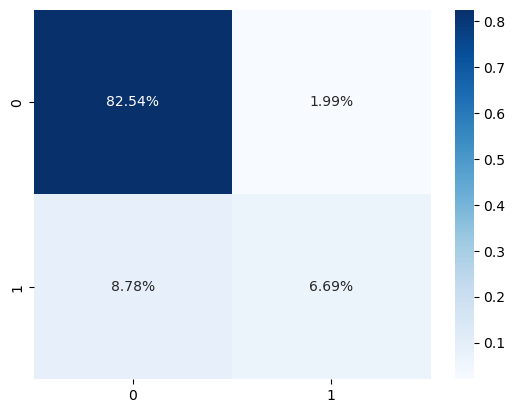

In [137]:
knn_pred = knn_bestK_noexit.predict(exit_drop[num_columns])
accuracy_knn = accuracy_score(y, knn_pred)
misclass_knn = 1 - accuracy_knn
sensitivity_knn = recall_score(y, knn_pred)
specificity_knn = precision_score(y, knn_pred)
print("KNN polynomial model with {} neighbours".format(NN))
print("accuracy: {}\nmiscassification rate: {}\nsensitivity: {}\nspecificity: {}".format(accuracy_knn, misclass_knn, sensitivity_knn, specificity_knn))

cf_matrix = confusion_matrix(y, knn_pred)
sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True, 
            fmt='.2%', cmap='Blues')

### CV the KNN numerical only w\out exit rates 
How worse\better is wrt to the KNN including exit rates? Compare the indeces from CV.

In [138]:
accuracy_list_KNN_numonly = []
sensitivity_list_KNN_numonly = []
precision_list_KNN_numonly = []
knn_numonly_drop = KNeighborsClassifier(n_neighbors=NN)
for i in range(1):
    
    cv = KFold(n_splits=5, random_state=i, shuffle=True)
    
    accuracy = cross_val_score(knn_numonly_drop,exit_drop[num_columns], y, scoring='accuracy',
                             cv=cv, n_jobs=-1)
    
    sensitivity = cross_val_score(knn_numonly,exit_drop[num_columns], y, cv=cv, scoring='recall', n_jobs=-1)
    precision = cross_val_score(knn_numonly,exit_drop[num_columns], y, cv=cv, scoring = "precision", n_jobs=-1)
    
    mean_sensitivity = mean(absolute(sensitivity))
    sensitivity_list_KNN_numonly.append(mean_sensitivity)
    mean_accuracy = mean(absolute(accuracy))
    accuracy_list_KNN_numonly.append(mean_accuracy)
    mean_precision = mean(absolute(precision))
    precision_list_KNN_numonly.append(mean_precision)
    
accuracy_KNN_numonly_drop = sum(accuracy_list_KNN_numonly)/len(accuracy_list_KNN_numonly)
sensitivity_KNN_numonly_drop = sum(sensitivity_list_KNN_numonly)/len(sensitivity_list_KNN_numonly)
precision_KNN_numonly_drop = sum(precision_list_KNN_numonly)/len(precision_list_KNN_numonly)

print("KNN with only numeric features Indeces: ")
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}".format(accuracy_KNN_numonly_drop, sensitivity_KNN_numonly_drop, precision_KNN_numonly_drop))

KNN with only numeric features Indeces: 
Accuracy: 0.8876723438767234
Sensitivity (recall): 0.39553113482091373
Precision: 0.7584854800917014


### Comparison: 
<b> There is not significant difference between the model with and without exitrates! Not in term of performance neither in terms of accuracy <b>

## SVM w\out exitRates

In [139]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
score = []
for kern in kernels:
    cv = KFold(n_splits=5, random_state=1, shuffle=True)
    model_SVM = svm.SVC(kernel=kern)
    scores = cross_val_score(model_SVM, exit_drop, y, scoring='accuracy', cv=cv, n_jobs=-1)
    score.append(np.mean(scores))
max_index = score.index(max(score))
best_kernel = kernels[max_index]
acc_best_model = max(score)

print("the best kernel is " + best_kernel + " and its accuracy is {}".format(acc_best_model))

the best kernel is linear and its accuracy is 0.8830494728304947


### CV the SVM w\out exit rates 
How worse\better is wrt to the SVM including exit rates? Compare the indeces from CV.

In [140]:
accuracy_list_SVM = []
sensitivity_list_SVM = []
precision_list_SVM = []
model_SVM = svm.SVC(kernel="linear")
for i in range(1):
    
    cv = KFold(n_splits=5, random_state=i, shuffle=True)
    
    accuracy = cross_val_score(model_SVM, exit_drop, y, scoring='accuracy',
                             cv=cv, n_jobs=-1)
    
    sensitivity = cross_val_score(model_SVM,  exit_drop, y, cv=cv, scoring='recall', n_jobs=-1)
    precision = cross_val_score(model_SVM,  exit_drop, y, cv=cv, scoring = "precision", n_jobs=-1)
    
    mean_sensitivity = mean(absolute(sensitivity))
    sensitivity_list_SVM.append(mean_sensitivity)
    mean_accuracy = mean(absolute(accuracy))
    accuracy_list_SVM.append(mean_accuracy)
    mean_precision = mean(absolute(precision))
    precision_list_SVM.append(mean_precision)
    
accuracy_SVM_drop = sum(accuracy_list_SVM)/len(accuracy_list_SVM)
sensitivity_SVM_drop = sum(sensitivity_list_SVM)/len(sensitivity_list_SVM)
precision_SVM_drop = sum(precision_list_SVM)/len(precision_list_SVM)

print("SVM model. Linear Kernel. All the features. Indeces: ")
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}".format(accuracy_SVM_drop, sensitivity_SVM_drop, precision_SVM_drop))

SVM model. Linear Kernel. All the features. Indeces: 
Accuracy: 0.8831305758313057
Sensitivity (recall): 0.34926596252740816
Precision: 0.7701576575088385


## SVM feature selected without exit rates
Using the linear kernel that we have already obtained

In [141]:
from sklearn.feature_selection import RFE
from sklearn.svm import SVC
svc_lin=SVC(kernel='linear')
svm_rfe_model=RFE(estimator=svc_lin)
svm_rfe_model_fit=svm_rfe_model.fit(exit_drop,y)
feat_index = pd.Series(data = svm_rfe_model_fit.ranking_, index = exit_drop.columns)
signi_feat_rfe = feat_index[feat_index==1].index
print('Significant features from RFE for the SVM model:\n {}'.format(signi_feat_rfe))


Significant features from RFE for the SVM model:
 Index(['Administrative', 'Administrative_Duration', 'Informational',
       'ProductRelated', 'ProductRelated_Duration', 'BounceRates',
       'PageValues', 'SpecialDay', 'Month_Dec', 'Month_Feb', 'Month_May',
       'Browser_1', 'Browser_2', 'Browser_3', 'Browser_4', 'Browser_5',
       'Browser_6', 'Browser_8', 'Browser_10', 'Browser_11', 'Browser_12',
       'Browser_13', 'TrafficType_5', 'TrafficType_6', 'TrafficType_13',
       'TrafficType_15', 'TrafficType_16', 'VisitorType_New_Visitor',
       'OperatingSystems_1', 'OperatingSystems_2', 'OperatingSystems_3',
       'OperatingSystems_4', 'OperatingSystems_5', 'OperatingSystems_6',
       'OperatingSystems_7', 'OperatingSystems_8'],
      dtype='object')


### CV the SVM feature selected w\out exit rates 
How worse\better is wrt to the SVM including exit rates? Compare the indeces from CV.

In [142]:
accuracy_listrfe_SVM = []
sensitivity_listrfe_SVM = []
precision_listrfe_SVM = []
#model_SVM = svm.SVC(kernel="linear")
model_SVM_RFE_sel_drop = svm.SVC(kernel="linear")
for i in range(1):
    
    cv = KFold(n_splits=5, random_state=i, shuffle=True)
    
    accuracy = cross_val_score(model_SVM_RFE_sel_drop,exit_drop[signi_feat_rfe], y, scoring='accuracy',
                             cv=cv, n_jobs=-1)
    
    sensitivity = cross_val_score(model_SVM_RFE_sel_drop, exit_drop[signi_feat_rfe], y, cv=cv, scoring='recall', n_jobs=-1)
    precision = cross_val_score(model_SVM_RFE_sel_drop, exit_drop[signi_feat_rfe], y, cv=cv, scoring = "precision", n_jobs=-1)
    
    mean_sensitivity = mean(absolute(sensitivity))
    sensitivity_listrfe_SVM.append(mean_sensitivity)
    mean_accuracy = mean(absolute(accuracy))
    accuracy_listrfe_SVM.append(mean_accuracy)
    mean_precision = mean(absolute(precision))
    precision_listrfe_SVM.append(mean_precision)
    
accuracy_SVMrfe_drop = sum(accuracy_listrfe_SVM)/len(accuracy_listrfe_SVM)
sensitivity_SVMrfe_drop = sum(sensitivity_listrfe_SVM)/len(sensitivity_listrfe_SVM)
precision_SVMrfe_drop = sum(precision_listrfe_SVM)/len(precision_listrfe_SVM)

print("SVM model. Linear Kernel. Only selected features by RFE algorithm. Indeces: ")
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}".format(accuracy_SVMrfe_drop, sensitivity_SVMrfe_drop, precision_SVMrfe_drop))

SVM model. Linear Kernel. Only selected features by RFE algorithm. Indeces: 
Accuracy: 0.8831305758313057
Sensitivity (recall): 0.3503383485863894
Precision: 0.7687637893764683


## SVM numerical only without exit rates
Find the best kernel when using only numerical variables

In [143]:
from sklearn import svm
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
score = []
for kern in kernels:
    cv = KFold(n_splits=5, random_state=1, shuffle=True)
    model_SVM = svm.SVC(kernel=kern)
    scores = cross_val_score(model_SVM, exit_drop[num_columns], y, scoring='accuracy', cv=cv, n_jobs=-1)
    score.append(np.mean(scores))
max_index = score.index(max(score))
best_kernel_drop = kernels[max_index]
acc_best_model = max(score)
print("the best kernel is " + best_kernel_drop + " and its accuracy is {}".format(acc_best_model))

the best kernel is rbf and its accuracy is 0.8907542579075425


### CV the SVM numerical only w\out exit rates 
How worse\better is wrt to the SVM including exit rates? Compare the indeces from CV.

In [144]:
accuracy_list_numonly_SVM = []
sensitivity_list_numonly_SVM = []
precision_list_numonly_SVM = []
#model_SVM = svm.SVC(kernel="linear")
model_SVM_numonly_drop = svm.SVC(kernel="rbf")
for i in range(1):
    
    cv = KFold(n_splits=5, random_state=i, shuffle=True)
    
    accuracy = cross_val_score(model_SVM_numonly_drop, exit_drop[num_columns], y, scoring='accuracy',
                             cv=cv, n_jobs=-1)
    
    sensitivity = cross_val_score(model_SVM_numonly_drop, exit_drop[num_columns], y, cv=cv, scoring='recall', n_jobs=-1)
    precision = cross_val_score(model_SVM_numonly_drop, exit_drop[num_columns], y, cv=cv, scoring = "precision", n_jobs=-1)
    
    mean_sensitivity = mean(absolute(sensitivity))
    sensitivity_list_numonly_SVM.append(mean_sensitivity)
    mean_accuracy = mean(absolute(accuracy))
    accuracy_list_numonly_SVM.append(mean_accuracy)
    mean_precision = mean(absolute(precision))
    precision_list_numonly_SVM.append(mean_precision)
    
accuracy_SVM_numonly_drop = sum(accuracy_list_numonly_SVM)/len(accuracy_list_numonly_SVM)
sensitivity_SVM_numonly_drop = sum(sensitivity_list_numonly_SVM)/len(sensitivity_list_numonly_SVM)
precision_SVM_numonly_drop = sum(precision_list_numonly_SVM)/len(precision_list_numonly_SVM)

print("SVM model. rbf Kernel")
print("Accuracy: {}\nSensitivity (recall): {}\nPrecision: {}".format(accuracy_SVM_numonly_drop, sensitivity_SVM_numonly_drop, precision_SVM_numonly_drop))

SVM model. rbf Kernel
Accuracy: 0.8909975669099757
Sensitivity (recall): 0.43392016814814094
Precision: 0.7583625434136757


### Comparison: 
<b> There is no significant difference between the SVM using and not using exit rates! The performance is very similar in the two cases. 

<div align="center">

# Politecnico of Milan  
## MSc. in Bioinformatics and Computational Genomics  
### Machine Learning  
#### A.Y. 2022-23  

### Clustering: Prediction of the revenue with clustering based algorithms

**Students:** Francesco Pelizzari, Simone Corbetta  
**ID:** 10942582, 10951358  
**Emails:** francesco.pelizzari1@studenti.unimi.it simone.corbetta1@studenti.unimi.it  

</div>

### CLUSTERING: index
1. Loading the data, preprocess (standardization) of the numerical variables
1. Data visualization with PCA and UMAP
1. Definition of a few helper functions for the clustering evaluation (precision, recall)
1. K-means
    1. applied to the whole dataset (also categorical variables)
    1. applied only to the numerical dataset 
    1. applied after performing dimensionality reduction with PCA on the whole dataset
    1. applied after performing dimensionality reduction with PCA on the numerical dataset
1. K-medoids 
1. Hierachical clustering
    1. with the whole dataset (also categorical variables)
    1. with only the numerical dataset 
    1. applied after performing dimensionality reduction with PCA on the whole dataset
    1. applied after performing dimensionality reduction with PCA on the numerical  dataset
1. comparison of the different procedures 
    1. accuracy 
    1. Jaccard Index 
1. comparison between canonical classfication and clustering based classification (ROC

## Data preprocessing: 
Load the dataset. 
Divide the target variable: y ("revenue") from the predictors that we will use for the clustering: X.
Build a dataframe with only numerical variables. 
Standardize it using a standard scaler from sklearn. 
Re-Build a complete dataframe with the normalized numerical columns and all the other columns from the original dataframe.

In [145]:
data = complete_df.copy()

In [146]:
y = data["Revenue"]

In [147]:
columns_to_convert = ["Month","Browser","Region","TrafficType","VisitorType","OperatingSystems"]
data_target = pd.get_dummies(data, columns=columns_to_convert)
data_target["Revenue"] = data_target["Revenue"].astype(int)
data_target["Weekend"] = data_target["Weekend"].astype(int)
X = data_target.drop(["Revenue"], axis = 1)

In [148]:
X_numerical = data[X.columns[0:10]]
X_numerical.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000


In [149]:
from sklearn.preprocessing import StandardScaler
x = X.loc[:, X.columns].values
x = StandardScaler().fit_transform(x)
X_numerical = X_numerical.loc[:, X_numerical.columns].values
X_numerical = StandardScaler().fit_transform(X_numerical)
X_numerical = pd.DataFrame(X_numerical, columns = X.columns[0:10])
X_numerical.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
count,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04
mean,-1.375191e-15,2.072011e-15,6.987391e-15,1.761455e-16,-2.849753e-16,9.953199e-16,1.333348e-15,-2.622666e-16,-4.954530e-15,-1.722823e-14
std,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00
min,-6.969930e-01,-4.571914e-01,-3.964779e-01,-2.449305e-01,-7.134884e-01,-6.243475e-01,-4.576830e-01,-8.863706e-01,-3.171778e-01,-3.088214e-01
25%,-6.969930e-01,-4.571914e-01,-3.964779e-01,-2.449305e-01,-5.560920e-01,-5.281214e-01,-4.576830e-01,-5.923930e-01,-3.171778e-01,-3.088214e-01
50%,-3.959377e-01,-4.147639e-01,-3.964779e-01,-2.449305e-01,-3.087548e-01,-3.113566e-01,-3.934903e-01,-3.686913e-01,-3.171778e-01,-3.088214e-01
75%,5.072280e-01,7.035981e-02,-3.964779e-01,-2.449305e-01,1.409492e-01,1.407881e-01,-1.109348e-01,1.425510e-01,-3.171778e-01,-3.088214e-01
max,7.431499e+00,1.876956e+01,1.849960e+01,1.786868e+01,1.513858e+01,3.280678e+01,3.667189e+00,3.229316e+00,1.916634e+01,4.718598e+00


In [150]:
normalized_x = pd.concat([X_numerical, X[X.columns[10:]]], axis = 1)
normalized_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 74 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  float64
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  float64
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  float64
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  Weekend                        12330 non-null  int32  
 11  Month_Aug                      12330 non-null  uint8  
 12  Month_Dec                      12330 non-null 

## Dimensionality reduction with PCA
### performing PCA on the whole dataset 
Plot the total variance exaplained by each PC.
Transform the feature space according to the results of the PCA.

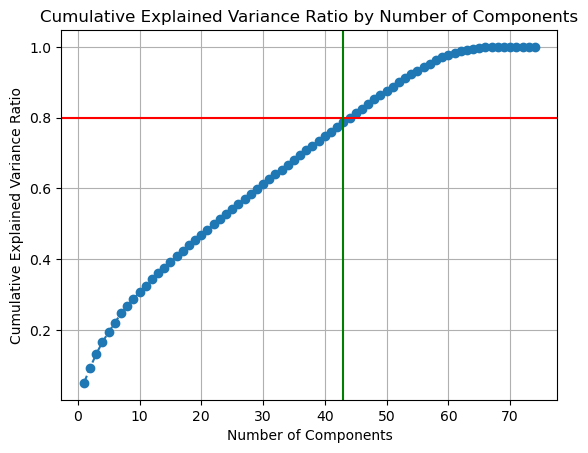

In [151]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(x)

plt.plot(range(1,75),pca.explained_variance_ratio_.cumsum(),marker="o",linestyle="--")
plt.axhline(y=0.8, color="red", linestyle="-", linewidth=1.5)
plt.axvline(x=43, color="green", linestyle="-", linewidth=1.5)
plt.xlabel("Number of Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("Cumulative Explained Variance Ratio by Number of Components")
plt.grid(True)
plt.show()
ncomp = 43 
pca_x = PCA(n_components= ncomp)
pca_x.fit(x)
new_space = pca_x.transform(x);

### performing PCA on numerical data only
Plot the total variance exaplained by each PC.
Transform the feature space according to the results of the PCA.

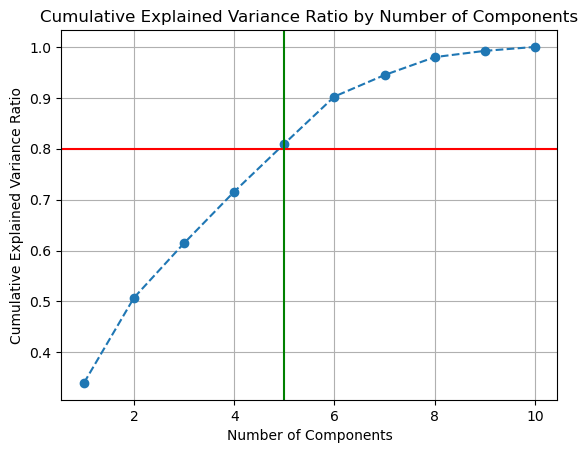

In [152]:
pca_num = PCA()
pca_num.fit(X_numerical)
plt.plot(range(1,11),pca_num.explained_variance_ratio_.cumsum(),marker="o",linestyle="--")
plt.axhline(y=0.8, color="red", linestyle="-", linewidth=1.5)
plt.axvline(x=5, color="green", linestyle="-", linewidth=1.5)
plt.xlabel("Number of Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("Cumulative Explained Variance Ratio by Number of Components")
plt.grid(True)
plt.show()
ncomp = 5
pca_num = PCA(n_components= ncomp)
pca_num.fit(X_numerical)
new_space_num = pca_num.transform(X_numerical);

## Visual inspection of data through PC and UMAP (2PC):  
1. PCA on the whole dataset 
1. PCA on the numerical columns only
1. UMAP on the whole dataset 
1. UMAP on the numerical columns only

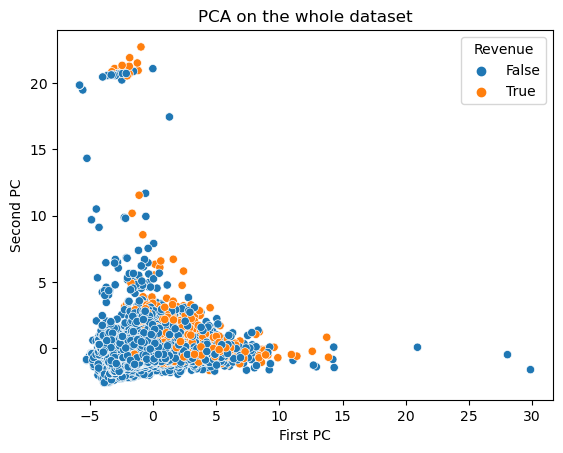

In [153]:
selected_columns = new_space[:, :2]
df_sel = pd.DataFrame(selected_columns, columns=["First PC", "Second PC"])
df_sel["Revenue"] = y
sns.scatterplot(data=df_sel,x="First PC",y="Second PC",hue="Revenue")
plt.title("PCA on the whole dataset");

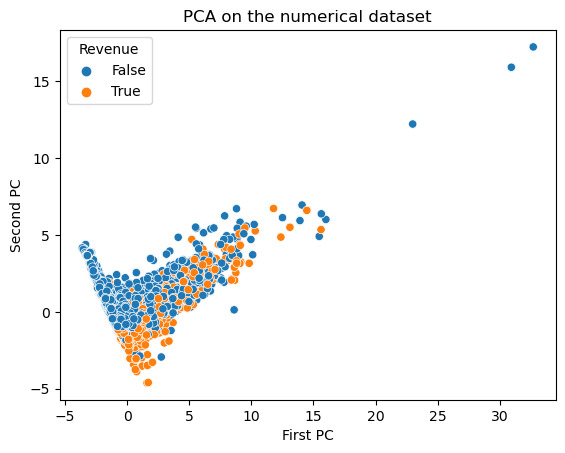

In [154]:
selected_columns = new_space_num[:, :2]
df_sel = pd.DataFrame(selected_columns, columns=["First PC", "Second PC"])
df_sel["Revenue"] = y
sns.scatterplot(data=df_sel,x="First PC",y="Second PC",hue="Revenue")
plt.title("PCA on the numerical dataset");

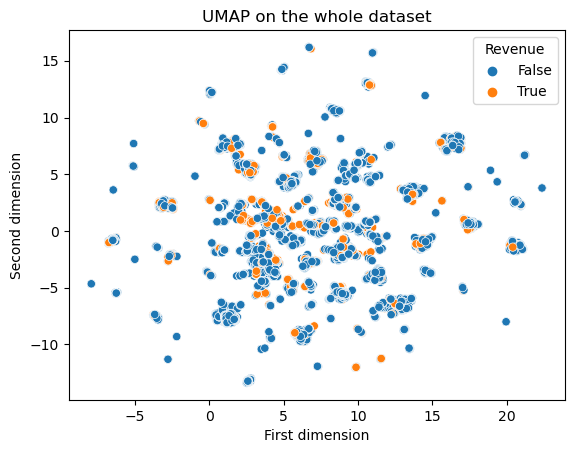

In [155]:
import warnings
warnings.filterwarnings("ignore")
import umap
reducer = umap.UMAP()
embedding = reducer.fit_transform(x)
embedding= pd.DataFrame(embedding, columns=["First dimension", "Second dimension"])
embedding["Revenue"] = y
sns.scatterplot(data=embedding,x="First dimension",y="Second dimension",hue="Revenue")
plt.title("UMAP on the whole dataset");

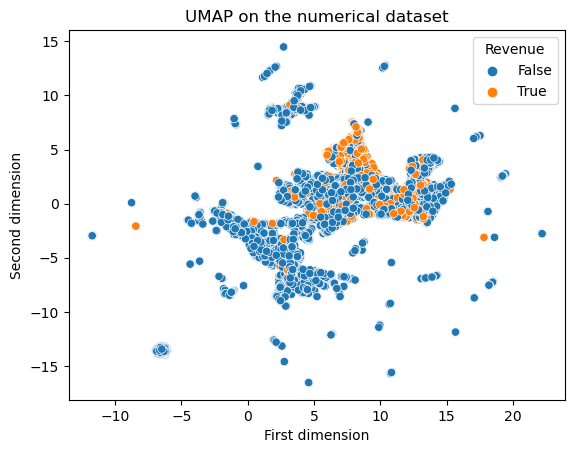

In [156]:
embedding_num = reducer.fit_transform(X_numerical)
embedding_num = pd.DataFrame(embedding_num, columns=["First dimension", "Second dimension"])
embedding_num["Revenue"] = y
sns.scatterplot(data=embedding_num,x="First dimension",y="Second dimension",hue="Revenue")
plt.title("UMAP on the numerical dataset");

## Definition of helper functions
Define two helper functions that given the outcome of a clustering procedures (the clustering labels) and a set of labels, returns: 
1. the recall of the clusters wrt to the label
1. the recall of the clusters wrt to the label

In [157]:
def compute_recall(cluster_labels, true_labels, cluster_index, class_label):
    cluster_indices = np.where(cluster_labels == cluster_index)[0]  # Indices of samples in the cluster
    class_indices = np.where(true_labels == class_label)[0]  # Indices of samples in the class
    nkj = len(np.intersect1d(cluster_indices, class_indices))  # Number of samples in the cluster and class
    nj = len(class_indices)  # Total number of samples in the class
    recall = nkj / nj
    return recall

In [158]:
def compute_precision(cluster_labels, true_labels, cluster_index, class_label):
    cluster_indices = np.where(cluster_labels == cluster_index)[0]  # Indices of samples in the cluster
    class_indices = np.where(true_labels == class_label)[0]  # Indices of samples in the class
    nkj = len(np.intersect1d(cluster_indices, class_indices))  # Number of samples in the cluster and class
    nk= len(cluster_indices)  # Total number of samples in the class
    precision = nkj / nk
    return precision

## K-Means
### K-Means on the whole dataset and evaluation

In [159]:
from sklearn.cluster import KMeans
kmeans_complete = KMeans(2,init='k-means++',random_state=42, n_init = "auto")
kmeans_complete.fit(x)
pred_labels_compl = kmeans_complete.labels_
unique_kmeans_compl, frequency_kmeans_compl = np.unique(pred_labels_compl,
                              return_counts = True)
freq_series_kmeans_compl = pd.Series(frequency_kmeans_compl, index = unique_kmeans_compl)
freq_series_kmeans_compl

KMeans(n_clusters=2, n_init='auto', random_state=42)

0      853
1    11477
dtype: int64

In [160]:
acc_KMeans_compl = sum(pred_labels_compl== y)/len(y)
recall_0_0 = compute_recall(pred_labels_compl, y , 0, 0)
recall_0_1 = compute_recall(pred_labels_compl, y , 0, 1)
recall_1_1 = compute_recall(pred_labels_compl, y , 1, 1)
recall_1_0 = compute_recall(pred_labels_compl, y , 1, 0)
precision_0_0 = compute_precision(pred_labels_compl, y , 0, 0)
precision_0_1 = compute_precision(pred_labels_compl, y, 0, 1)
precision_1_1 = compute_precision(pred_labels_compl, y , 1, 1)
precision_1_0 = compute_precision(pred_labels_compl, y , 1, 0)
jaccard_kmeans_comp = sklearn.metrics.jaccard_score(y,pred_labels_compl)
print(f'Numerosity of cluster 0 is: {sum(pred_labels_compl==0)}, numerosity of cluster 1 is: {sum(pred_labels_compl==1)}')
print(f'accuracy of kmeans on the original dataset is {acc_KMeans_compl}')
print(f'for cluster 0 : recall for class 0 = {recall_0_0}, recall for class 1 = {recall_0_1}')
print(f'for cluster 1 : recall for class 0 = {recall_1_0}, recall for class 1 = {recall_1_1}')
print(f'for cluster 0 : precision for class 0 =  {precision_0_0}, precision for class 1 : {precision_0_1}')
print(f'for cluster 1 : precision for class 0 =  {precision_1_0}, precision for class 1 : {precision_1_1}')
print(f'purity of cluster 0 = {max(precision_0_0,precision_0_1)}, purity of cluster 1 = {max(precision_1_1,precision_1_0)}')
print(f'Jaccard index = {jaccard_kmeans_comp}')

Numerosity of cluster 0 is: 853, numerosity of cluster 1 is: 11477
accuracy of kmeans on the original dataset is 0.19748580697485807
for cluster 0 : recall for class 0 = 0.06620610247553253, recall for class 1 = 0.08542976939203355
for cluster 1 : recall for class 0 = 0.9337938975244675, recall for class 1 = 0.9145702306079665
for cluster 0 : precision for class 0 =  0.8089097303634232, precision for class 1 : 0.1910902696365768
for cluster 1 : precision for class 0 =  0.8479567831314804, precision for class 1 : 0.15204321686851965
purity of cluster 0 = 0.8089097303634232, purity of cluster 1 = 0.8479567831314804
Jaccard index = 0.14991408934707903


### K-Means only on numerical features and evaluation

In [161]:
kmeans_NUM = KMeans(2,init='k-means++',random_state=42, n_init = "auto")
kmeans_NUM.fit(X_numerical)
pred_labels_NUM = kmeans_NUM.labels_
unique_kmeans_numonly, frequency_kmeans_numonly = np.unique(pred_labels_NUM,
                              return_counts = True)
freq_series_kmeans_numonly = pd.Series(frequency_kmeans_numonly, index = unique_kmeans_numonly)

KMeans(n_clusters=2, n_init='auto', random_state=42)

In [162]:
acc_KMeans_NUM = sum(pred_labels_NUM== y)/len(y)
recall_0_0 = compute_recall(pred_labels_NUM, y , 0, 0)
recall_0_1 = compute_recall(pred_labels_NUM, y , 0, 1)
recall_1_1 = compute_recall(pred_labels_NUM, y , 1, 1)
recall_1_0 = compute_recall(pred_labels_NUM, y , 1, 0)
precision_0_0 = compute_precision(pred_labels_NUM, y , 0, 0)
precision_0_1 = compute_precision(pred_labels_NUM, y,0,1)
precision_1_1 = compute_precision(pred_labels_NUM, y , 1, 1)
precision_1_0 = compute_precision(pred_labels_NUM, y , 1, 0)
jaccard_kmeans_NUM = sklearn.metrics.jaccard_score(y,pred_labels_NUM)
print(f'Numerosity of cluster 0 is: {sum(pred_labels_NUM==0)}, numerosity of cluster 1 is: {sum(pred_labels_NUM==1)}')
print(f'accuracy of kmeans on the original dataset is {acc_KMeans_NUM}')
print(f'for cluster 0 : recall for class 0 = {recall_0_0}, recall for class 1 = {recall_0_1}')
print(f'for cluster 1 : recall for class 0 = {recall_1_0}, recall for class 1 = {recall_1_1}')
print(f'for cluster 0 : precision for class 0 =  {precision_0_0}, precision for class 1 : {precision_0_1}')
print(f'for cluster 1 : precision for class 0 =  {precision_1_0}, precision for class 1 : {precision_1_1}')
print(f'purity of cluster 0 = {max(precision_0_0,precision_0_1)}, purity of cluster 1 = {max(precision_1_1,precision_1_0)}')
print(f'Jaccard index = {jaccard_kmeans_NUM}')

Numerosity of cluster 0 is: 11275, numerosity of cluster 1 is: 1055
accuracy of kmeans on the original dataset is 0.7692619626926196
for cluster 0 : recall for class 0 = 0.9044329303396661, recall for class 1 = 0.9690775681341719
for cluster 1 : recall for class 0 = 0.0955670696603339, recall for class 1 = 0.030922431865828093
for cluster 0 : precision for class 0 =  0.8360088691796009, precision for class 1 : 0.16399113082039912
for cluster 1 : precision for class 0 =  0.9440758293838862, precision for class 1 : 0.055924170616113746
purity of cluster 0 = 0.8360088691796009, purity of cluster 1 = 0.9440758293838862
Jaccard index = 0.0203168044077135


### K-Means in the reduced feature space (PCA) and evaluation

In [163]:
kmeans_pca_red = KMeans(2,init='k-means++',random_state=42, n_init = "auto")
kmeans_pca_red= kmeans_pca_red.fit(new_space)
pred_labels_red = kmeans_pca_red.labels_
unique_kmeans_pca, frequency_kmeans_pca = np.unique(pred_labels_red,
                              return_counts = True)
freq_series_kmeans_pca = pd.Series(frequency_kmeans_pca, index = unique_kmeans_pca)
freq_series_kmeans_pca

0      328
1    12002
dtype: int64

In [164]:
acc_KMeans_red = sum(pred_labels_red== y)/len(y)
recall_0_0 = compute_recall(pred_labels_red, y , 0, 0)
recall_0_1 = compute_recall(pred_labels_red, y , 0, 1)
recall_1_1 = compute_recall(pred_labels_red, y , 1, 1)
recall_1_0 = compute_recall(pred_labels_red, y , 1, 0)
precision_0_0 = compute_precision(pred_labels_red, y , 0, 0)
precision_0_1 = compute_precision(pred_labels_red, y,0,1)
precision_1_1 = compute_precision(pred_labels_red, y , 1, 1)
precision_1_0 = compute_precision(pred_labels_red, y , 1, 0)
jaccard_kmeans_red = sklearn.metrics.jaccard_score(y,pred_labels_red)
print(f'Numerosity of cluster 0 is: {sum(pred_labels_red==0)}, numerosity of cluster 1 is: {sum(pred_labels_red==1)}')
print(f'accuracy of kmeans on the original dataset is {acc_KMeans_red}')
print(f'for cluster 0 : recall for class 0 = {recall_0_0}, recall for class 1 = {recall_0_1}')
print(f'for cluster 1 : recall for class 0 = {recall_1_0}, recall for class 1 = {recall_1_1}')
print(f'for cluster 0 : precision for class 0 =  {precision_0_0}, precision for class 1 : {precision_0_1}')
print(f'for cluster 1 : precision for class 0 =  {precision_1_0}, precision for class 1 : {precision_1_1}')
print(f'purity of cluster 0 = {max(precision_0_0,precision_0_1)}, purity of cluster 1 = {max(precision_1_1,precision_1_0)}')
print(f'Jaccard index = {jaccard_kmeans_red}')

Numerosity of cluster 0 is: 328, numerosity of cluster 1 is: 12002
accuracy of kmeans on the original dataset is 0.17274939172749393
for cluster 0 : recall for class 0 = 0.026386490117060065, recall for class 1 = 0.027777777777777776
for cluster 1 : recall for class 0 = 0.9736135098829399, recall for class 1 = 0.9722222222222222
for cluster 0 : precision for class 0 =  0.8384146341463414, precision for class 1 : 0.16158536585365854
for cluster 1 : precision for class 0 =  0.8454424262622896, precision for class 1 : 0.15455757373771037
purity of cluster 0 = 0.8384146341463414, purity of cluster 1 = 0.8454424262622896
Jaccard index = 0.15387805889672335


### K-Means in the reduced feature space (PCA on numerical data only) and evaluation

In [165]:
kmeans_pca_red_num = KMeans(2,init='k-means++',random_state=42, n_init = "auto")
kmeans_pca_red_num.fit(new_space_num)
pred_labels_red_num = kmeans_pca_red_num.labels_
unique_kmeans_pca_num, frequency_kmeans_pca_num = np.unique(pred_labels_red_num,
                              return_counts = True)
freq_series_kmeans_pca_num = pd.Series(frequency_kmeans_pca_num, index = unique_kmeans_pca_num)
freq_series_kmeans_pca_num

KMeans(n_clusters=2, n_init='auto', random_state=42)

0    10497
1     1833
dtype: int64

In [166]:
acc_KMeans_red_num = sum(pred_labels_red_num== y)/len(y)
recall_0_0 = compute_recall(pred_labels_red_num, y , 0, 0)
recall_0_1 = compute_recall(pred_labels_red_num, y , 0, 1)
recall_1_1 = compute_recall(pred_labels_red_num, y , 1, 1)
recall_1_0 = compute_recall(pred_labels_red_num, y , 1, 0)
precision_0_0 = compute_precision(pred_labels_red_num, y , 0, 0)
precision_0_1 = compute_precision(pred_labels_red_num, y,0,1)
precision_1_1 = compute_precision(pred_labels_red_num, y , 1, 1)
precision_1_0 = compute_precision(pred_labels_red_num, y , 1, 0)
jaccard_kmeans_red_num = sklearn.metrics.jaccard_score(y,pred_labels_red_num)
print(f'Numerosity of cluster 0 is: {sum(pred_labels_red_num==0)}, numerosity of cluster 1 is: {sum(pred_labels_red_num==1)}')
print(f'accuracy of kmeans on the original dataset is {acc_KMeans_red_num}')
print(f'for cluster 0 : recall for class 0 = {recall_0_0}, recall for class 1 = {recall_0_1}')
print(f'for cluster 1 : recall for class 0 = {recall_1_0}, recall for class 1 = {recall_1_1}')
print(f'for cluster 0 : precision for class 0 =  {precision_0_0}, precision for class 1 : {precision_0_1}')
print(f'for cluster 1 : precision for class 0 =  {precision_1_0}, precision for class 1 : {precision_1_1}')
print(f'purity of cluster 0 = {max(precision_0_0,precision_0_1)}, purity of cluster 1 = {max(precision_1_1,precision_1_0)}')
print(f'Jaccard index = {jaccard_kmeans_red_num}')

Numerosity of cluster 0 is: 10497, numerosity of cluster 1 is: 1833
accuracy of kmeans on the original dataset is 0.7794809407948095
for cluster 0 : recall for class 0 = 0.8731529456918058, recall for class 1 = 0.7321802935010482
for cluster 1 : recall for class 0 = 0.1268470543081942, recall for class 1 = 0.26781970649895176
for cluster 0 : precision for class 0 =  0.8669143564828046, precision for class 1 : 0.1330856435171954
for cluster 1 : precision for class 0 =  0.7212220403709766, precision for class 1 : 0.27877795962902346
purity of cluster 0 = 0.8669143564828046, purity of cluster 1 = 0.7212220403709766
Jaccard index = 0.15820433436532508


## K-Medoids
Using Gower distance as we have mixed data-types.

In [167]:
import gower
from sklearn.neighbors import DistanceMetric
from sklearn.preprocessing import LabelEncoder
from sklearn_extra.cluster import KMedoids

In [168]:
categorical_cols = data.columns[10:17]
for col in categorical_cols:
    data[col] = data[col].astype('category')
data = data.drop(["Revenue"], axis = 1)
gower_mat = gower.gower_matrix(data, cat_features = [False,False,False,False,False,False,False,False,False,False,
                                         True, True,True,True,True,True,True])

In [169]:
kmedoids = KMedoids(n_clusters=2, random_state=42, metric='precomputed')
kmedoids.fit(gower_mat)

kmed_labels = kmedoids.labels_

unique_kmedoids, frequency_kmedoids = np.unique(kmed_labels,
                              return_counts = True)
freq_series_kmedoids = pd.Series(frequency_kmedoids, index = unique_kmedoids)
freq_series_kmedoids

KMedoids(metric='precomputed', n_clusters=2, random_state=42)

0    6025
1    6305
dtype: int64

In [170]:
acc_KMedoids = sum(kmed_labels== y)/len(y)
recall_0_0 = compute_recall(kmed_labels, y , 0, 0)
recall_0_1 = compute_recall(kmed_labels, y , 0, 1)
recall_1_1 = compute_recall(kmed_labels, y , 1, 1)
recall_1_0 = compute_recall(kmed_labels, y , 1, 0)
precision_0_0 = compute_precision(kmed_labels, y , 0, 0)
precision_0_1 = compute_precision(kmed_labels, y,0,1)
precision_1_1 = compute_precision(kmed_labels, y , 1, 1)
precision_1_0 = compute_precision(kmed_labels, y , 1, 0)
jaccard_medoids = sklearn.metrics.jaccard_score(y,kmed_labels)
print(f'Numerosity of cluster 0 is: {sum(kmed_labels==0)}, numerosity of cluster 1 is: {sum(kmed_labels==1)}')
print(f'accuracy of KMedoids on the original dataset is {acc_KMedoids}')
print(f'for cluster 0 : recall for class 0 = {recall_0_0}, recall for class 1 = {recall_0_1}')
print(f'for cluster 1 : recall for class 0 = {recall_1_0}, recall for class 1 = {recall_1_1}')
print(f'for cluster 0 : precision for class 0 =  {precision_0_0}, precision for class 1 : {precision_0_1}')
print(f'for cluster 1 : precision for class 0 =  {precision_1_0}, precision for class 1 : {precision_1_1}')
print(f'purity of cluster 0 = {max(precision_0_0,precision_0_1)}, purity of cluster 1 = {max(precision_1_1,precision_1_0)}')
print(f'Jaccard index = {jaccard_medoids}')

Numerosity of cluster 0 is: 6025, numerosity of cluster 1 is: 6305
accuracy of KMedoids on the original dataset is 0.5611516626115166
for cluster 0 : recall for class 0 = 0.5294569180579544, recall for class 1 = 0.26572327044025157
for cluster 1 : recall for class 0 = 0.4705430819420457, recall for class 1 = 0.7342767295597484
for cluster 0 : precision for class 0 =  0.9158506224066391, precision for class 1 : 0.084149377593361
for cluster 1 : precision for class 0 =  0.7777954004758129, precision for class 1 : 0.22220459952418714
purity of cluster 0 = 0.9158506224066391, purity of cluster 1 = 0.7777954004758129
Jaccard index = 0.2056664709336465


## Hierarchical clustering
### On the whole dataset and evaluation

In [171]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

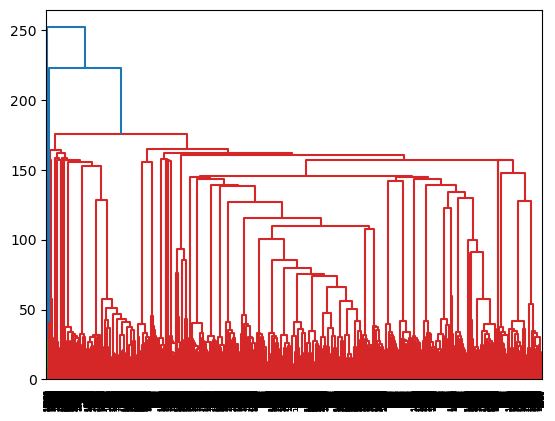

In [172]:
linkage_data = linkage(x, method='ward', metric='euclidean')
dendrogram(linkage_data)
plt.show();

In [173]:
hierarchical_cluster = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
pred_labels = hierarchical_cluster.fit_predict(x) 

In [174]:
acc_Hierarchical = sum(pred_labels== y)/len(y)
recall_0_0 = compute_recall(pred_labels, y , 0, 0)
recall_0_1 = compute_recall(pred_labels, y , 0, 1)
recall_1_1 = compute_recall(pred_labels, y , 1, 1)
recall_1_0 = compute_recall(pred_labels, y , 1, 0)
precision_0_0 = compute_precision(pred_labels, y , 0, 0)
precision_0_1 = compute_precision(pred_labels, y,0,1)
precision_0_1 = compute_precision(pred_labels, y,0,1)
precision_1_1 = compute_precision(pred_labels, y , 1, 1)
precision_1_0 = compute_precision(pred_labels, y , 1, 0)
jaccard_Hierarchical = sklearn.metrics.jaccard_score(y,pred_labels)
print(f'Numerosity of cluster 0 is: {sum(pred_labels==0)}, numerosity of cluster 1 is: {sum(pred_labels==1)}')
print(f'accuracy of Hierarchical clustering on the original dataset is {acc_Hierarchical}')
print(f'for cluster 0 : recall for class 0 = {recall_0_0}, recall for class 1 = {recall_0_1}')
print(f'for cluster 1 : recall for class 0 = {recall_1_0}, recall for class 1 = {recall_1_1}')
print(f'for cluster 0 : precision for class 0 =  {precision_0_0}, precision for class 1 : {precision_0_1}')
print(f'for cluster 1 : precision for class 0 =  {precision_1_0}, precision for class 1 : {precision_1_1}')
print(f'purity of cluster 0 = {max(precision_0_0,precision_0_1)}, purity of cluster 1 = {max(precision_1_1,precision_1_0)}')
print(f'Jaccard index = {jaccard_Hierarchical}')

Numerosity of cluster 0 is: 12277, numerosity of cluster 1 is: 53
accuracy of Hierarchical clustering on the original dataset is 0.843227899432279
for cluster 0 : recall for class 0 = 0.9962579159470352, recall for class 1 = 0.9926624737945493
for cluster 1 : recall for class 0 = 0.003742084052964882, recall for class 1 = 0.007337526205450734
for cluster 0 : precision for class 0 =  0.8457277836605034, precision for class 1 : 0.15427221633949662
for cluster 1 : precision for class 0 =  0.7358490566037735, precision for class 1 : 0.2641509433962264
purity of cluster 0 = 0.8457277836605034, purity of cluster 1 = 0.7358490566037735
Jaccard index = 0.007190549563430919


### Hierarchical clustering on numerical data only and evaluation

In [175]:
hierarchical_cluster_num = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
pred_labels_num = hierarchical_cluster.fit_predict(X_numerical)

In [176]:
acc_Hierarchical_num = sum(pred_labels_num== y)/len(y)
recall_0_0 = compute_recall(pred_labels_num, y , 0, 0)
recall_0_1 = compute_recall(pred_labels_num, y , 0, 1)
recall_1_1 = compute_recall(pred_labels_num, y , 1, 1)
recall_1_0 = compute_recall(pred_labels_num, y , 1, 0)
precision_0_0 = compute_precision(pred_labels_num, y , 0, 0)
precision_0_1 = compute_precision(pred_labels_num, y,0,1)
precision_0_1 = compute_precision(pred_labels_num, y,0,1)
precision_1_1 = compute_precision(pred_labels_num, y , 1, 1)
precision_1_0 = compute_precision(pred_labels_num, y , 1, 0)
jaccard_Hierarchical_num = sklearn.metrics.jaccard_score(y,pred_labels_num)
print(f'Numerosity of cluster 0 is: {sum(pred_labels_num==0)}, numerosity of cluster 1 is: {sum(pred_labels_num==1)}')
print(f'accuracy of Hierarchical clustering on the original dataset is {acc_Hierarchical_num}')
print(f'for cluster 0 : recall for class 0 = {recall_0_0}, recall for class 1 = {recall_0_1}')
print(f'for cluster 1 : recall for class 0 = {recall_1_0}, recall for class 1 = {recall_1_1}')
print(f'for cluster 0 : precision for class 0 =  {precision_0_0}, precision for class 1 : {precision_0_1}')
print(f'for cluster 1 : precision for class 0 =  {precision_1_0}, precision for class 1 : {precision_1_1}')
print(f'purity of cluster 0 = {max(precision_0_0,precision_0_1)}, purity of cluster 1 = {max(precision_1_1,precision_1_0)}')
print(f'Jaccard index = {jaccard_Hierarchical_num}')

Numerosity of cluster 0 is: 10760, numerosity of cluster 1 is: 1570
accuracy of Hierarchical clustering on the original dataset is 0.7871857258718573
for cluster 0 : recall for class 0 = 0.8903281519861831, recall for class 1 = 0.7762054507337526
for cluster 1 : recall for class 0 = 0.10967184801381692, recall for class 1 = 0.22379454926624737
for cluster 0 : precision for class 0 =  0.8623605947955391, precision for class 1 : 0.13763940520446097
for cluster 1 : precision for class 0 =  0.7280254777070063, precision for class 1 : 0.2719745222929936
purity of cluster 0 = 0.8623605947955391, purity of cluster 1 = 0.7280254777070063
Jaccard index = 0.13995411340544084


### Hierarchical clustering on reduced feature space and evaluation

In [177]:
hierarchical_cluster = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
pred_labels_red_H = hierarchical_cluster.fit_predict(new_space)

In [178]:
acc_Hierarchical_red = sum(pred_labels_red_H== y)/len(y)
recall_0_0 = compute_recall(pred_labels_red_H, y , 0, 0)
recall_0_1 = compute_recall(pred_labels_red_H, y , 0, 1)
recall_1_1 = compute_recall(pred_labels_red_H, y , 1, 1)
recall_1_0 = compute_recall(pred_labels_red_H, y , 1, 0)
precision_0_0 = compute_precision(pred_labels_red_H, y , 0, 0)
precision_0_1 = compute_precision(pred_labels_red_H, y,0,1)
precision_0_1 = compute_precision(pred_labels_red_H, y,0,1)
precision_1_1 = compute_precision(pred_labels_red_H, y , 1, 1)
precision_1_0 = compute_precision(pred_labels_red_H, y , 1, 0)
jaccard_Hierarchical_red = sklearn.metrics.jaccard_score(y,pred_labels_red)
print(f'Numerosity of cluster 0 is: {sum(pred_labels_red_H==0)}, numerosity of cluster 1 is: {sum(pred_labels_red_H==1)}')
print(f'accuracy of Hierarchical clustering on the original dataset is {acc_Hierarchical_red}')
print(f'for cluster 0 : recall for class 0 = {recall_0_0}, recall for class 1 = {recall_0_1}')
print(f'for cluster 1 : recall for class 0 = {recall_1_0}, recall for class 1 = {recall_1_1}')
print(f'for cluster 0 : precision for class 0 =  {precision_0_0}, precision for class 1 : {precision_0_1}')
print(f'for cluster 1 : precision for class 0 =  {precision_1_0}, precision for class 1 : {precision_1_1}')
print(f'purity of cluster 0 = {max(precision_0_0,precision_0_1)}, purity of cluster 1 = {max(precision_1_1,precision_1_0)}')
print(f' Jaccard Index = {jaccard_Hierarchical_red}')

Numerosity of cluster 0 is: 12278, numerosity of cluster 1 is: 52
accuracy of Hierarchical clustering on the original dataset is 0.84330900243309
for cluster 0 : recall for class 0 = 0.9963538668201881, recall for class 1 = 0.9926624737945493
for cluster 1 : recall for class 0 = 0.0036461331798119364, recall for class 1 = 0.007337526205450734
for cluster 0 : precision for class 0 =  0.8457403485909757, precision for class 1 : 0.15425965140902428
for cluster 1 : precision for class 0 =  0.7307692307692307, precision for class 1 : 0.2692307692307692
purity of cluster 0 = 0.8457403485909757, purity of cluster 1 = 0.7307692307692307
 Jaccard Index = 0.15387805889672335


### Hierarchical clustering on reduced feature space (numerical variables only) and evaluation

In [179]:
hierarchical_cluster = AgglomerativeClustering(n_clusters=2, metric = 'euclidean', linkage='ward')
pred_labels_red_H_num = hierarchical_cluster.fit_predict(new_space_num)

In [180]:
acc_Hierarchical_PC_num = sum(pred_labels_red_H_num== y)/len(y)
recall_0_0 = compute_recall(pred_labels_red_H_num, y , 0, 0)
recall_0_1 = compute_recall(pred_labels_red_H_num, y , 0, 1)
recall_1_1 = compute_recall(pred_labels_red_H_num, y , 1, 1)
recall_1_0 = compute_recall(pred_labels_red_H_num, y , 1, 0)
precision_0_0 = compute_precision(pred_labels_red_H_num, y , 0, 0)
precision_0_1 = compute_precision(pred_labels_red_H_num, y,0,1)
precision_0_1 = compute_precision(pred_labels_red_H_num, y,0,1)
precision_1_1 = compute_precision(pred_labels_red_H_num, y , 1, 1)
precision_1_0 = compute_precision(pred_labels_red_H_num, y , 1, 0)
jaccard_Hierarchical_PC_num = sklearn.metrics.jaccard_score(y,pred_labels_red_H_num)
print(f'Numerosity of cluster 0 is: {sum(pred_labels_red_H_num==0)}, numerosity of cluster 1 is: {sum(pred_labels_red_H_num==1)}')
print(f'accuracy of Hierarchical clustering on the original dataset is {acc_Hierarchical_PC_num}')
print(f'for cluster 0 : recall for class 0 = {recall_0_0}, recall for class 1 = {recall_0_1}')
print(f'for cluster 1 : recall for class 0 = {recall_1_0}, recall for class 1 = {recall_1_1}')
print(f'for cluster 0 : precision for class 0 =  {precision_0_0}, precision for class 1 : {precision_0_1}')
print(f'for cluster 1 : precision for class 0 =  {precision_1_0}, precision for class 1 : {precision_1_1}')
print(f'purity of cluster 0 = {max(precision_0_0,precision_0_1)}, purity of cluster 1 = {max(precision_1_1,precision_1_0)}')
print(f'Jaccard index = {jaccard_Hierarchical_PC_num}')

Numerosity of cluster 0 is: 11557, numerosity of cluster 1 is: 773
accuracy of Hierarchical clustering on the original dataset is 0.7830494728304948
for cluster 0 : recall for class 0 = 0.9261178276722318, recall for class 1 = 0.9984276729559748
for cluster 1 : recall for class 0 = 0.07388217232776818, recall for class 1 = 0.0015723270440251573
for cluster 0 : precision for class 0 =  0.8351648351648352, precision for class 1 : 0.16483516483516483
for cluster 1 : precision for class 0 =  0.9961190168175937, precision for class 1 : 0.0038809831824062097
purity of cluster 0 = 0.8351648351648352, purity of cluster 1 = 0.9961190168175937
Jaccard index = 0.0011202389843166542


### Evaluation of the clustering procedures based on the "Accuracy" index: 
The closer is the Accuracy index to one, the better! We are minimizing the number of "misclustered" points

<b> The best models are hierarchical models <b> 

In [181]:
acc_list = [acc_KMeans_compl, acc_KMeans_NUM, acc_KMeans_red, acc_KMeans_red_num,
            acc_KMedoids, acc_Hierarchical, acc_Hierarchical_num, acc_Hierarchical_red, acc_Hierarchical_PC_num]
mod_list = ["Kmeans-complete", "Kmeans-numonly", "Kmeans-PCA", "Kmeans-PCA-numonly", "Kmedoids", "Hier-complete", "Hier-numonly", "Hier-PCA", "Hier-PCA-numonly"]
model_accuracy = pd.Series(acc_list, index = mod_list, name = "Accuracy of the different models")

the model with the highest accuracy is Hier-PCA
Its accuracy is 0.84330900243309


<Figure size 1000x600 with 0 Axes>

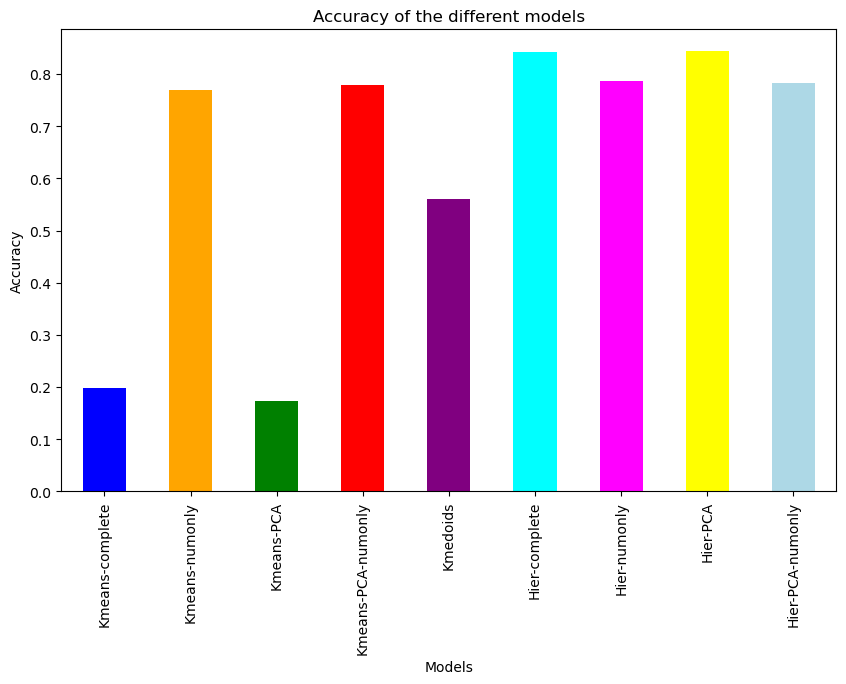

In [182]:
# Create the bar plot
plt.figure(figsize=(10, 6))
colors = ['blue', 'orange', 'green', 'red', 'purple', 'cyan', 'magenta', 'yellow', 'lightblue']
plt.figure(figsize=(10, 6))
model_accuracy.plot(kind='bar', color=colors)
plt.title('Accuracy of the different models')
plt.xlabel('Models')
plt.ylabel('Accuracy')

max_accuracy = model_accuracy.max()
max_model = model_accuracy.idxmax()
print("the model with the highest accuracy is {}\nIts accuracy is {}".format(max_model, max_accuracy))

plt.show();

### Evaluation of the clustering procedures based on the "Jaccard" index: 
The closer is the Jaccard index to one, the better! We are separating revenue = true and revenue = false in the best way. 

<b> The best models is KMedoids <b> 

In [183]:
jacc_list = [jaccard_kmeans_comp, jaccard_kmeans_NUM, jaccard_kmeans_red, jaccard_kmeans_red_num, jaccard_medoids,
            jaccard_Hierarchical, jaccard_Hierarchical_num, jaccard_Hierarchical_red, jaccard_Hierarchical_PC_num]
mod_list = ["Kmeans-complete", "Kmeans-numonly", "Kmeans-PCA", "Kmeans-PCA-numonly", "Kmedoids", "Hier-complete", "Hier-numonly", "Hier-PCA", "Hier-PCA-numonly"]
model_jacc = pd.Series(jacc_list, index = mod_list, name = "Accuracy of the different models")

the model with the highest Jaccard index is Kmedoids
Its Jaccard index is 0.2056664709336465


<Figure size 1000x600 with 0 Axes>

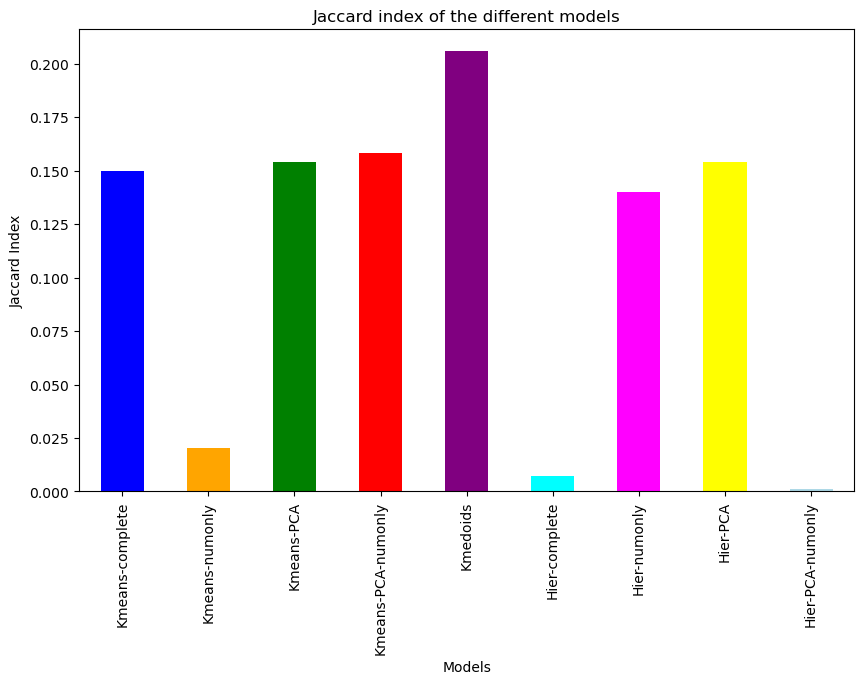

In [184]:
# Create the bar plot
plt.figure(figsize=(10, 6))
colors = ['blue', 'orange', 'green', 'red', 'purple', 'cyan', 'magenta', 'yellow', 'lightblue']
plt.figure(figsize=(10, 6))
model_jacc.plot(kind='bar', color=colors)
plt.title('Jaccard index of the different models')
plt.xlabel('Models')
plt.ylabel('Jaccard Index')

max_jacc = model_jacc.max()
max_model_jacc = model_jacc.idxmax()
print("the model with the highest Jaccard index is {}\nIts Jaccard index is {}".format(max_model_jacc, max_jacc))

plt.show();

## Comparison of the KMeadoids and KNN numerical only (Best classification method)
Based on the Jaccard index, the Kmedoids is the best model for clustering-based classficiation (is the one that divide the revenues best between positive and negative). 
<b> Compare the ROC and compare the AUC with the best model from classification <b>. 
    
    
    


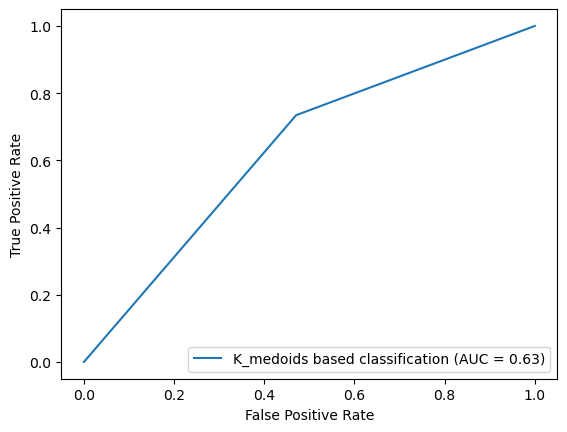

In [185]:
from sklearn import metrics
y_prediction = kmed_labels
y_modified = y.values.astype(int)

fpr, tpr, thresholds = metrics.roc_curve(y_modified, y_prediction)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                   estimator_name='K_medoids based classification')
display.plot()
plt.show()

##  Conclusions: 
The best clustering based algprithm for classification is K-medoids. 
The AUC is 0.63. Is much lower than the best "canonical" alggorithm for classification (KNN, numerical variables only, AUC = 0.92)